In [1]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from nilearn import masking
# from natsort import natsorted
import pickle

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load MNI mask for ROIs betas

In [2]:
maskDir = 'N:\Experimental_Data\yujunchen\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

## Resample MNI mask

In [3]:
temp_nii_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\\betas\Sub1\\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
resampled_mask.shape

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_40600\2278593303.py:4: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_40600\2278593303.py:4: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)


(79, 95, 79)

In [ ]:
# # Save resampled mask
# nib.save(resampled_mask, 'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\mask.nii')


# Load Kastner mask

In [4]:
# Load the dictionary from the file
with open('kastner_dict.pkl', 'rb') as f:
    roi_masks = pickle.load(f)


In [5]:
for (k, v) in roi_masks.items():
    print(k, v.get_fdata().shape, np.count_nonzero(v.get_fdata()))

V1v (79, 95, 79) 856
V1d (79, 95, 79) 748
V2v (79, 95, 79) 727
V2d (79, 95, 79) 645
V3v (79, 95, 79) 527
V3d (79, 95, 79) 517
hV4 (79, 95, 79) 328
V3a (79, 95, 79) 554
V3b (79, 95, 79) 263
LO1 (79, 95, 79) 324
LO2 (79, 95, 79) 125
VO1 (79, 95, 79) 153
VO2 (79, 95, 79) 253
IPS (79, 95, 79) 973
PHC1 (79, 95, 79) 175
PHC2 (79, 95, 79) 165


# Load beta

In [6]:
dataDir = '../GLM_singletrial/betas/'
subs = ['Sub97_old']

# Loop through each subject and assert their existence
for sub in subs:
    sub_path = os.path.join(dataDir, sub)
    if not os.path.isdir(sub_path):
        raise FileNotFoundError(f"Folder for {sub} does not exist at path: {sub_path}")
    else:
        print(f"Folder for {sub} exists at path: {sub_path}")

Folder for Sub97_old exists at path: ../GLM_singletrial/betas/Sub97_old


In [7]:
len(subs)

1

In [8]:
beta_idx = []
for i in range(0 ,10): # runs
    id = [(x + 66*i) for x in range(1,61)]
    beta_idx.append(id)
beta_id = np.array(beta_idx).reshape(1, -1)
beta_id

array([[  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  67,  68,  69,  70,  71,
         72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
        124, 125, 126, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
        182, 183, 184, 185, 186, 187, 188, 189, 190

In [9]:
import os
import re
import nibabel as nib
import numpy as np
from nilearn import masking
from tqdm import tqdm

# -------------------------------
# Configuration
# -------------------------------
dataDir = 'N:/Experimental_Data/yujunchen/projects/AI_IAPS/GLM_singletrial/betas/'
out_dir = r"N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\SPM_TEST"
os.makedirs(out_dir, exist_ok=True)
# -------------------------------
# Processing
# -------------------------------
beta_series = []

for sub in subs:
    sub_dir = os.path.join(dataDir, sub)
    filenames = os.listdir(sub_dir)

    # ✅ Strictly keep only files matching "beta_<number>.nii"
    beta_filenames = [f for f in filenames if re.match(r'^beta_\d+\.nii$', f)]
    file_ids = [int(re.findall(r'\d+', f)[0]) for f in beta_filenames]

    # Select only files whose numeric ID is in beta_id
    selected_filenames = [f for f, fid in zip(beta_filenames, file_ids) if fid in beta_id]

    # Sort numerically (important for sequential betas)
    selected_filenames = sorted(selected_filenames, key=lambda x: int(re.findall(r'\d+', x)[0]))

    print(f'[{sub}] Number of beta files to load: {len(selected_filenames)}')

    sub_beta_series = []

    for fname in tqdm(selected_filenames, desc=f'Loading {sub}'):
        file_path = os.path.join(sub_dir, fname)

        # Load beta image
        nii_data = nib.load(file_path)

        # Apply brain mask
        masked_data = masking.apply_mask(nii_data, resampled_mask)

        # Create full-size 3D volume with NaNs outside the mask
        reshaped_data = np.full(nii_data.shape, np.nan, dtype=np.float32)
        mask_indices = np.where(resampled_mask.get_fdata())
        reshaped_data[mask_indices] = masked_data

        sub_beta_series.append(reshaped_data)

    # Stack into one 4D array (n_betas, x, y, z)
    sub_beta_arrays = np.array(sub_beta_series, dtype=np.float32)
    # beta_series.append(sub_beta_arrays)
    print(f'[{sub}] Loaded shape: {sub_beta_arrays.shape}')

    finite_mask = np.isfinite(sub_beta_arrays)
    if finite_mask.any():
        mean_val = np.nanmean(sub_beta_arrays)
        std_val  = np.nanstd(sub_beta_arrays)
        vmin     = np.nanmin(sub_beta_arrays)
        vmax     = np.nanmax(sub_beta_arrays)
        finite_frac = finite_mask.mean()

        print(f"{sub}: mean={mean_val:.4f}, std={std_val:.4f}, "
              f"min={vmin:.2f}, max={vmax:.2f}, finite={finite_frac:.3%}")
    else:
        print(f"{sub}: No finite data")
    
    beta_path = os.path.join(out_dir, f"{sub}_beta.npy")
    np.save(beta_path, sub_beta_arrays.astype(np.float32))
    print(f"Saved {sub}: beta -> {beta_path}")



[Sub97_old] Number of beta files to load: 600


Loading Sub97_old: 100%|██████████| 600/600 [04:33<00:00,  2.19it/s]


[Sub97_old] Loaded shape: (600, 79, 95, 79)
Sub97_old: mean=0.0115, std=2.3050, min=-82.91, max=58.38, finite=38.526%
Saved Sub97_old: beta -> N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\SPM_TEST\Sub97_old_beta.npy


In [7]:
sub_beta_arrays.shape

(600, 79, 95, 79)

In [ ]:
sub_beta_arrays2 = np.nan_to_num(sub_beta_arrays, nan=0.0)

In [21]:
np.max(sub_beta_arrays2[0])

np.float32(13.29041)

In [27]:
np.count_nonzero(sub_beta_arrays2[3]>5)

np.int64(3524)

# Load stimuli and test sorting

In [9]:
# Read the stimuli information for the 600 trials
stimuli = pd.read_csv("./stimuli_600trials.csv")
stimuli

,run,OriginalOrder,img,emotion_type,AI,group
0,1,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,1,2,5395_2.jpg,neutral,YES,neutralAI
3,1,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,1,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,10,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,10,596,9140.jpg,unpleasant,NO,unpleasant
597,10,597,2446.jpg,neutral,NO,neutral
598,10,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [13]:
import numpy as np
import pandas as pd

assert isinstance(stimuli, pd.DataFrame), "Failed to read stimuli CSV."
assert len(stimuli) == beta_flat.shape[1], "stimuli rows must match beta_flat trials (600)."

# Fix common typos if present
stimuli = stimuli.copy()

group_order = ['pleasant', 'neutral', 'unpleasant',
               'pleasantAI', 'neutralAI', 'unpleasantAI']

# Enforce the category order (helps downstream sorting)
stimuli['group'] = pd.Categorical(stimuli['group'],
                                  categories=group_order,
                                  ordered=True)

# 1) Build the 120 groups of indices (one per unique image, 5 repeats each)
index_groups = []   # list of np.array of length 5 (trial indices)
labels = []         # parallel list of (group, img)
problems = []

for g in group_order:
    gdf = stimuli[stimuli['group'] == g]
    # preserve first-appearance order of each image within the group
    img_order = gdf.drop_duplicates(subset='img', keep='first')['img'].tolist()

    if len(img_order) != 20:
        problems.append(f"[{g}] expected 20 unique imgs, found {len(img_order)}")

    for img in img_order:
        idx = gdf.index[gdf['img'] == img].to_numpy()
        if len(idx) != 5:
            problems.append(f"[{g}, {img}] expected 5 repeats, found {len(idx)}")
        index_groups.append(idx)
        labels.append((g, img))

if problems:
    raise ValueError("Data integrity issues:\n" + "\n".join(problems))

assert len(index_groups) == 120, f"Expected 120 averaged units, got {len(index_groups)}"

# 2) Average across the 5 repeats per (group,img), per subject, per voxel
S, T, V = beta_flat.shape
beta_flat_avg = np.empty((S, 120, V), dtype=beta_flat.dtype)

for j, idx in enumerate(index_groups):
    # beta_flat[:, idx, :] -> (30, 5, 592895); average across repeats
    beta_flat_avg[:, j, :] = np.nanmean(beta_flat[:, idx, :], axis=1)

# 3) Metadata mapping columns -> (group, img, original trial indices)
avg_meta = pd.DataFrame({
    'out_col': np.arange(120, dtype=int),
    'group'  : [g for g, _ in labels],
    'img'    : [img for _, img in labels],
    'trial_indices': [idx for idx in index_groups],
})
avg_meta['group'] = pd.Categorical(avg_meta['group'],
                                   categories=group_order,
                                   ordered=True)
avg_meta = avg_meta.sort_values(['group', 'out_col']).reset_index(drop=True)

print("beta_flat_avg shape:", beta_flat_avg.shape)   # (30, 120, 592895)
print(avg_meta.head())


beta_flat_avg shape: (30, 120, 592895)
   out_col     group       img             trial_indices
0        0  pleasant  2550.jpg   [4, 174, 328, 428, 570]
1        1  pleasant  4505.jpg  [18, 185, 272, 398, 529]
2        2  pleasant  2314.jpg  [19, 186, 273, 435, 567]
3        3  pleasant  4597.jpg  [26, 208, 249, 446, 507]
4        4  pleasant  4180.jpg  [30, 157, 268, 454, 542]


In [14]:
selected_subs = list(range(beta_flat_avg.shape[0]))  # all subjects

In [15]:
avg_meta['group']

0          pleasant
1          pleasant
2          pleasant
3          pleasant
4          pleasant
           ...     
115    unpleasantAI
116    unpleasantAI
117    unpleasantAI
118    unpleasantAI
119    unpleasantAI
Name: group, Length: 120, dtype: category
Categories (6, object): ['pleasant' < 'neutral' < 'unpleasant' < 'pleasantAI' < 'neutralAI' < 'unpleasantAI']

In [19]:
import os
import numpy as np
import pandas as pd
import nibabel as nib

# ------------------------------------------------------------
# REQUIRED INPUTS
#   beta_flat_avg : np.ndarray, (S, 120, V)  # e.g., (30, 120, 592895)
#   avg_meta      : pd.DataFrame with columns ['out_col','group','img',...]
#                   where 'out_col' maps 0..119 to beta_flat_avg columns
#   ref_img       : nib.Nifti1Image (same grid as the flattened V)
#   output_dir    : folder to write NIfTIs
# ------------------------------------------------------------

def save_group_averages(beta_flat_avg, avg_meta, ref_img, output_dir,
                        save_std=False,
                        group_order=('pleasant','neutral','unpleasant',
                                     'pleasantAI','neutralAI','unpleasantAI')):
    os.makedirs(output_dir, exist_ok=True)
    
    S, C, V = beta_flat_avg.shape
    grid_shape = ref_img.shape
    assert np.prod(grid_shape) == V, "ref_img grid size must match flattened V."

    # Use ref_img header/affine (like your example)
    affine = ref_img.affine
    header = ref_img.header.copy()
    header.set_data_dtype(np.float32)

    # Ensure we can map groups -> column indices in beta_flat_avg
    if 'out_col' not in avg_meta.columns:
        raise ValueError("avg_meta must contain 'out_col' column mapping 0..119.")
    if 'group' not in avg_meta.columns:
        raise ValueError("avg_meta must contain 'group' column.")

    for g in group_order:
        # Columns for this group (20 images)
        cols = avg_meta.loc[avg_meta['group'] == g, 'out_col'].to_numpy()
        if len(cols) != 20:
            raise ValueError(f"Group '{g}' should have 20 items; found {len(cols)}.")

        # Slice → (S, 20, V); average over subjects and items → (V,)
        sub = beta_flat_avg[:, cols, :]  # (S, 20, V)
        mean_map = np.nanmean(sub, axis=(0, 1)).astype(np.float32)  # (V,)

        # Reshape to 3D and save
        mean_vol = mean_map.reshape(grid_shape)
        mean_nifti = nib.Nifti1Image(mean_vol, affine, header)
        mean_filename = os.path.join(output_dir, f"{g}_mean.nii.gz")
        nib.save(mean_nifti, mean_filename)
        print(f"Saved: {mean_filename}")

        if save_std:
            std_map = np.nanstd(sub, axis=(0, 1)).astype(np.float32)  # (V,)
            std_vol = std_map.reshape(grid_shape)
            std_nifti = nib.Nifti1Image(std_vol, affine, header)
            std_filename = os.path.join(output_dir, f"{g}_std.nii.gz")
            nib.save(std_nifti, std_filename)
            print(f"Saved: {std_filename}")

# ------------------ EXAMPLE CALL ------------------
save_group_averages(beta_flat_avg, avg_meta, resampled_mask, "./group_maps", save_std=False)
# If your reference is named ref_img instead of resampled_mask:
# save_group_averages(beta_flat_avg, avg_meta, ref_img, "./group_maps", save_std=False)


Saved: ./group_maps\pleasant_mean.nii.gz
Saved: ./group_maps\neutral_mean.nii.gz
Saved: ./group_maps\unpleasant_mean.nii.gz
Saved: ./group_maps\pleasantAI_mean.nii.gz
Saved: ./group_maps\neutralAI_mean.nii.gz
Saved: ./group_maps\unpleasantAI_mean.nii.gz


In [21]:
beta_flat_avg.shape

(30, 120, 592895)

In [16]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from nilearn import plotting
from nilearn.image import resample_to_img, new_img_like

def process_beta_slices_complete(beta_flat_avg, 
                                 mask_img=None,
                                 output_dir="./averaged_slices", 
                                 z_slice=40,  # Middle slice for 79-dim volume
                                 condition_labels=None,
                                 apply_mask=True,
                                 create_montage=True,
                                 create_conditions_comparison=True):
    """
    Complete pipeline for processing beta maps and extracting brain slices
    
    Parameters:
    -----------
    beta_flat_avg : numpy array
        Shape: (n_subjects, n_trials, n_voxels) where n_voxels = 592895 (79x95x79)
    mask_img : nibabel image, optional
        Brain mask to apply (will be resampled if needed)
    output_dir : str
        Directory to save outputs
    z_slice : int
        Which z-slice to extract (default=40 for middle of 79-dim volume)
    condition_labels : list, optional
        List of condition names for each trial
    apply_mask : bool
        Whether to apply brain mask to remove non-brain regions
    create_montage : bool
        Whether to create a montage of all trials
    create_conditions_comparison : bool
        Whether to create comparison plots by condition
    
    Returns:
    --------
    group_avg : numpy array
        Averaged data across subjects
    all_slices : list
        List of extracted slices
    """
    
    print("="*60)
    print("BRAIN SLICE EXTRACTION PIPELINE")
    print("="*60)
    
    # Check input dimensions
    print(f"\nInput shape: {beta_flat_avg.shape}")
    n_subjects, n_trials, n_voxels = beta_flat_avg.shape
    
    # Verify dimensions
    if n_voxels == 592895:
        x_dim, y_dim, z_dim = 79, 95, 79
        print(f"✓ Data dimensions: {x_dim} × {y_dim} × {z_dim}")
    else:
        raise ValueError(f"Expected 592895 voxels (79×95×79), got {n_voxels}")
    
    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    slices_dir = os.path.join(output_dir, 'individual_slices')
    os.makedirs(slices_dir, exist_ok=True)
    
    # Step 1: Average across subjects
    print(f"\n1. Averaging across {n_subjects} subjects...")
    group_avg = np.mean(beta_flat_avg, axis=0)  # Shape: (120, 592895)
    print(f"   Result shape: {group_avg.shape}")
    
    # Step 2: Prepare mask if needed
    mask_3d = None
    if apply_mask and mask_img is not None:
        print("\n2. Preparing brain mask...")
        
        # Create a dummy image with correct dimensions for resampling
        dummy_data = np.ones((x_dim, y_dim, z_dim))
        dummy_affine = np.eye(4)
        dummy_affine[0, 0] = 3  # Assuming 3mm voxels
        dummy_affine[1, 1] = 3
        dummy_affine[2, 2] = 3
        dummy_img = nib.Nifti1Image(dummy_data, dummy_affine)
        
        # Resample mask to match data dimensions
        mask_resampled = resample_to_img(mask_img, dummy_img, interpolation='nearest')
        mask_3d = mask_resampled.get_fdata() > 0.5
        print(f"   Mask shape: {mask_3d.shape}")
        print(f"   Brain voxels: {np.sum(mask_3d):,}")
    else:
        print("\n2. No mask applied - using full volume")
    
    # Step 3: Process each trial
    print(f"\n3. Processing {n_trials} trials (extracting z={z_slice} slice)...")
    
    all_slices = []
    all_slices_masked = []
    
    for trial_idx in tqdm(range(n_trials), desc="   Processing"):
        # Reshape to 3D
        brain_3d = group_avg[trial_idx, :].reshape(x_dim, y_dim, z_dim)
        
        # Apply mask if requested
        if mask_3d is not None:
            brain_3d_masked = brain_3d * mask_3d
        else:
            brain_3d_masked = brain_3d
        
        # Extract slice
        slice_data = brain_3d_masked[:, :, z_slice]
        all_slices.append(slice_data)
        
        # Save individual slice
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        im = ax.imshow(slice_data.T, cmap='coolwarm', origin='lower', 
                      interpolation='bilinear')
        
        # Add title
        if condition_labels and trial_idx < len(condition_labels):
            title = f'{condition_labels[trial_idx]} - Trial {trial_idx+1}'
            filename = f'{condition_labels[trial_idx]}_trial{trial_idx+1:03d}.png'
        else:
            title = f'Trial {trial_idx+1}'
            filename = f'trial_{trial_idx+1:03d}.png'
        
        ax.set_title(f'{title} (z={z_slice})')
        ax.set_xlabel('X axis')
        ax.set_ylabel('Y axis')
        plt.colorbar(im, ax=ax, label='Beta value')
        
        filepath = os.path.join(slices_dir, filename)
        plt.savefig(filepath, dpi=100, bbox_inches='tight')
        plt.close()
    
    print(f"   ✓ Saved {n_trials} individual slices to {slices_dir}")
    
    # Step 4: Create montage
    if create_montage:
        print("\n4. Creating summary montage...")
        create_trial_montage(all_slices, n_trials, output_dir, z_slice, condition_labels)
    
    # Step 5: Create condition comparisons if labels provided
    if create_conditions_comparison and condition_labels:
        print("\n5. Creating condition comparison plots...")
        create_condition_comparison(all_slices, condition_labels, output_dir, z_slice)
    
    # Step 6: Save averaged maps per condition
    if condition_labels:
        print("\n6. Saving condition-averaged brain maps...")
        save_condition_averages(group_avg, condition_labels, x_dim, y_dim, z_dim, 
                               mask_3d, output_dir, z_slice)
    
    print("\n" + "="*60)
    print("PROCESSING COMPLETE!")
    print(f"All outputs saved to: {output_dir}")
    print("="*60)
    
    return group_avg, all_slices


def create_trial_montage(all_slices, n_trials, output_dir, z_slice, condition_labels=None):
    """Create a montage of all trials"""
    
    n_cols = 12
    n_rows = int(np.ceil(n_trials / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 2*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Find common color scale
    all_data = np.concatenate([s.flatten() for s in all_slices])
    vmin = np.percentile(all_data[all_data != 0], 1) if np.any(all_data != 0) else 0
    vmax = np.percentile(all_data[all_data != 0], 99) if np.any(all_data != 0) else 1
    
    for idx in range(n_trials):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        im = ax.imshow(all_slices[idx].T, cmap='coolwarm', origin='lower',
                      vmin=vmin, vmax=vmax, interpolation='bilinear')
        
        if condition_labels and idx < len(condition_labels):
            # Shorten condition names for space
            cond_short = condition_labels[idx].replace('pleasant', 'P').replace('neutral', 'N').replace('unpleasant', 'U')
            ax.set_title(f'{cond_short} T{idx+1}', fontsize=7)
        else:
            ax.set_title(f'T{idx+1}', fontsize=8)
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(n_trials, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')
    
    # Add colorbar
    fig.subplots_adjust(right=0.95)
    cbar_ax = fig.add_axes([0.96, 0.15, 0.02, 0.7])
    plt.colorbar(im, cax=cbar_ax, label='Beta value')
    
    plt.suptitle(f'All {n_trials} Trials - Brain Slice z={z_slice}', fontsize=14, y=1.02)
    
    montage_file = os.path.join(output_dir, f'montage_all_trials_z{z_slice}.png')
    plt.savefig(montage_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"   ✓ Saved montage: {montage_file}")


def create_condition_comparison(all_slices, condition_labels, output_dir, z_slice):
    """Create comparison plots for different conditions"""
    
    # Get unique conditions
    unique_conditions = []
    seen = set()
    for cond in condition_labels:
        if cond not in seen:
            unique_conditions.append(cond)
            seen.add(cond)
    
    n_conditions = len(unique_conditions)
    
    # Calculate average for each condition
    condition_averages = {}
    for cond in unique_conditions:
        indices = [i for i, label in enumerate(condition_labels) if label == cond]
        cond_slices = [all_slices[i] for i in indices]
        condition_averages[cond] = np.mean(cond_slices, axis=0)
    
    # Create comparison plot
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Find common color scale
    all_avg_data = np.concatenate([v.flatten() for v in condition_averages.values()])
    vmin = np.percentile(all_avg_data[all_avg_data != 0], 1) if np.any(all_avg_data != 0) else 0
    vmax = np.percentile(all_avg_data[all_avg_data != 0], 99) if np.any(all_avg_data != 0) else 1
    
    for idx, cond in enumerate(unique_conditions):
        if idx < len(axes):
            ax = axes[idx]
            im = ax.imshow(condition_averages[cond].T, cmap='coolwarm', 
                          origin='lower', vmin=vmin, vmax=vmax, interpolation='bilinear')
            ax.set_title(f'{cond} (n={condition_labels.count(cond)})', fontsize=12)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Hide unused subplots
    for idx in range(n_conditions, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Average Brain Activation by Condition - Slice z={z_slice}', fontsize=14)
    plt.tight_layout()
    
    comparison_file = os.path.join(output_dir, f'condition_comparison_z{z_slice}.png')
    plt.savefig(comparison_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"   ✓ Saved condition comparison: {comparison_file}")


def save_condition_averages(group_avg, condition_labels, x_dim, y_dim, z_dim, 
                           mask_3d, output_dir, z_slice):
    """Save averaged brain maps for each condition"""
    
    unique_conditions = list(set(condition_labels))
    avg_dir = os.path.join(output_dir, 'condition_averages')
    os.makedirs(avg_dir, exist_ok=True)
    
    for cond in unique_conditions:
        # Get trials for this condition
        indices = [i for i, label in enumerate(condition_labels) if label == cond]
        
        # Average across trials
        cond_avg = np.mean(group_avg[indices, :], axis=0)
        
        # Reshape to 3D
        brain_3d = cond_avg.reshape(x_dim, y_dim, z_dim)
        
        # Apply mask if available
        if mask_3d is not None:
            brain_3d = brain_3d * mask_3d
        
        # Extract slice
        slice_data = brain_3d[:, :, z_slice]
        
        # Save slice
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        im = ax.imshow(slice_data.T, cmap='coolwarm', origin='lower', interpolation='bilinear')
        ax.set_title(f'{cond} Average (n={len(indices)} trials)', fontsize=14)
        ax.set_xlabel('X axis')
        ax.set_ylabel('Y axis')
        plt.colorbar(im, ax=ax, label='Beta value')
        
        filepath = os.path.join(avg_dir, f'{cond}_average_z{z_slice}.png')
        plt.savefig(filepath, dpi=100, bbox_inches='tight')
        plt.close()
    
    print(f"   ✓ Saved {len(unique_conditions)} condition averages to {avg_dir}")


# ============= MAIN EXECUTION =============
if __name__ == "__main__":
    print("\n" + "="*60)
    print("READY TO PROCESS YOUR DATA")
    print("="*60)
    print("\nExample usage:")
    print("-"*40)

# Load your data and mask
mask_img = resampled_mask  # Optional

# Create condition labels (20 trials × 6 conditions = 120 total)
conditions = ['pleasant', 'pleasantAI', 'neutral', 'neutralAI', 'unpleasant', 'unpleasantAI']
condition_labels = []
for cond in conditions:
    condition_labels.extend([cond] * 20)

# Run the complete pipeline
group_avg, slices = process_beta_slices_complete(
    beta_flat_avg,
    mask_img=mask_img,  # Optional - set to None to skip masking
    output_dir="./brain_slices_output",
    z_slice=2,  # Middle slice for 79-dim volume
    condition_labels=condition_labels,
    apply_mask=True,
    create_montage=True,
    create_conditions_comparison=True
)




READY TO PROCESS YOUR DATA

Example usage:
----------------------------------------
BRAIN SLICE EXTRACTION PIPELINE

Input shape: (30, 120, 592895)
✓ Data dimensions: 79 × 95 × 79

1. Averaging across 30 subjects...


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_13720\2663186833.py:86: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled = resample_to_img(mask_img, dummy_img, interpolation='nearest')
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_13720\2663186833.py:86: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled = resample_to_img(mask_img, dummy_img, interpolation='nearest')


   Result shape: (120, 592895)

2. Preparing brain mask...
   Mask shape: (79, 95, 79)
   Brain voxels: 7,991

3. Processing 120 trials (extracting z=2 slice)...


   Processing: 100%|██████████| 120/120 [00:15<00:00,  7.90it/s]


   ✓ Saved 120 individual slices to ./brain_slices_output\individual_slices

4. Creating summary montage...
   ✓ Saved montage: ./brain_slices_output\montage_all_trials_z2.png

5. Creating condition comparison plots...
   ✓ Saved condition comparison: ./brain_slices_output\condition_comparison_z2.png

6. Saving condition-averaged brain maps...
   ✓ Saved 6 condition averages to ./brain_slices_output\condition_averages

PROCESSING COMPLETE!
All outputs saved to: ./brain_slices_output


In [20]:
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

def create_nilearn_style_slices(group_avg, reference_img, 
                               output_dir="./nilearn_slices",
                               condition_labels=None,
                               threshold=0.3,
                               cmap='cold_hot',
                               display_mode='ortho',
                               cut_coords=None):
    """
    Create nilearn-style orthogonal brain slice visualizations for all trials
    
    Parameters:
    -----------
    group_avg : numpy array
        Shape: (n_trials, n_voxels) where n_voxels = 592895
    reference_img : nibabel image
        Reference image for creating NIfTI (e.g., your resampled_mask)
    output_dir : str
        Directory to save outputs
    condition_labels : list, optional
        List of condition names for each trial
    threshold : float
        Threshold for visualization (default=0.3)
    cmap : str
        Colormap to use (default='cold_hot')
    display_mode : str
        'ortho' for 3 orthogonal cuts, 'x', 'y', 'z' for single planes,
        or 'xz', 'yz', 'yx' for two planes
    cut_coords : tuple or None
        Coordinates for the cuts (if None, uses center)
    """
    
    print("="*60)
    print("CREATING NILEARN-STYLE BRAIN VISUALIZATIONS")
    print("="*60)
    
    n_trials = group_avg.shape[0]
    print(f"\nProcessing {n_trials} trials...")
    
    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    individual_dir = os.path.join(output_dir, 'individual_trials')
    os.makedirs(individual_dir, exist_ok=True)
    
    # Process each trial
    for trial_idx in tqdm(range(n_trials), desc="Creating visualizations"):
        # Get trial data
        trial_data = group_avg[trial_idx, :]
        
        # Reshape to 3D (79, 95, 79)
        brain_3d = trial_data.reshape(79, 95, 79)
        
        # Create NIfTI image using reference
        trial_nii = new_img_like(reference_img, brain_3d)
        
        # Create figure
        fig = plt.figure(figsize=(12, 4))
        
        # Plot using nilearn
        display = plotting.plot_stat_map(
            trial_nii,
            threshold=threshold,
            display_mode=display_mode,
            cut_coords=cut_coords,
            figure=fig,
            cmap=cmap,
            black_bg=True,
            annotate=True,
            draw_cross=True,
            colorbar=True
        )
        
        # Add title
        if condition_labels and trial_idx < len(condition_labels):
            title = f'{trial_idx+1} - {condition_labels[trial_idx]}'
            filename = f'{trial_idx+1:03d}_{condition_labels[trial_idx]}.png'
        else:
            title = f'{trial_idx+1}'
            filename = f'{trial_idx+1:03d}.png'
        
        display.title(title, size=12)
        
        # Save figure
        filepath = os.path.join(individual_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='black')
        plt.close(fig)
    
    print(f"\n✓ Saved {n_trials} visualizations to {individual_dir}")
    
    # Create condition averages if labels provided
    if condition_labels:
        create_condition_averages_nilearn(group_avg, reference_img, condition_labels, 
                                         output_dir, threshold, cmap, display_mode, cut_coords)
    
    print("\n" + "="*60)
    print("COMPLETE!")
    print(f"All outputs saved to: {output_dir}")
    print("="*60)


def create_condition_averages_nilearn(group_avg, reference_img, condition_labels,
                                     output_dir, threshold, cmap, display_mode, cut_coords):
    """Create averaged brain maps for each condition in nilearn style"""
    
    print("\nCreating condition averages...")
    
    avg_dir = os.path.join(output_dir, 'condition_averages')
    os.makedirs(avg_dir, exist_ok=True)
    
    unique_conditions = list(set(condition_labels))
    
    for cond in tqdm(unique_conditions, desc="Processing conditions"):
        # Get trials for this condition
        indices = [i for i, label in enumerate(condition_labels) if label == cond]
        
        # Average across trials
        cond_avg = np.mean(group_avg[indices, :], axis=0)
        
        # Reshape to 3D
        brain_3d = cond_avg.reshape(79, 95, 79)
        
        # Create NIfTI
        cond_nii = new_img_like(reference_img, brain_3d)
        
        # Create figure
        fig = plt.figure(figsize=(12, 4))
        
        # Plot
        display = plotting.plot_stat_map(
            cond_nii,
            threshold=threshold,
            display_mode=display_mode,
            cut_coords=cut_coords,
            figure=fig,
            cmap=cmap,
            black_bg=True,
            annotate=True,
            draw_cross=True,
            colorbar=True
        )
        
        display.title(f'{cond} Average (n={len(indices)} trials)', size=12)
        
        # Save
        filepath = os.path.join(avg_dir, f'{cond}_average.png')
        fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='black')
        plt.close(fig)
    
    print(f"   ✓ Saved {len(unique_conditions)} condition averages")


def create_trial_montage_nilearn(group_avg, reference_img, output_dir, 
                                condition_labels=None, n_examples=12,
                                threshold=0.3, cmap='cold_hot'):
    """Create a montage showing example trials in nilearn style"""
    
    print("\nCreating example montage...")
    
    # Select evenly spaced trials
    n_trials = group_avg.shape[0]
    trial_indices = np.linspace(0, n_trials-1, n_examples, dtype=int)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12), facecolor='black')
    axes = axes.flatten()
    
    for idx, trial_idx in enumerate(trial_indices):
        # Get trial data
        trial_data = group_avg[trial_idx, :]
        brain_3d = trial_data.reshape(79, 95, 79)
        trial_nii = new_img_like(reference_img, brain_3d)
        
        # Plot in subplot
        ax = axes[idx]
        display = plotting.plot_stat_map(
            trial_nii,
            threshold=threshold,
            display_mode='z',  # Single axial slice for montage
            cut_coords=[0],    # z=0 slice
            axes=ax,
            cmap=cmap,
            black_bg=True,
            annotate=False,
            colorbar=False
        )
        
        # Add title
        if condition_labels and trial_idx < len(condition_labels):
            title = f'{condition_labels[trial_idx][:10]} T{trial_idx+1}'
        else:
            title = f'Trial {trial_idx+1}'
        ax.set_title(title, color='white', fontsize=10)
    
    plt.suptitle('Example Trials - Axial View (z=0)', color='white', fontsize=14)
    
    montage_file = os.path.join(output_dir, 'example_montage.png')
    fig.savefig(montage_file, dpi=150, bbox_inches='tight', facecolor='black')
    plt.close(fig)
    
    print(f"   ✓ Saved montage: {montage_file}")


def create_interactive_html_views(group_avg, reference_img, output_dir,
                                 condition_labels=None, threshold=0.3, cmap='cold_hot'):
    """Create interactive HTML views for selected trials"""
    
    print("\nCreating interactive HTML views...")
    
    html_dir = os.path.join(output_dir, 'interactive_html')
    os.makedirs(html_dir, exist_ok=True)
    
    # Create for first trial of each condition if labels provided
    if condition_labels:
        unique_conditions = list(set(condition_labels))
        for cond in unique_conditions:
            # Get first trial of this condition
            idx = condition_labels.index(cond)
            trial_data = group_avg[idx, :]
            brain_3d = trial_data.reshape(79, 95, 79)
            trial_nii = new_img_like(reference_img, brain_3d)
            
            # Create interactive view
            view = plotting.view_img(trial_nii, cmap=cmap, threshold=threshold,
                                    title=f'{cond} - Trial {idx+1}')
            
            # Save HTML
            html_file = os.path.join(html_dir, f'{cond}_interactive.html')
            view.save_as_html(html_file)
        
        print(f"   ✓ Saved {len(unique_conditions)} interactive HTML files")
    else:
        # Just create for first trial
        trial_data = group_avg[0, :]
        brain_3d = trial_data.reshape(79, 95, 79)
        trial_nii = new_img_like(reference_img, brain_3d)
        
        view = plotting.view_img(trial_nii, cmap=cmap, threshold=threshold,
                                title='Trial 1')
        html_file = os.path.join(html_dir, 'trial_001_interactive.html')
        view.save_as_html(html_file)
        print(f"   ✓ Saved example interactive HTML")


# ============= MAIN EXECUTION =============
if __name__ == "__main__":
    
    # Assuming you have group_avg and resampled_mask loaded
    # group_avg shape: (120, 592895)
    # resampled_mask: your reference NIfTI image
    
    # Create condition labels (20 trials × 6 conditions = 120 total)
    conditions = ['pleasant', 'neutral', 'unpleasant',
               'pleasantAI', 'neutralAI', 'unpleasantAI']
    condition_labels = []
    for cond in conditions:
        condition_labels.extend([cond] * 20)
    
    # Create nilearn-style visualizations for all trials
    create_nilearn_style_slices(
        group_avg,
        resampled_mask,  # Your reference image
        output_dir="./nilearn_brain_slices",
        condition_labels=condition_labels,
        threshold=0.3,
        cmap='cold_hot',
        display_mode='ortho',  # Shows x, y, z cuts like your example
        cut_coords=[22, -2, 0]  # Will use center coordinates
    )
    
    # Also create a montage of example trials
    # create_trial_montage_nilearn(
    #     group_avg,
    #     resampled_mask,
    #     output_dir="./nilearn_brain_slices",
    #     condition_labels=condition_labels,
    #     n_examples=12,
    #     threshold=0.3,
    #     cmap='cold_hot'
    # )
    
    # Optionally create interactive HTML views
    # create_interactive_html_views(
    #     group_avg,
    #     resampled_mask,
    #     output_dir="./nilearn_brain_slices",
    #     condition_labels=condition_labels,
    #     threshold=0.3,
    #     cmap='cold_hot'
    # )
    
    print("\nAll visualizations created successfully!")

CREATING NILEARN-STYLE BRAIN VISUALIZATIONS

Processing 120 trials...


Creating visualizations: 100%|██████████| 120/120 [03:42<00:00,  1.85s/it]



✓ Saved 120 visualizations to ./nilearn_brain_slices\individual_trials

Creating condition averages...


Processing conditions: 100%|██████████| 6/6 [00:17<00:00,  2.87s/it]

   ✓ Saved 6 condition averages

COMPLETE!
All outputs saved to: ./nilearn_brain_slices

All visualizations created successfully!



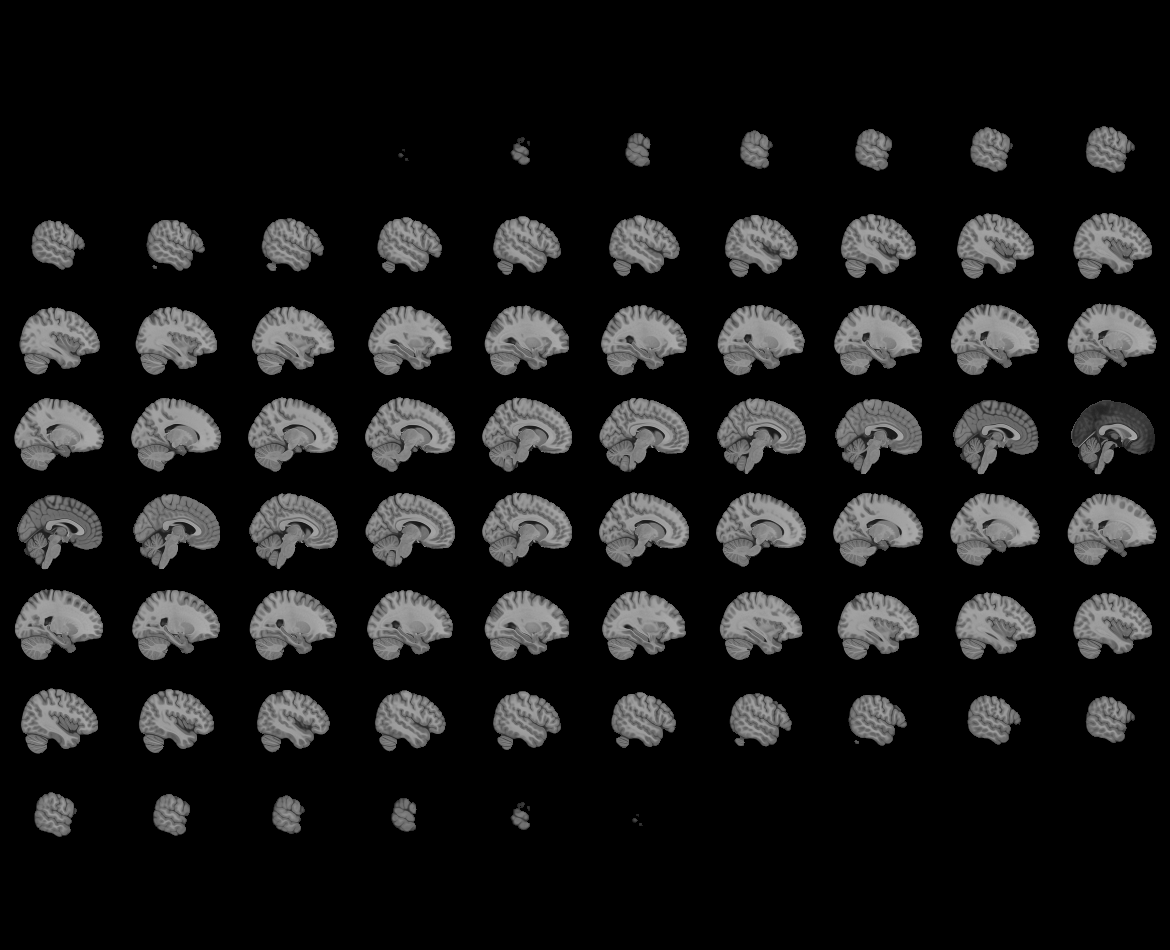
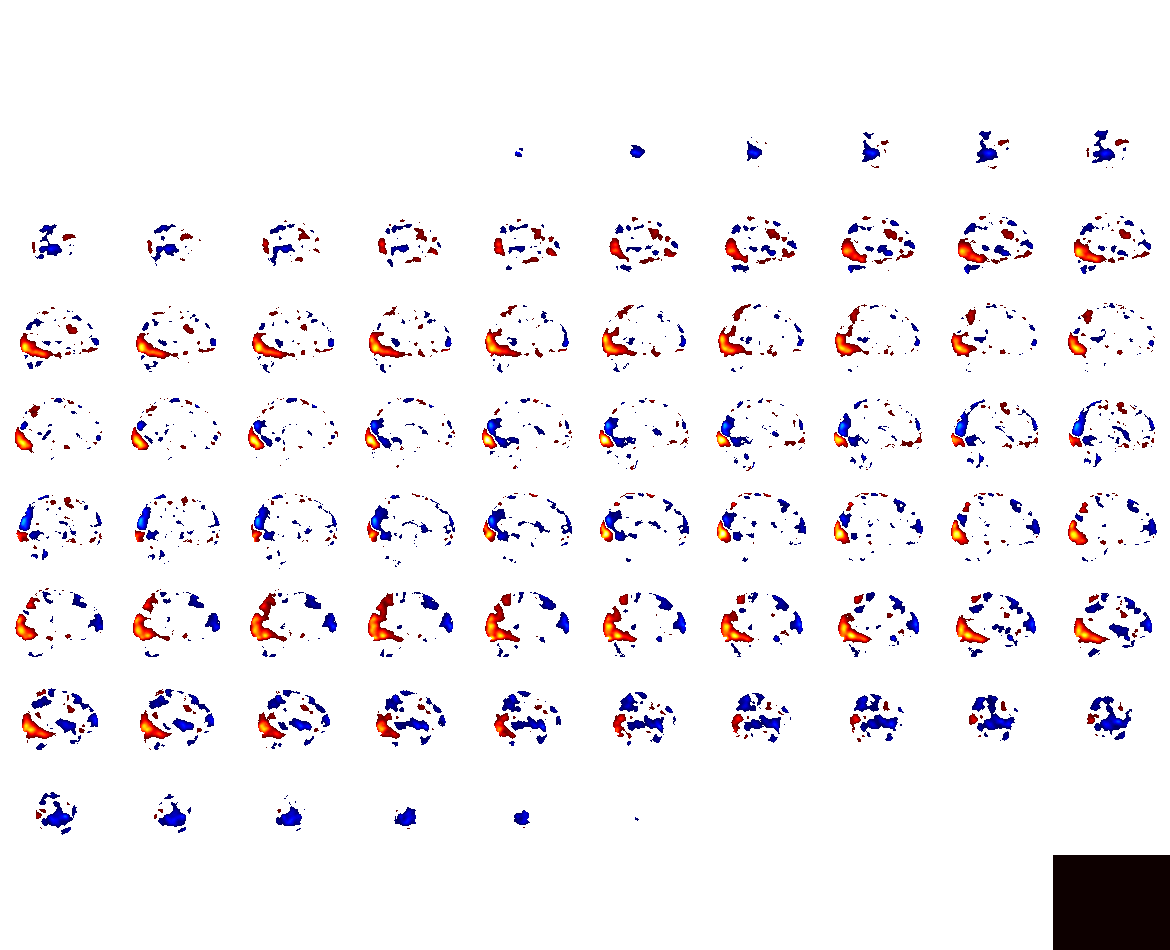

In [38]:
test_mask_data = np.empty((79, 95, 79))
test_mask_data[:] = np.nan
test_mask_data_flat = test_mask_data.flatten()
test_mask_data_flat = group_avg[0]
# With no F order
from nilearn.image import new_img_like
test_mask_nii = new_img_like(resampled_mask, test_mask_data_flat.reshape(79, 95, 79))
view = plotting.view_img(test_mask_nii, cmap='cold_hot', threshold=0.3)
view


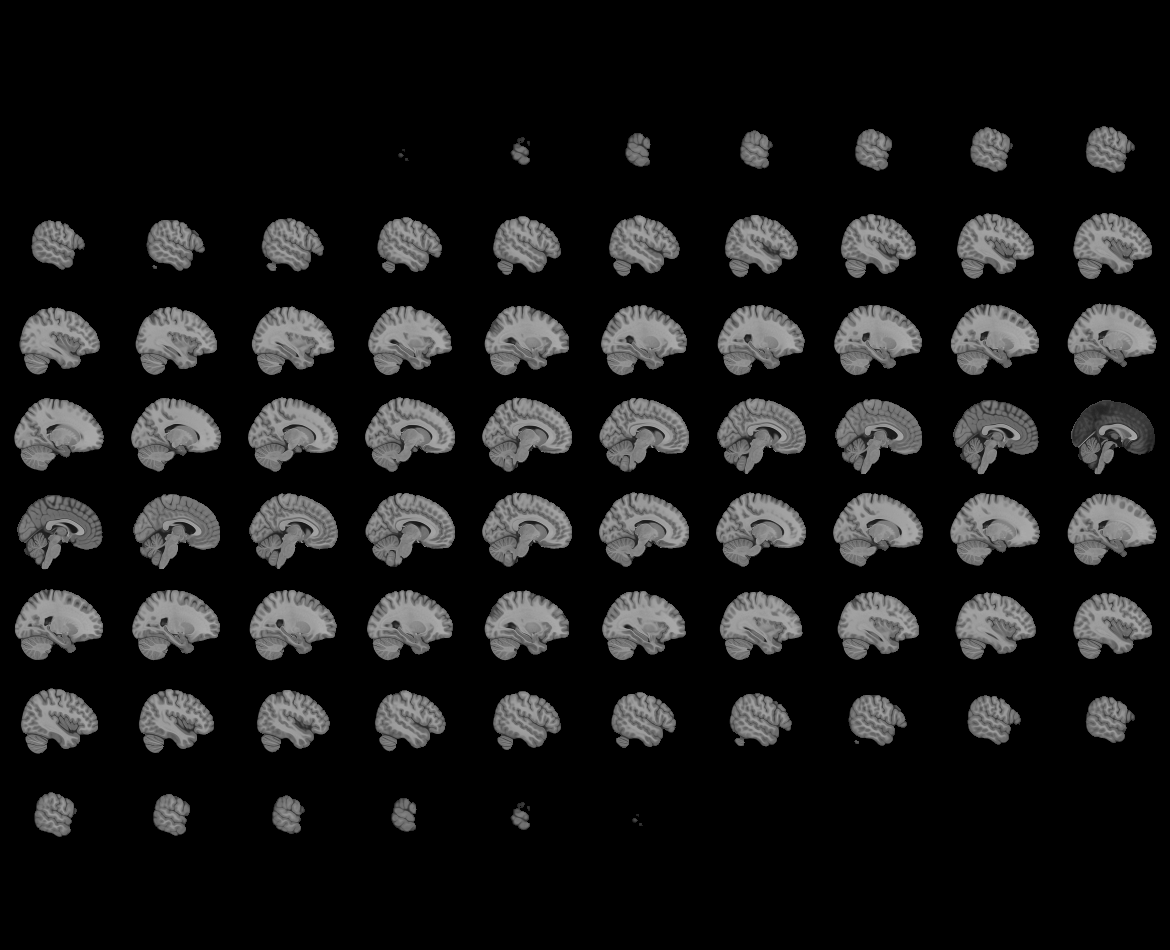
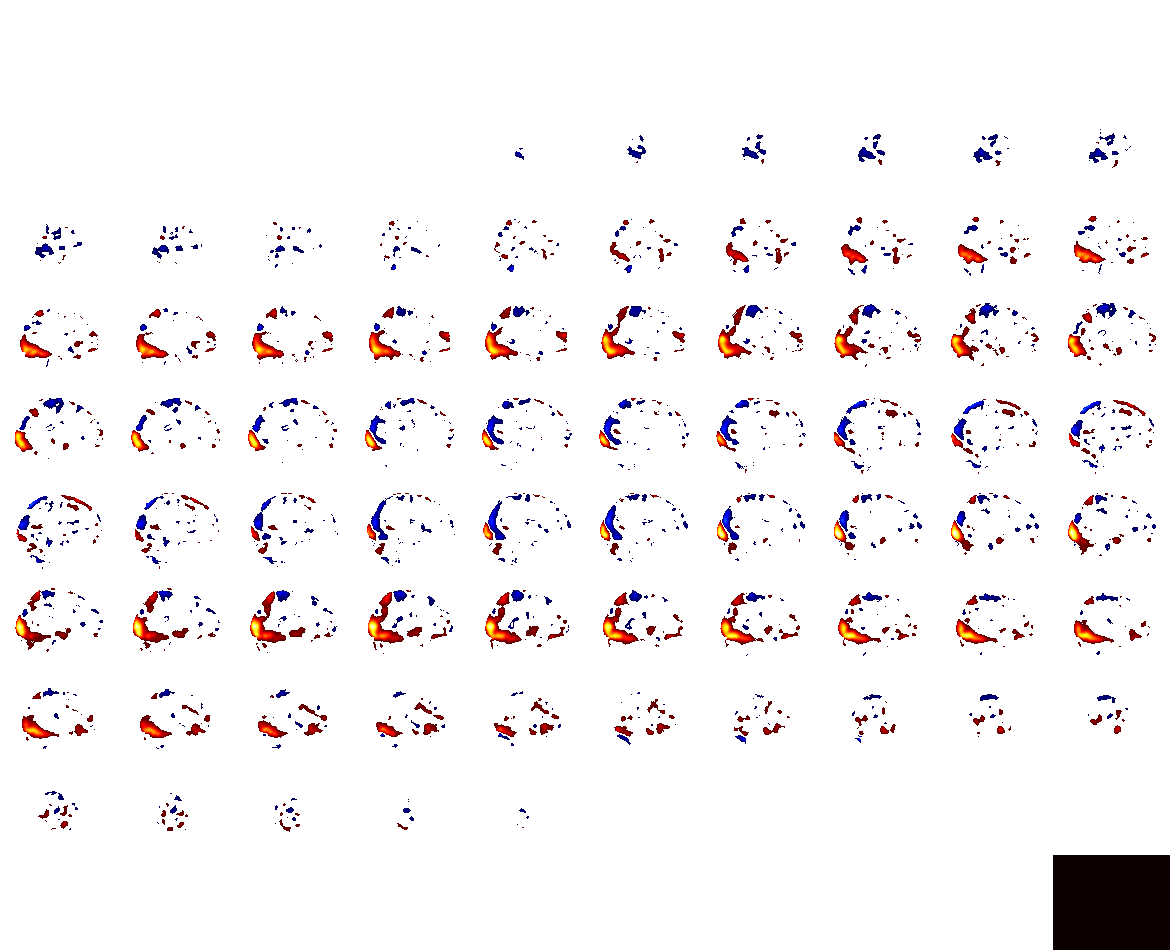

In [37]:
test_mask_data = np.empty((79, 95, 79))
test_mask_data[:] = np.nan
test_mask_data_flat = test_mask_data.flatten()
test_mask_data_flat = group_avg[20]
# With no F order
from nilearn.image import new_img_like
test_mask_nii = new_img_like(resampled_mask, test_mask_data_flat.reshape(79, 95, 79))
view = plotting.view_img(test_mask_nii, cmap='cold_hot', threshold=0.3)
view


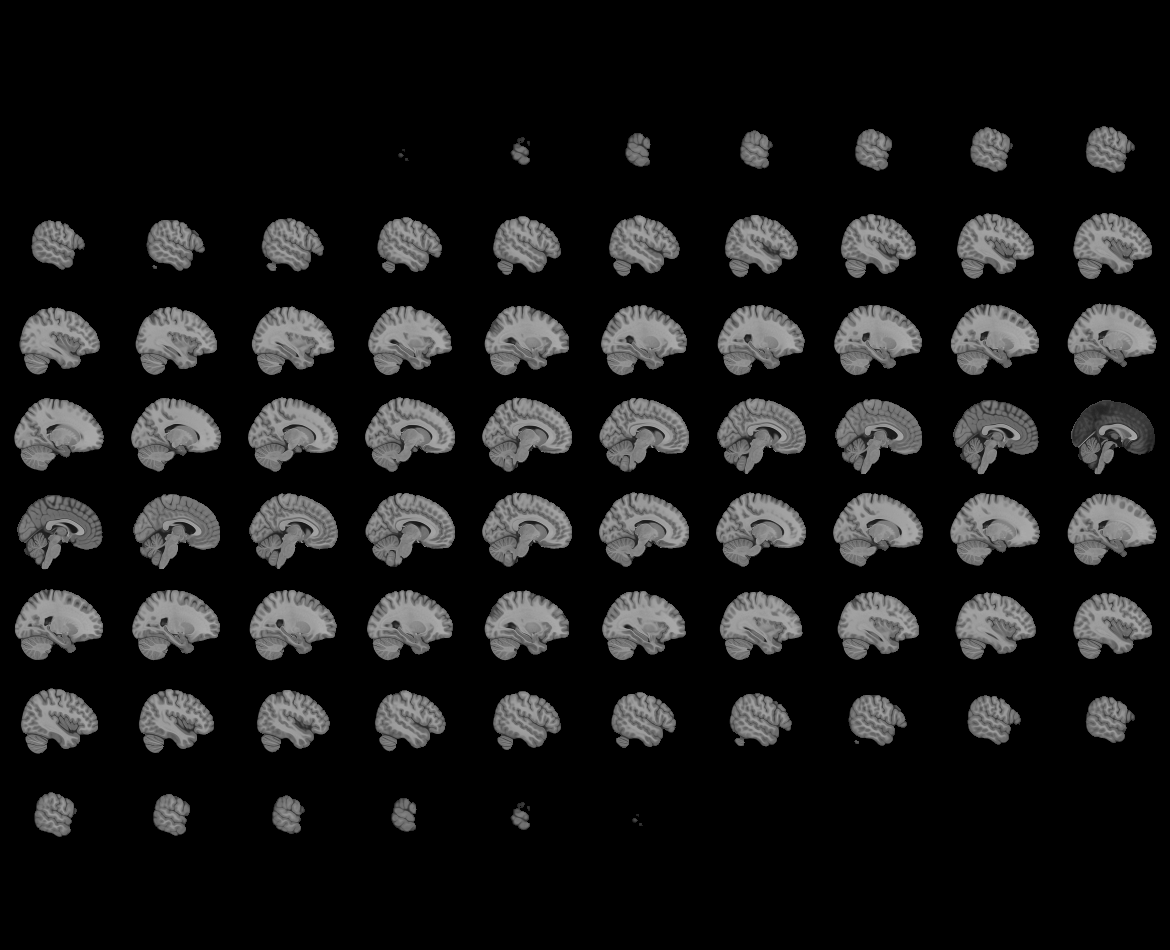
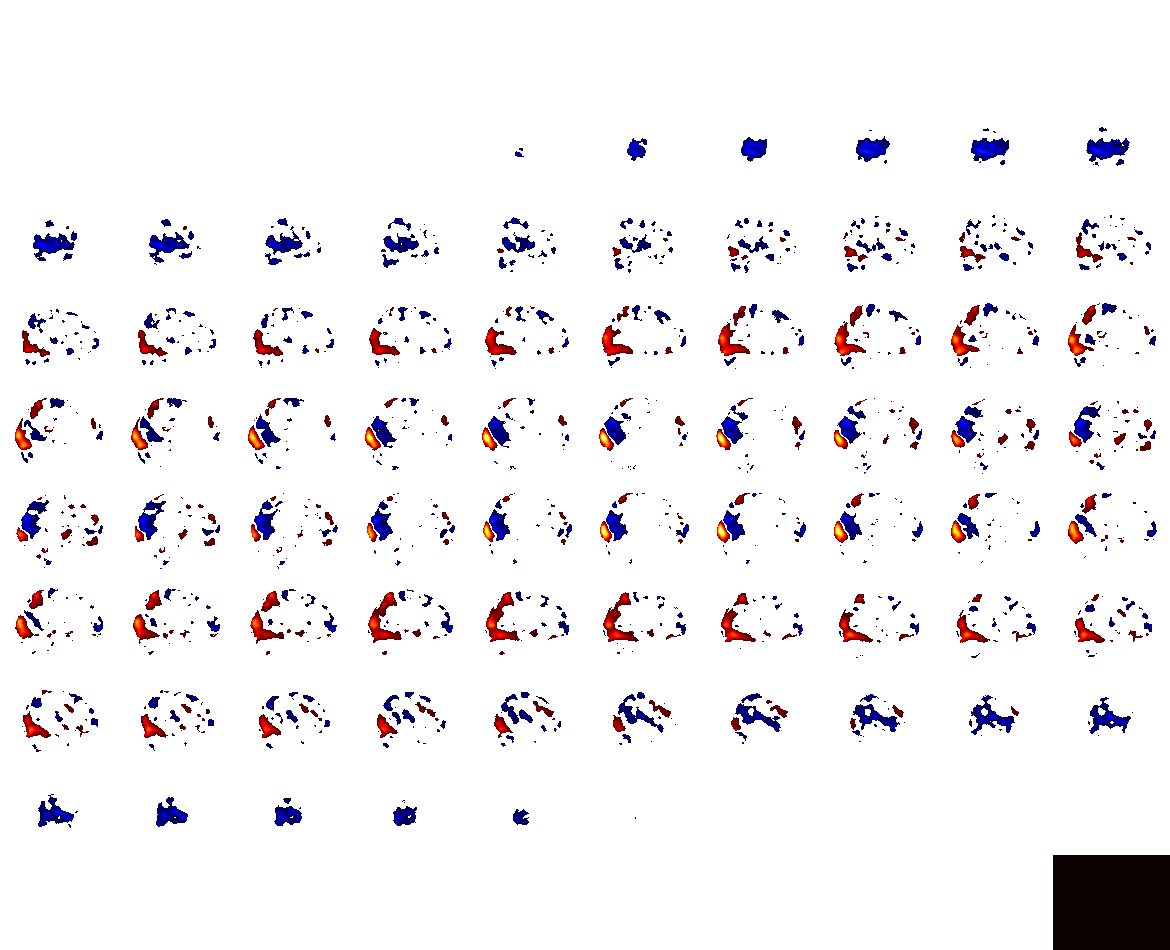

In [39]:
test_mask_data = np.empty((79, 95, 79))
test_mask_data[:] = np.nan
test_mask_data_flat = test_mask_data.flatten()
test_mask_data_flat = group_avg[40]
# With no F order
from nilearn.image import new_img_like
test_mask_nii = new_img_like(resampled_mask, test_mask_data_flat.reshape(79, 95, 79))
view = plotting.view_img(test_mask_nii, cmap='cold_hot', threshold=0.3)
view

# Correlation

In [ ]:
import numpy as np
import os

# Directory and file paths
data_dir = r"N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\30subs"
beta_file = os.path.join(data_dir, "beta_all.npy")
# z_file    = os.path.join(data_dir, "z_all.npy")

# Load back the arrays
beta_all  = np.load(beta_file)
# z_all     = np.load(z_file)

print("Loaded beta_all shape:", beta_all.shape)
# print("Loaded z_all shape:", z_all.shape)


In [30]:
beta_all.shape

(30, 600, 79, 95, 79)

In [9]:
beta_flat = beta_all.reshape(beta_all.shape[0], beta_all.shape[1], -1)
beta_flat.shape

(30, 600, 592895)

In [8]:
# Read the stimuli information for the 600 trials
stimuli = pd.read_csv("./stimuli_600trials.csv")
stimuli

,run,OriginalOrder,img,emotion_type,AI,group
0,1,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,1,2,5395_2.jpg,neutral,YES,neutralAI
3,1,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,1,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,10,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,10,596,9140.jpg,unpleasant,NO,unpleasant
597,10,597,2446.jpg,neutral,NO,neutral
598,10,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [10]:
group_order = ['pleasant', 'neutral', 'unpleasant',
               'pleasantAI', 'neutralAI', 'unpleasantAI']
# CORRECT METHOD:
# Save the original index positions before sorting
stimuli['original_idx'] = stimuli.index

# Sort by group
stimuli['group_order_idx'] = stimuli['group'].apply(lambda g: group_order.index(g))
stimuli_sorted = stimuli.sort_values(by=['group_order_idx', 'original_idx']).reset_index(drop=True)

# Use the saved original indices (NOT 'OriginalOrder' column!)
sorted_indices = stimuli_sorted['original_idx'].values
stimuli_sorted

,run,OriginalOrder,img,emotion_type,AI,group,original_idx,group_order_idx
0,1,4,2550.jpg,pleasant,NO,pleasant,4,0
1,1,18,4505.jpg,pleasant,NO,pleasant,18,0
2,1,19,2314.jpg,pleasant,NO,pleasant,19,0
3,1,26,4597.jpg,pleasant,NO,pleasant,26,0
4,1,30,4180.jpg,pleasant,NO,pleasant,30,0
...,...,...,...,...,...,...,...,...
595,10,576,9630_0.jpg,unpleasant,YES,unpleasantAI,576,5
596,10,577,3051_0.jpg,unpleasant,YES,unpleasantAI,577,5
597,10,583,9300_1.jpg,unpleasant,YES,unpleasantAI,583,5
598,10,595,3016_1.jpg,unpleasant,YES,unpleasantAI,595,5


In [11]:
beta_flat_sorted = beta_flat[:, sorted_indices, :]

In [40]:
beta_flat_sorted.shape

(30, 600, 592895)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr

# Define the comparisons you want
comparisons = [
    ('pleasant', 'neutral'),
    ('unpleasant', 'pleasant'),
    ('unpleasant', 'neutral')
]

# Storage for all correlation results
all_correlation_results = {}

print("="*70)
print("CROSS-CONDITION PATTERN CORRELATION ANALYSIS")
print("="*70)
print(f"Data shape: {beta_flat_sorted.shape}")
print(f"Number of subjects: 30")
print(f"Number of ROIs: {len(roi_masks)}")
print(f"Comparisons: {comparisons}")
print("="*70)

# Calculate total iterations for progress bar
n_comparisons = len(comparisons)
n_rois = len(roi_masks)
n_subjects = 30
total_iterations = n_comparisons * n_rois * n_subjects


    
# Loop through comparisons
for condition1, condition2 in comparisons:
    comparison_name = f"{condition1}_vs_{condition2}"
    all_correlation_results[comparison_name] = {}
    
    # Print comparison header
    print(f"\n{'='*70}")
    print(f"Processing: {comparison_name}")
    print(f"{'='*70}\n")
    
    # Get trial indices for both conditions from stimuli_sorted
    cond1_mask = stimuli_sorted['group'] == condition1
    cond2_mask = stimuli_sorted['group'] == condition2
    
    cond1_trial_indices = stimuli_sorted[cond1_mask].index.values
    cond2_trial_indices = stimuli_sorted[cond2_mask].index.values
    
    n_trials_cond1 = len(cond1_trial_indices)
    n_trials_cond2 = len(cond2_trial_indices)
    
    # Loop through each ROI
    for roi_name, roi_mask in roi_masks.items():
        
        # Flatten the ROI mask and get voxel indices
        flat_roi_data = roi_mask.get_fdata().flatten()
        voxel_indices = np.where(flat_roi_data)[0]
        n_voxels = len(voxel_indices)
        
        # Print ROI info
        print(f"{roi_name}: {n_voxels} voxels")
        
        # Storage for subject correlations
        subject_correlations = []
        
        # Loop over each subject
        for subject in range(n_subjects):
            
            # Extract data for this subject, both conditions, and ROI voxels
            # Shape: (n_trials, n_voxels)
            data_cond1 = beta_flat_sorted[subject, cond1_trial_indices, :][:, voxel_indices]
            data_cond2 = beta_flat_sorted[subject, cond2_trial_indices, :][:, voxel_indices]
            
            # Remove NaN columns (voxels that are all NaN)
            valid_voxels_cond1 = ~np.all(np.isnan(data_cond1), axis=0)
            valid_voxels_cond2 = ~np.all(np.isnan(data_cond2), axis=0)
            valid_voxels = valid_voxels_cond1 & valid_voxels_cond2
            
            data_cond1 = data_cond1[:, valid_voxels]
            data_cond2 = data_cond2[:, valid_voxels]
            
            n_valid_voxels = data_cond1.shape[1]
            
            # Storage for all pairwise trial correlations
            trial_correlations = []
            
            # Loop through all trial pairs between conditions
            for trial1 in range(n_trials_cond1):
                for trial2 in range(n_trials_cond2):
                    
                    # Get voxel patterns for these trials
                    pattern1 = data_cond1[trial1, :]
                    pattern2 = data_cond2[trial2, :]
                    
                    # Remove any remaining NaN values for this pair
                    valid_mask = ~(np.isnan(pattern1) | np.isnan(pattern2))
                    n_valid = np.sum(valid_mask)
                    
                    # Need at least 10 valid voxels for reliable correlation
                    if n_valid >= 10:
                        pattern1_clean = pattern1[valid_mask]
                        pattern2_clean = pattern2[valid_mask]
                        
                        # Calculate Pearson correlation
                        corr, _ = pearsonr(pattern1_clean, pattern2_clean)
                        trial_correlations.append(corr)
            
            # Average all trial-to-trial correlations for this subject
            if len(trial_correlations) > 0:
                avg_corr = np.mean(trial_correlations)
                subject_correlations.append(avg_corr)
            else:
                subject_correlations.append(np.nan)
            
            pbar.update(1)
        
        # Store results for this ROI
        all_correlation_results[comparison_name][roi_name] = subject_correlations

        # Print summary statistics for this ROI
        mean_corr = np.nanmean(subject_correlations)
        std_corr = np.nanstd(subject_correlations)
        print(f"  Mean correlation: {mean_corr:.4f} ± {std_corr:.4f}\n")

print("\n" + "="*70)
print("CORRELATION ANALYSIS COMPLETE!")
print("="*70)



CROSS-CONDITION PATTERN CORRELATION ANALYSIS
Data shape: (30, 600, 592895)
Number of subjects: 30
Number of ROIs: 16
Comparisons: [('pleasant', 'neutral'), ('unpleasant', 'pleasant'), ('unpleasant', 'neutral')]

Processing: pleasant_vs_neutral

V1v: 856 voxels
  Mean correlation: 0.1603 ± 0.1153

V1d: 748 voxels
  Mean correlation: 0.2021 ± 0.1362

V2v: 727 voxels
  Mean correlation: 0.1456 ± 0.1073

V2d: 645 voxels
  Mean correlation: 0.2115 ± 0.1411

V3v: 527 voxels
  Mean correlation: 0.1949 ± 0.1347

V3d: 517 voxels
  Mean correlation: 0.2049 ± 0.1416

hV4: 328 voxels
  Mean correlation: 0.1512 ± 0.1285

V3a: 554 voxels
  Mean correlation: 0.1816 ± 0.1333

V3b: 263 voxels
  Mean correlation: 0.1610 ± 0.1318

LO1: 324 voxels
  Mean correlation: 0.1649 ± 0.1205

LO2: 125 voxels
  Mean correlation: 0.1173 ± 0.1132

VO1: 153 voxels
  Mean correlation: 0.1367 ± 0.0909

VO2: 253 voxels
  Mean correlation: 0.1034 ± 0.0788

IPS: 973 voxels
  Mean correlation: 0.0871 ± 0.0610

PHC1: 175 vox

In [45]:
beta_flat_sorted.shape

(30, 600, 592895)

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_within_run_condition_variability(beta_flat_sorted, stimuli_sorted):
    """
    Analyze trial-to-trial variability within each run and condition
    
    Parameters:
    - beta_flat_sorted: (30 subjects, 600 trials, 592895 voxels)
    - stimuli_sorted: DataFrame with 'group' and 'run' columns
    """
    
    print("="*70)
    print("WITHIN-RUN, WITHIN-CONDITION VARIABILITY ANALYSIS")
    print("="*70)
    print(f"Data shape: {beta_flat_sorted.shape}")
    print()
    
    # Get unique conditions and runs
    conditions = stimuli_sorted['group'].unique()
    runs = sorted(stimuli_sorted['run'].unique())
    
    print(f"Conditions: {list(conditions)}")
    print(f"Runs: {list(runs)}")
    print()
    
    # Storage for results
    results = []
    
    # Analyze each condition and run
    for condition in conditions:
        for run in runs:
            # Get trial indices for this condition and run
            mask = (stimuli_sorted['group'] == condition) & (stimuli_sorted['run'] == run)
            trial_indices = stimuli_sorted[mask].index.values
            
            n_trials = len(trial_indices)
            
            if n_trials == 0:
                continue
            
            # Extract data for all subjects, these trials
            # Shape: (30 subjects, n_trials, 592895 voxels)
            data = beta_flat_sorted[:, trial_indices, :]
            
            # Calculate standard deviation across trials (within this run-condition combo)
            # For each subject and voxel, get std across trials
            # Then average across subjects and voxels
            within_run_cond_std = np.nanstd(data, axis=1)  # Std across trials
            mean_std = np.nanmean(within_run_cond_std)  # Average across subjects and voxels
            
            # Also get overall std for this run-condition
            overall_std = np.nanstd(data)
            
            results.append({
                'Condition': condition,
                'Run': run,
                'N_trials': n_trials,
                'Mean_std': mean_std,
                'Overall_std': overall_std
            })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Display results
    print("="*70)
    print("RESULTS: WITHIN-RUN, WITHIN-CONDITION VARIABILITY")
    print("="*70)
    print()
    
    # Print by condition
    for condition in conditions:
        print(f"\n{condition.upper()}")
        print("-"*70)
        cond_data = results_df[results_df['Condition'] == condition]
        print(f"{'Run':<6} {'N Trials':<10} {'Mean Std':<12} {'Overall Std':<12}")
        print("-"*70)
        
        for _, row in cond_data.iterrows():
            print(f"{row['Run']:<6} {row['N_trials']:<10} {row['Mean_std']:<12.4f} {row['Overall_std']:<12.4f}")
        
        # Condition summary
        mean_across_runs = cond_data['Mean_std'].mean()
        std_across_runs = cond_data['Mean_std'].std()
        print(f"\n  Condition mean: {mean_across_runs:.4f} ± {std_across_runs:.4f}")
    
    # Overall summary
    print("\n" + "="*70)
    print("SUMMARY ACROSS ALL CONDITIONS AND RUNS")
    print("="*70)
    
    summary_by_condition = results_df.groupby('Condition')['Mean_std'].agg(['mean', 'std', 'min', 'max'])
    print("\nBy Condition:")
    print(summary_by_condition)
    
    summary_by_run = results_df.groupby('Run')['Mean_std'].agg(['mean', 'std', 'min', 'max'])
    print("\nBy Run:")
    print(summary_by_run)
    
    # Check if certain runs are consistently noisier
    print("\n" + "="*70)
    print("RUN-WISE ANALYSIS")
    print("="*70)
    run_means = results_df.groupby('Run')['Mean_std'].mean().sort_values(ascending=False)
    print("\nRuns ordered by variability (highest to lowest):")
    for run, std in run_means.items():
        print(f"  Run {run}: {std:.4f}")
    
    # Check if certain conditions are consistently noisier
    print("\n" + "="*70)
    print("CONDITION-WISE ANALYSIS")
    print("="*70)
    cond_means = results_df.groupby('Condition')['Mean_std'].mean().sort_values(ascending=False)
    print("\nConditions ordered by variability (highest to lowest):")
    for cond, std in cond_means.items():
        print(f"  {cond}: {std:.4f}")
    
    return results_df

# Run the analysis
results_df = analyze_within_run_condition_variability(beta_flat_sorted, stimuli_sorted)

WITHIN-RUN, WITHIN-CONDITION VARIABILITY ANALYSIS
Data shape: (30, 600, 592895)

Conditions: ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']
Runs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

RESULTS: WITHIN-RUN, WITHIN-CONDITION VARIABILITY


PLEASANT
----------------------------------------------------------------------
Run    N Trials   Mean Std     Overall Std 
----------------------------------------------------------------------
1      10         1.5262       2.1542      
2      10         1.6474       2.2963      
3      10         1.7567       2.4686      
4      10         1.7348       2.5262      
5      10         1.6644       2.3824      
6      10         1.7684       2.5334      
7      10         1.7588       2.5288      
8      10         1.7194       2.5409      
9      10         1.9954       3.2104      
10     10         2.0859       4.0951      


# Decoding: Random averaging

In [6]:
import numpy as np
import os

# Directory and file paths
data_dir = r"N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\30subs"
beta_file = os.path.join(data_dir, "beta_all.npy")
# z_file    = os.path.join(data_dir, "z_all.npy")

# Load back the arrays
beta_all  = np.load(beta_file)
# z_all     = np.load(z_file)

print("Loaded beta_all shape:", beta_all.shape)
# print("Loaded z_all shape:", z_all.shape)


Loaded beta_all shape: (30, 600, 79, 95, 79)


## Within modality decoding

### Decoding using beta values

In [19]:
beta_all.shape

(30, 600, 79, 95, 79)

In [20]:
beta_flat = beta_all.reshape(beta_all.shape[0], beta_all.shape[1], -1)
beta_flat.shape

(30, 600, 592895)

#### 1st sorrting method

In [25]:
stimuli

,run,OriginalOrder,img,emotion_type,AI,group,group_order_idx
0,1,0,2045_2.jpg,pleasant,YES,pleasantAI,3
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI,5
2,1,2,5395_2.jpg,neutral,YES,neutralAI,4
3,1,3,3230_0.jpg,unpleasant,YES,unpleasantAI,5
4,1,4,2550.jpg,pleasant,NO,pleasant,0
...,...,...,...,...,...,...,...
595,10,595,3016_1.jpg,unpleasant,YES,unpleasantAI,5
596,10,596,9140.jpg,unpleasant,NO,unpleasant,2
597,10,597,2446.jpg,neutral,NO,neutral,1
598,10,598,9570_1.jpg,unpleasant,YES,unpleasantAI,5


In [22]:
# CORRECT METHOD:
# Save the original index positions before sorting
stimuli['original_idx'] = stimuli.index

# Sort by group
stimuli['group_order_idx'] = stimuli['group'].apply(lambda g: group_order.index(g))
stimuli_sorted = stimuli.sort_values(by='group_order_idx').reset_index(drop=True)

# Use the saved original indices (NOT 'OriginalOrder' column!)
sorted_indices = stimuli_sorted['original_idx'].values
beta_flat_sorted = beta_flat[:, sorted_indices, :]

In [23]:
stimuli_sorted

,run,OriginalOrder,img,emotion_type,AI,group,original_idx,group_order_idx
0,1,39,4604.jpg,pleasant,NO,pleasant,39,0
1,1,41,4601.jpg,pleasant,NO,pleasant,41,0
2,1,43,4628.jpg,pleasant,NO,pleasant,43,0
3,7,384,7451.jpg,pleasant,NO,pleasant,384,0
4,7,394,4770.jpg,pleasant,NO,pleasant,394,0
...,...,...,...,...,...,...,...,...
595,10,576,9630_0.jpg,unpleasant,YES,unpleasantAI,576,5
596,1,21,9075_0.jpg,unpleasant,YES,unpleasantAI,21,5
597,10,598,9570_1.jpg,unpleasant,YES,unpleasantAI,598,5
598,1,3,3230_0.jpg,unpleasant,YES,unpleasantAI,3,5


testing the sorting like 2nd method

In [16]:
# CORRECT METHOD:
# Save the original index positions before sorting
stimuli['original_idx'] = stimuli.index

# Sort by group
stimuli['group_order_idx'] = stimuli['group'].apply(lambda g: group_order.index(g))
stimuli_sorted = stimuli.sort_values(by=['group_order_idx','OriginalOrder']).reset_index(drop=True)

# Use the saved original indices (NOT 'OriginalOrder' column!)
sorted_indices = stimuli_sorted['original_idx'].values
beta_flat_sorted = beta_flat[:, sorted_indices, :]

In [17]:
stimuli_sorted

,run,OriginalOrder,img,emotion_type,AI,group,original_idx,group_order_idx
0,1,4,2550.jpg,pleasant,NO,pleasant,4,0
1,1,18,4505.jpg,pleasant,NO,pleasant,18,0
2,1,19,2314.jpg,pleasant,NO,pleasant,19,0
3,1,26,4597.jpg,pleasant,NO,pleasant,26,0
4,1,30,4180.jpg,pleasant,NO,pleasant,30,0
...,...,...,...,...,...,...,...,...
595,10,576,9630_0.jpg,unpleasant,YES,unpleasantAI,576,5
596,10,577,3051_0.jpg,unpleasant,YES,unpleasantAI,577,5
597,10,583,9300_1.jpg,unpleasant,YES,unpleasantAI,583,5
598,10,595,3016_1.jpg,unpleasant,YES,unpleasantAI,595,5


#### 2nd sorrting method

In [24]:
# data = beta_flat
data = beta_flat_nan

# Define the groups
groups = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# Split the data into smaller batches
batch_size = 100
num_batches = int(np.ceil(data.shape[0] / batch_size))

reordered_measures_list = []
indices_list = []
# Process data in batches
for batch_index in range(num_batches):
    start_index = batch_index * batch_size
    end_index = min((batch_index + 1) * batch_size, data.shape[0])

    batch_measures = data[start_index:end_index]

    batch_reordered_measures = []
    index_list = []
    # Process each measure in the batch
    for i in range(batch_measures.shape[0]):
        measure = batch_measures[i]
        reordered_measure = np.empty_like(measure)  # Create an empty array of the same shape
        reordered_index = 0
        
        # Process each group
        for group in groups:
            indices = stimuli.index[stimuli['group'] == group].tolist()
            for idx in indices:
                reordered_measure[reordered_index] = measure[idx]
                reordered_index += 1
            index_list.append(indices)
        batch_reordered_measures.append(reordered_measure)
        indices_list.append(np.array(index_list))
    reordered_measures_list.extend(batch_reordered_measures)

# Concatenate the reordered measures
beta_flat_sorted = np.array(reordered_measures_list)
# reordered_single_trial_z = np.array(reordered_measures_list)


NameError: name 'beta_flat_nan' is not defined

#### Test sorting methods

In [45]:
# METHOD 1 - Get sorted indices
stimuli['original_idx'] = stimuli.index
stimuli['group_order_idx'] = stimuli['group'].apply(lambda g: group_order.index(g))
stimuli_sorted_method1 = stimuli.sort_values(by='group_order_idx').reset_index(drop=True)
sorted_indices_method1 = stimuli_sorted_method1['original_idx'].values

print("=" * 60)
print("METHOD 1 - DataFrame sorting")
print("=" * 60)
cumulative = 0
for group in group_order:
    mask = stimuli_sorted_method1['group'] == group
    count = mask.sum()
    # Get the original indices for this group in sorted order
    group_indices = sorted_indices_method1[cumulative:cumulative + count]
    print(f"{group}: {group_indices}")
    cumulative += count

# METHOD 2 - Get sorted indices  
sorted_indices_method2 = []
for group in groups:
    indices = stimuli.index[stimuli['group'] == group].tolist()
    sorted_indices_method2.extend(indices)

sorted_indices_method2 = np.array(sorted_indices_method2)

print("\n" + "=" * 60)
print("METHOD 2 - Group-by-group extraction")
print("=" * 60)
cumulative = 0
for group in groups:
    indices = stimuli.index[stimuli['group'] == group].tolist()
    count = len(indices)
    group_indices = sorted_indices_method2[cumulative:cumulative + count]
    print(f"{group}: {group_indices}")
    cumulative += count

# Quick comparison
print("\n" + "=" * 60)
print("MATCH CHECK")
print("=" * 60)
for group in group_order:
    mask1 = stimuli_sorted_method1['group'] == group
    indices1 = set(sorted_indices_method1[mask1])
    indices2 = set(stimuli.index[stimuli['group'] == group].tolist())
    match = indices1 == indices2
    print(f"{group}: Indices match = {match}")

METHOD 1 - DataFrame sorting
pleasant: [ 39  41  43 384 394 594   4  26 401 407 365 367 370 398 400 347 503 504
 505 507  47  56  61 328 335 336 338 340 344 419 423 428 430 435  71  74
 301 304 312 519 523 529 530 267 268 270 272 273 277  93  99 102 108 249
 252 259 262 491 500 211 215 233 197 202 206 207 208 113 116 117 185 186
 542 445 446 448 449 454 177 157 170 172 174 441 126 562 138 141 142 151
 567 570 573  30  18  19 581 582 584 591]
neutral: [484   6 589 586  16 146 136 563 555 514 383 412 411 409 404 403 356 354
 372 361 357 549 132 129 122 171 168  55  51  48 513 501 427 425 422 346
 342 323 321  62 164 162 178  80  73  72  67  65  64 319 318 434 431 540
 537 534 194 190 308 271 293 518 290 416 100 282 281 280 276 469 464 462
 459 209 265 254 243 458 110 109 210 239 497 489 487 545 544 231 227 223
 220 218  15  32  31 568  24 597 386  37]
unpleasant: [ 38  11 387 396 596 565  22 566 232 543 228 580  34 574 572 463 255 260
 198 261 200 244 111 246 437 438 494 495 493 490 488 

#### Decoding

In [29]:
subs =          ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
                'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20',
                'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']

selected_subs = ['Sub1', 'Sub2',         'Sub4', 'Sub5', 'Sub6', 'Sub7',         'Sub9', 'Sub10', 
                 'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20', 
                 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']


# subs =  ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
#          'Sub11']

# selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub10', 'Sub11']

# Create a mapping from selected_subs to their corresponding index in subs list
selected_indices = [subs.index(sub) for sub in selected_subs]
len(selected_indices)

28

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm import tqdm

# Define the comparisons you want to loop through
comparisons = [
    ('pleasant', 'neutral'),
    ('pleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI')
]

# Initialize a dictionary to store the accuracies for each comparison and ROI
accuracy_results = {}

# Get the total number of iterations for progress tracking
n_comparisons = len(comparisons)
n_rois = len(roi_masks)
n_subjects = len(selected_indices)
n_repeats = 50
n_folds = 4
total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds

# Initialize the tqdm progress bar
with tqdm(total=total_iterations, desc="Decoding Progress") as pbar:
    # Loop through the comparisons
    for condition1, condition2 in comparisons:
        # print(f"Decoding {condition1} vs {condition2}...")

        # Get the indices of the conditions in the group_order
        condition1_idx = group_order.index(condition1)
        condition2_idx = group_order.index(condition2)

        accuracy_rois = []

        # Loop through each ROI
        for m, (roi_name, roi_mask) in enumerate(roi_masks.items()):
            # print(f"Decoding ROI: {roi_name}...")

            # Flatten the ROI mask and get the indices of the ROI voxels
            flat_roi_data = roi_mask.get_fdata().flatten()
            indices = np.where(flat_roi_data)[0]

            # Extract the relevant data from z_series_sorted for the current ROI
            # data = z_flat_sorted[:, :, indices]
            data = beta_flat_sorted[:, :, indices]

            accuracy_subs = []

            # Loop over each subject
            for subject in selected_indices:
                # Extract trials for condition1 and condition2
                subject_data = data[subject]
                condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
                condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]

                # Remove NaN columns
                condition1_trials = condition1_trials[:, ~np.isnan(condition1_trials[0, :])]
                condition2_trials = condition2_trials[:, ~np.isnan(condition2_trials[0, :])]

                assert condition1_trials.shape[1] >= 0.8 * len(indices), \
                    f"Voxels are less than 80% of the length of indices."

                accuracies = []
                # Perform 50 repeats of 4-fold cross-validation
                for repeat in range(n_repeats):
                    kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                    condition1_indices = np.arange(condition1_trials.shape[0])
                    condition2_indices = np.arange(condition2_trials.shape[0])

                    for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                        # Split the training and testing data
                        train_condition1 = condition1_trials[train_idx]
                        train_condition2 = condition2_trials[train_idx]
                        test_condition1 = condition1_trials[test_idx]
                        test_condition2 = condition2_trials[test_idx]

                        # Average the training trials into 3 groups
                        train_condition1_averaged = np.mean(np.array_split(train_condition1, 3, axis=0), axis=1)
                        train_condition2_averaged = np.mean(np.array_split(train_condition2, 3, axis=0), axis=1)

                        # Keep the test trials as one group
                        test_condition1_averaged = np.mean(test_condition1, axis=0, keepdims=True)
                        test_condition2_averaged = np.mean(test_condition2, axis=0, keepdims=True)

                        # Combine the training and testing data
                        train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                        train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                        test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                        test_labels = np.array([1] * test_condition1_averaged.shape[0] + [0] * test_condition2_averaged.shape[0])

                        # Train the SVM classifier
                        clf = SVC(kernel='linear')
                        clf.fit(train_data, train_labels)
                        accuracy = clf.score(test_data, test_labels)
                        accuracies.append(accuracy)

                        # Update progress bar after each fold
                        pbar.update(1)

                # Store the average accuracy across repeats for this subject
                accuracy_subs.append(np.mean(accuracies))

            # Store the average accuracy across subjects for this ROI
            accuracy_rois.append(np.array(accuracy_subs))

        # Store the results for the current comparison
        accuracy_results[f"{condition1}_vs_{condition2}"] = np.array(accuracy_rois)


Decoding Progress: 100%|██████████| 358400/358400 [04:11<00:00, 1424.97it/s]


#### Plotting

In [31]:
comparisons

[('pleasant', 'neutral'),
 ('pleasant', 'unpleasant'),
 ('pleasant', 'pleasantAI'),
 ('pleasant', 'neutralAI'),
 ('pleasant', 'unpleasantAI'),
 ('neutral', 'unpleasant'),
 ('neutral', 'pleasantAI'),
 ('neutral', 'neutralAI'),
 ('neutral', 'unpleasantAI'),
 ('unpleasant', 'pleasantAI'),
 ('unpleasant', 'neutralAI'),
 ('unpleasant', 'unpleasantAI'),
 ('pleasantAI', 'neutralAI'),
 ('pleasantAI', 'unpleasantAI'),
 ('neutralAI', 'unpleasantAI')]

In [33]:
# comparisons_order = ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI', 'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']
# comparisons_order = ['pleasant_vs_neutral', 'pleasant_vs_unpleasant', 'pleasant_vs_pleasantAI', 'pleasant_vs_unpleasantAI']
# comparisons_order = ['pleasantAI_vs_neutral', 'pleasantAI_vs_unpleasant', 'pleasantAI_vs_neutralAI', 'pleasantAI_vs_unpleasantAI']
comparisons_order = [
    'pleasant_vs_neutral',
    'pleasant_vs_unpleasant',
    'pleasant_vs_pleasantAI',
    'pleasant_vs_neutralAI',
    'pleasant_vs_unpleasantAI',
    'neutral_vs_unpleasant',
    'neutral_vs_pleasantAI',
    'neutral_vs_neutralAI',
    'neutral_vs_unpleasantAI',
    'unpleasant_vs_pleasantAI',
    'unpleasant_vs_neutralAI',
    'unpleasant_vs_unpleasantAI',
    'pleasantAI_vs_neutralAI',
    'pleasantAI_vs_unpleasantAI',
    'neutralAI_vs_unpleasantAI'
]

# Initialize an array to store accuracies for each comparison, ROI, and subject
n_comparisons = len(comparisons_order)
n_rois = 16  # 16 ROIs
n_subjects = 28  # 30 subjects

# Create a 3D array to hold the accuracy data: (comparisons, ROIs, subjects)
accuracies_avg = np.zeros((n_comparisons, n_rois, n_subjects))

# Fill in the accuracies_avg array with data from accuracy_results
for comp_idx, comparison in enumerate(comparisons_order):
    accuracies_avg[comp_idx, :, :] = accuracy_results[comparison]


28 subjects

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_15392\1520762594.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


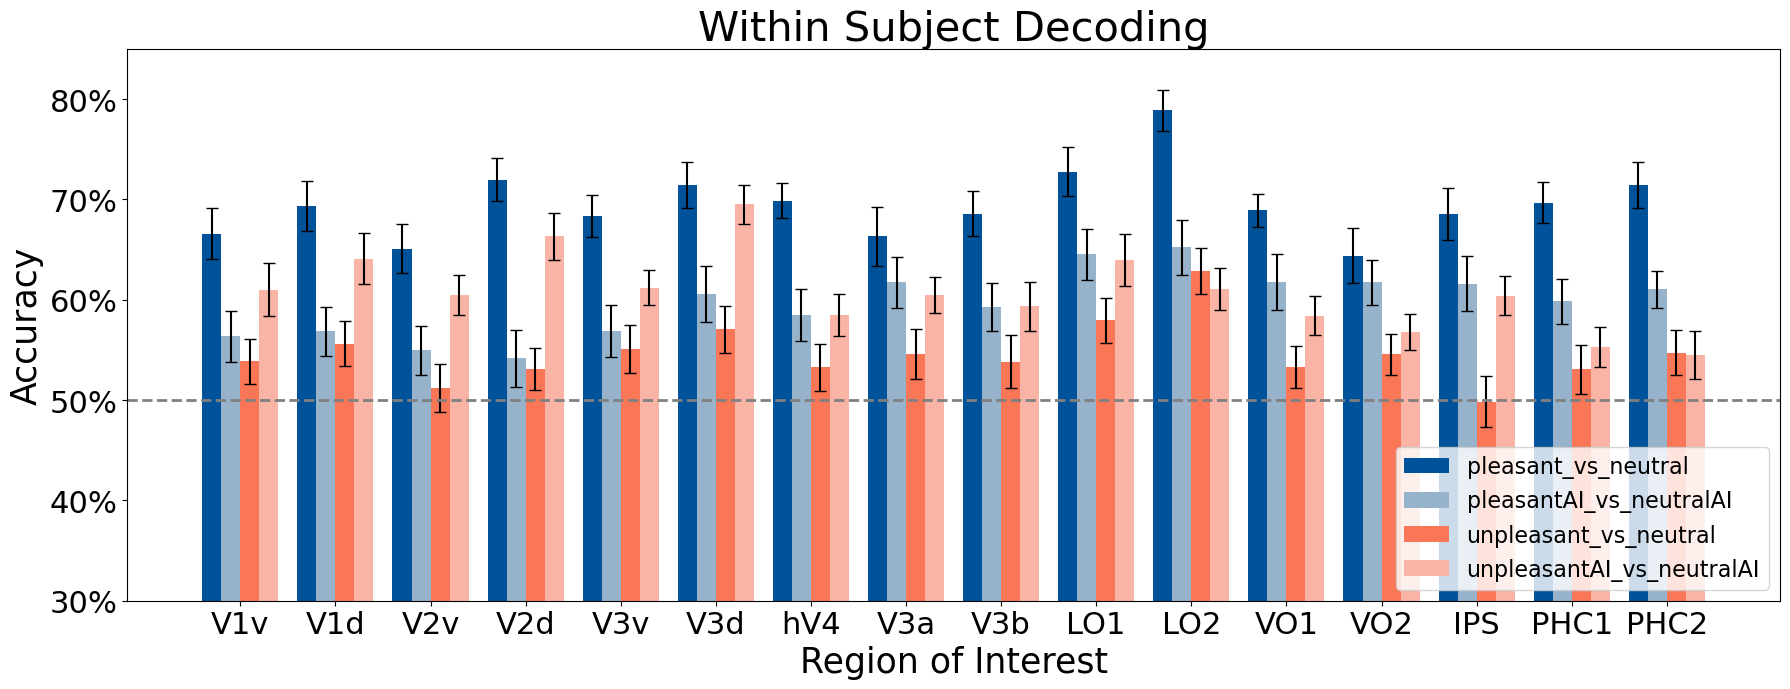

In [118]:
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color


# Compute mean and SEM (subject-wise)
mean_values = np.mean(accuracies_avg, axis=2)
sem_values = np.std(accuracies_avg, axis=2, ddof=1) / np.sqrt(accuracies_avg.shape[2])

# Plot with SEM error bars
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)
rois = list(roi_masks.keys())

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=comparisons_order[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Subject Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')

# percentage labels for y-axis
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_15392\2658684167.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


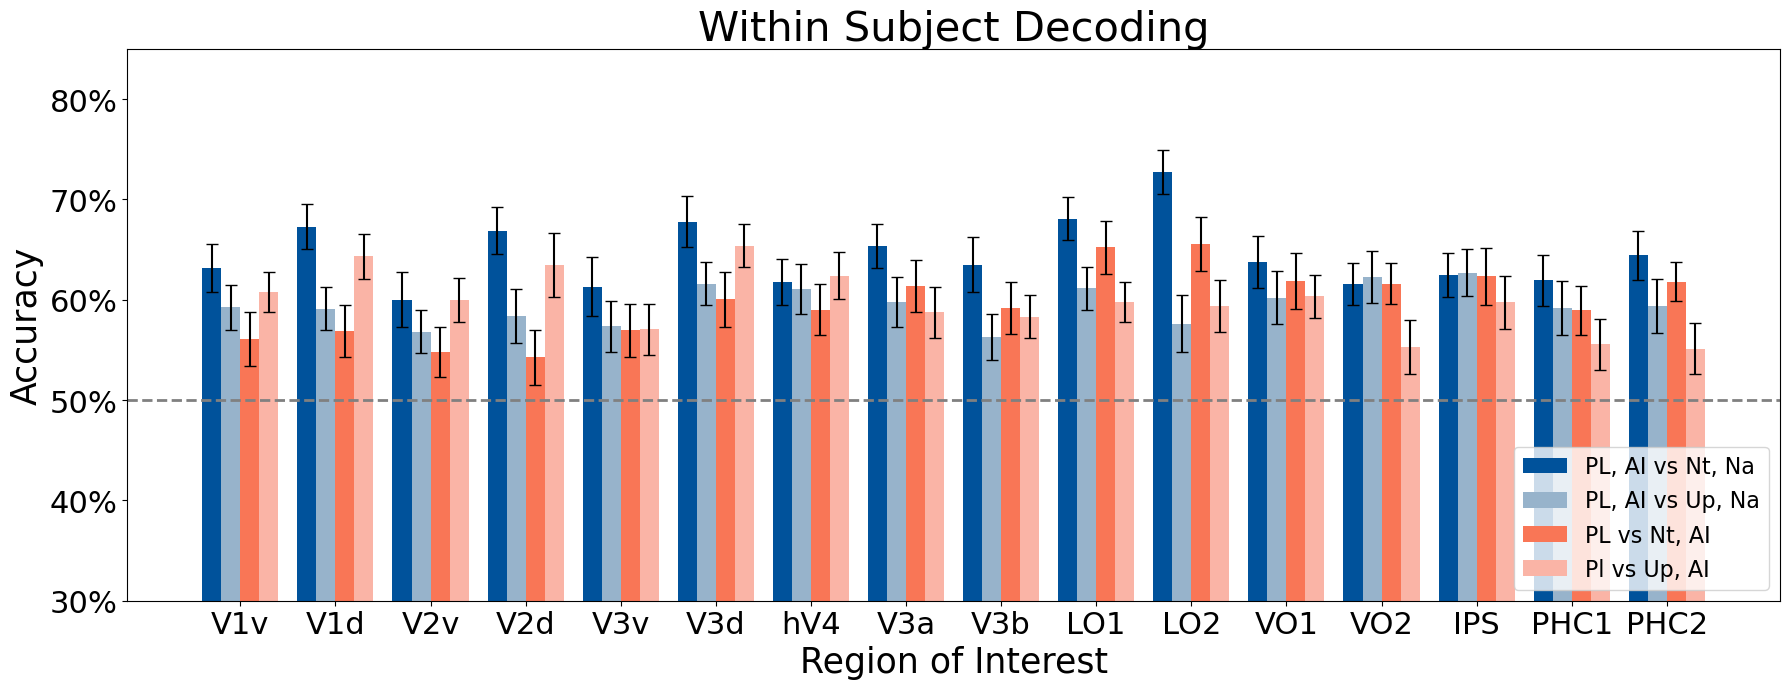

In [103]:
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

# Define legends for each comparison
legends = ['PL, AI vs Nt, Na', 'PL, AI vs Up, Na', 'PL vs Nt, AI', 'Pl vs Up, AI']

# Compute mean and SEM (subject-wise)
mean_values = np.mean(accuracies_avg_toplot, axis=2)                 # mean across subjects
sem_values  = np.std(accuracies_avg_toplot, axis=2, ddof=1) / np.sqrt(accuracies_avg_toplot.shape[2])  # SEM across subjects

# Plot with SEM error bars
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)
rois = list(roi_masks.keys())

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=legends[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Subject Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')

# percentage labels for y-axis
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()


Sorting with randomized order within group

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_15392\2800919608.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


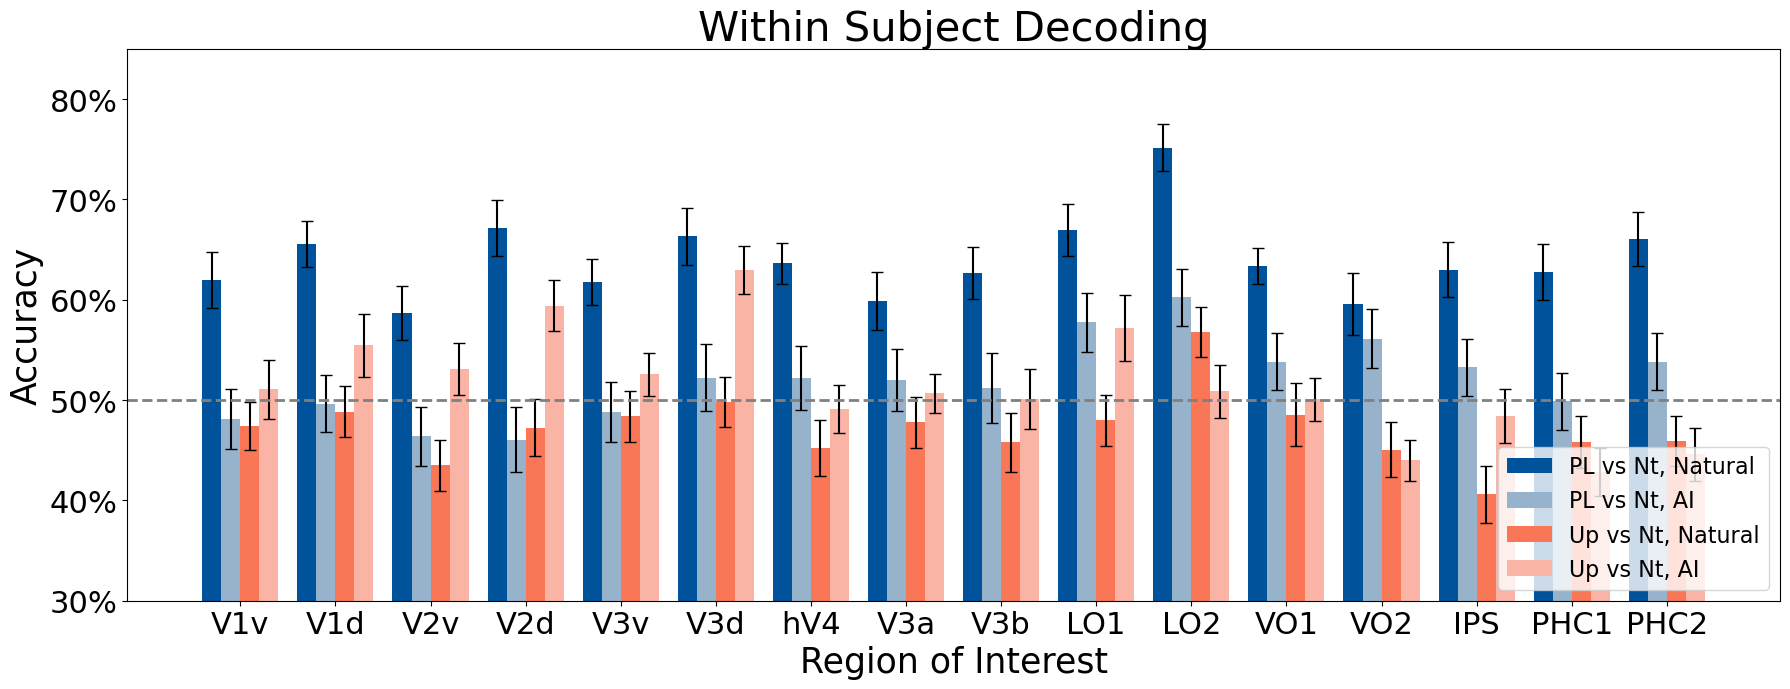

In [27]:
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

# Define legends for each comparison
legends = ['PL vs Nt, Natural', 'PL vs Nt, AI', 'Up vs Nt, Natural', 'Up vs Nt, AI']

# Compute mean and SEM (subject-wise)
mean_values = np.mean(accuracies_avg_toplot, axis=2)                 # mean across subjects
sem_values  = np.std(accuracies_avg_toplot, axis=2, ddof=1) / np.sqrt(accuracies_avg_toplot.shape[2])  # SEM across subjects

# Plot with SEM error bars
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)
rois = list(roi_masks.keys())

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=legends[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Subject Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')

# percentage labels for y-axis
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()


Sorting With ascending order within group

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_10932\1813329534.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


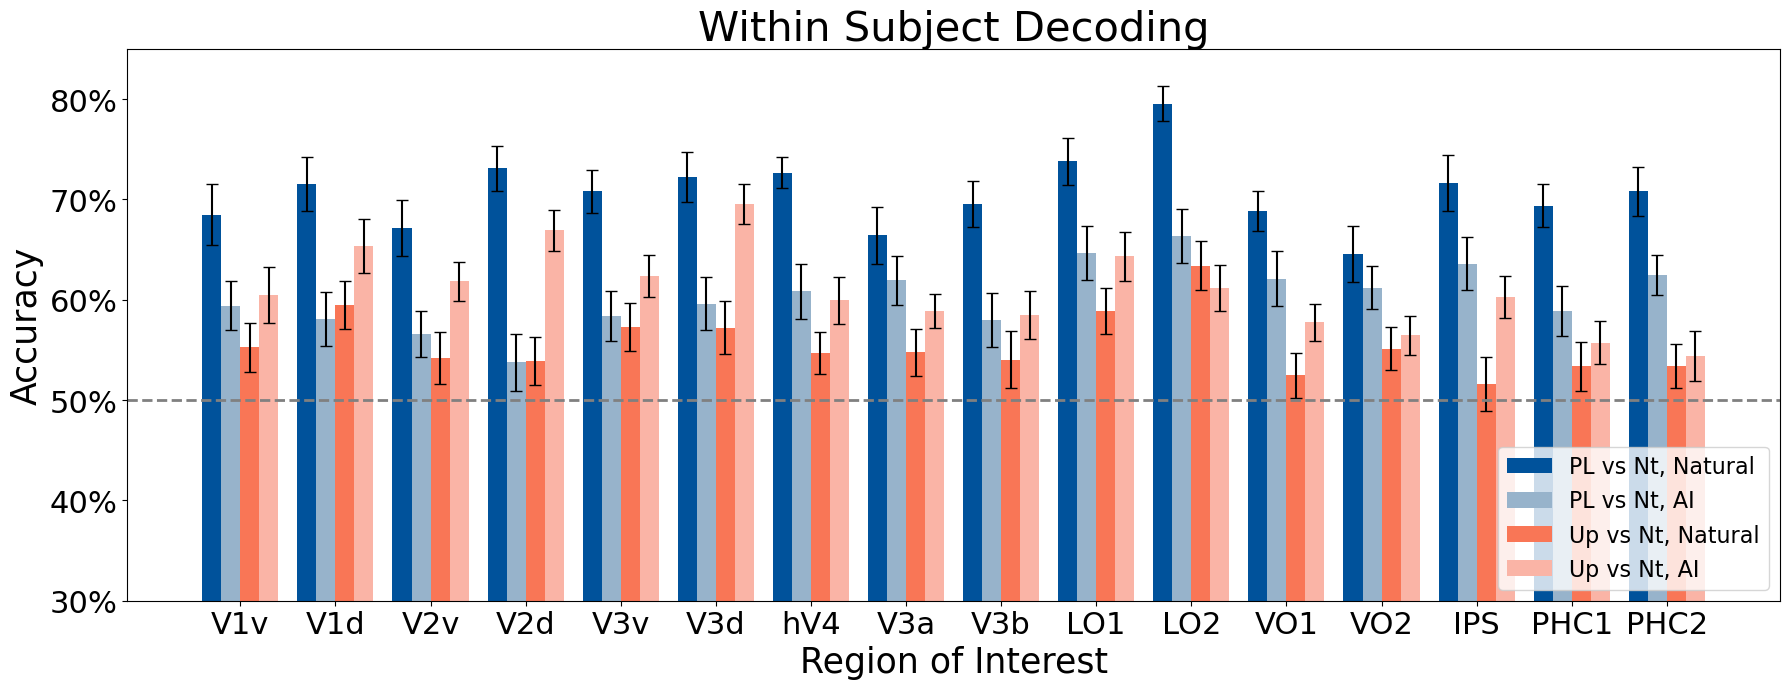

In [42]:
# Compute mean and SEM (subject-wise)
mean_values = np.mean(accuracies_avg_toplot, axis=2)                 # mean across subjects
sem_values  = np.std(accuracies_avg_toplot, axis=2, ddof=1) / np.sqrt(accuracies_avg_toplot.shape[2])  # SEM across subjects

# Plot with SEM error bars
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)
rois = list(roi_masks.keys())

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=legends[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Subject Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')

# percentage labels for y-axis
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()


### Decode using z scores

In [7]:
beta_flat = beta_all.reshape(beta_all.shape[0], beta_all.shape[1], -1)

beta_flat_nan = beta_flat.copy()

# Replace zeros with NaN (treat as invalid data)
beta_flat_nan[beta_flat_nan == 0] = np.nan

In [10]:
import numpy as np

# Step 1: Z-score within each run
print("Performing within-run z-scoring...")

# Create a copy to avoid modifying original data
beta_flat_zscored = beta_flat_nan.copy()

# Get unique runs
unique_runs = stimuli['run'].unique()
print(f"Found {len(unique_runs)} runs: {sorted(unique_runs)}")

# Z-score within each run
for run_id in unique_runs:
    # Get indices for this run
    run_mask = stimuli['run'] == run_id
    run_indices = np.where(run_mask)[0]
    
    # Extract data for this run
    run_data = beta_flat[:, run_indices, :]
    
    # Z-score across trials within this run (for each subject and voxel)
    mean = np.mean(run_data, axis=1, keepdims=True)
    std = np.std(run_data, axis=1, keepdims=True)
    
    # Avoid division by zero
    std[std == 0] = 1
    
    # Z-score and put back
    beta_flat_zscored[:, run_indices, :] = (run_data - mean) / std
    
    print(f"  Run {run_id}: {len(run_indices)} trials z-scored")

# Step 2: Sort by group (Method 2 - preserving temporal order within groups)
print("\nSorting trials by group (preserving temporal order)...")

groups = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# Get sorted indices using Method 2 approach
sorted_indices = []
for group in groups:
    # Get indices for this group (already in temporal order from DataFrame)
    group_indices = stimuli.index[stimuli['group'] == group].tolist()
    sorted_indices.extend(group_indices)
    print(f"  {group}: {len(group_indices)} trials")

sorted_indices = np.array(sorted_indices)

# Apply sorting
z_flat_sorted = beta_flat_zscored[:, sorted_indices, :]

print(f"\nFinal shape: {z_flat_sorted.shape}")
print("z_flat_sorted created successfully!")

# Verify the structure
print("\nVerifying 100-trial blocks:")
for i, group in enumerate(groups):
    start_idx = i * 100
    end_idx = (i + 1) * 100
    
    # Check what groups these positions correspond to
    actual_groups = stimuli.iloc[sorted_indices[start_idx:end_idx]]['group'].values
    all_match = np.all(actual_groups == group)
    
    print(f"  Block {i} (pos {start_idx}-{end_idx-1}): {group} - All match: {all_match}")

Performing within-run z-scoring...
Found 10 runs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Run 1: 60 trials z-scored
  Run 2: 60 trials z-scored
  Run 3: 60 trials z-scored
  Run 4: 60 trials z-scored
  Run 5: 60 trials z-scored
  Run 6: 60 trials z-scored
  Run 7: 60 trials z-scored
  Run 8: 60 trials z-scored
  Run 9: 60 trials z-scored
  Run 10: 60 trials z-scored

Sorting trials by group (preserving temporal order)...
  pleasant: 100 trials
  neutral: 100 trials
  unpleasant: 100 trials
  pleasantAI: 100 trials
  neutralAI: 100 trials
  unpleasantAI: 100 trials

Final shape: (30, 600, 592895)
z_flat_sorted created successfully!

Verifying 100-trial blocks:
  Block 0 (pos 0-99): pleasant - All match: True
  Block 1 (pos 100-199): neutral - All match: True
  Block 2 (pos 200-299): unpleasant - All match: True
  Block 3 (pos 300-399): pleasantAI - All match: True
  Block 4 (pos 400-499): neutr

In [39]:
sorted_indices

array([  4,  18,  19,  26,  30,  39,  41,  43,  47,  56,  61,  71,  74,
        93,  99, 102, 108, 113, 116, 117, 126, 138, 141, 142, 151, 157,
       170, 172, 174, 177, 185, 186, 197, 202, 206, 207, 208, 211, 215,
       233, 249, 252, 259, 262, 267, 268, 270, 272, 273, 277, 301, 304,
       312, 328, 335, 336, 338, 340, 344, 347, 365, 367, 370, 384, 394,
       398, 400, 401, 407, 419, 423, 428, 430, 435, 441, 445, 446, 448,
       449, 454, 491, 500, 503, 504, 505, 507, 519, 523, 529, 530, 542,
       562, 567, 570, 573, 581, 582, 584, 591, 594,   6,  15,  16,  24,
        31,  32,  37,  48,  51,  55,  62,  64,  65,  67,  72,  73,  80,
       100, 109, 110, 122, 129, 132, 136, 146, 162, 164, 168, 171, 178,
       190, 194, 209, 210, 218, 220, 223, 227, 231, 239, 243, 254, 265,
       271, 276, 280, 281, 282, 290, 293, 308, 318, 319, 321, 323, 342,
       346, 354, 356, 357, 361, 372, 383, 386, 403, 404, 409, 411, 412,
       416, 422, 425, 427, 431, 434, 458, 459, 462, 464, 469, 48

In [13]:
subs =          ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
                'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20',
                'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']

selected_subs = ['Sub1', 'Sub2',         'Sub4', 'Sub5', 'Sub6', 'Sub7',         'Sub9',  
                 'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20', 
                 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']


# subs =  ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
#          'Sub11']

# selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub10', 'Sub11']

# Create a mapping from selected_subs to their corresponding index in subs list
selected_indices = [subs.index(sub) for sub in selected_subs]
len(selected_indices)

27

In [15]:
group_order = ['pleasant', 'neutral', 'unpleasant',
               'pleasantAI', 'neutralAI', 'unpleasantAI']

In [16]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm import tqdm

# Define the comparisons you want to loop through
comparisons = [
    ('pleasant', 'neutral'),
    ('pleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI')
]

# Initialize a dictionary to store the accuracies for each comparison and ROI
accuracy_results = {}

# Get the total number of iterations for progress tracking
n_comparisons = len(comparisons)
n_rois = len(roi_masks)
n_subjects = len(selected_indices)
n_repeats = 20
n_folds = 4
total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds

# Initialize the tqdm progress bar
with tqdm(total=total_iterations, desc="Decoding Progress") as pbar:
    # Loop through the comparisons
    for condition1, condition2 in comparisons:
        # print(f"Decoding {condition1} vs {condition2}...")

        # Get the indices of the conditions in the group_order
        condition1_idx = group_order.index(condition1)
        condition2_idx = group_order.index(condition2)

        accuracy_rois = []

        # Loop through each ROI
        for m, (roi_name, roi_mask) in enumerate(roi_masks.items()):
            # print(f"Decoding ROI: {roi_name}...")

            # Flatten the ROI mask and get the indices of the ROI voxels
            flat_roi_data = roi_mask.get_fdata().flatten()
            indices = np.where(flat_roi_data)[0]

            # Extract the relevant data from z_series_sorted for the current ROI
            # data = z_flat_sorted[:, :, indices]
            data = z_flat_sorted[:, :, indices]

            accuracy_subs = []

            # Loop over each subject
            for subject in selected_indices:
                # Extract trials for condition1 and condition2
                subject_data = data[subject]
                condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
                condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]

                # Remove NaN columns
                condition1_trials = condition1_trials[:, ~np.isnan(condition1_trials[0, :])]
                condition2_trials = condition2_trials[:, ~np.isnan(condition2_trials[0, :])]

                assert condition1_trials.shape[1] >= 0.8 * len(indices), \
                    f"Voxels are less than 80% of the length of indices."

                accuracies = []
                # Perform 50 repeats of 4-fold cross-validation
                for repeat in range(n_repeats):
                    kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                    condition1_indices = np.arange(condition1_trials.shape[0])
                    condition2_indices = np.arange(condition2_trials.shape[0])

                    for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                        # Split the training and testing data
                        train_condition1 = condition1_trials[train_idx]
                        train_condition2 = condition2_trials[train_idx]
                        test_condition1 = condition1_trials[test_idx]
                        test_condition2 = condition2_trials[test_idx]

                        # Average the training trials into 3 groups
                        train_condition1_averaged = np.mean(np.array_split(train_condition1, 3, axis=0), axis=1)
                        train_condition2_averaged = np.mean(np.array_split(train_condition2, 3, axis=0), axis=1)

                        # Keep the test trials as one group
                        test_condition1_averaged = np.mean(test_condition1, axis=0, keepdims=True)
                        test_condition2_averaged = np.mean(test_condition2, axis=0, keepdims=True)

                        # Combine the training and testing data
                        train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                        train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                        test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                        test_labels = np.array([1] * test_condition1_averaged.shape[0] + [0] * test_condition2_averaged.shape[0])

                        # Train the SVM classifier
                        clf = SVC(kernel='linear')
                        clf.fit(train_data, train_labels)
                        accuracy = clf.score(test_data, test_labels)
                        accuracies.append(accuracy)

                        # Update progress bar after each fold
                        pbar.update(1)

                # Store the average accuracy across repeats for this subject
                accuracy_subs.append(np.mean(accuracies))

            # Store the average accuracy across subjects for this ROI
            accuracy_rois.append(np.array(accuracy_subs))

        # Store the results for the current comparison
        accuracy_results[f"{condition1}_vs_{condition2}"] = np.array(accuracy_rois)


Decoding Progress: 100%|██████████| 138240/138240 [01:40<00:00, 1378.42it/s]


In [18]:
comparisons_order = ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI', 'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']

# Initialize an array to store accuracies for each comparison, ROI, and subject
n_comparisons = len(comparisons_order)
n_rois = 16  # 16 ROIs
n_subjects = 27  # 30 subjects

# Create a 3D array to hold the accuracy data: (comparisons, ROIs, subjects)
accuracies_avg = np.zeros((n_comparisons, n_rois, n_subjects))

# Fill in the accuracies_avg array with data from accuracy_results
for comp_idx, comparison in enumerate(comparisons_order):
    accuracies_avg[comp_idx, :, :] = accuracy_results[comparison]

# accuracies_avg_toplot = np.delete(accuracies_avg, 2, axis=2)
accuracies_avg_toplot = accuracies_avg
accuracies_avg_toplot.shape


(4, 16, 27)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18308\2940412950.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


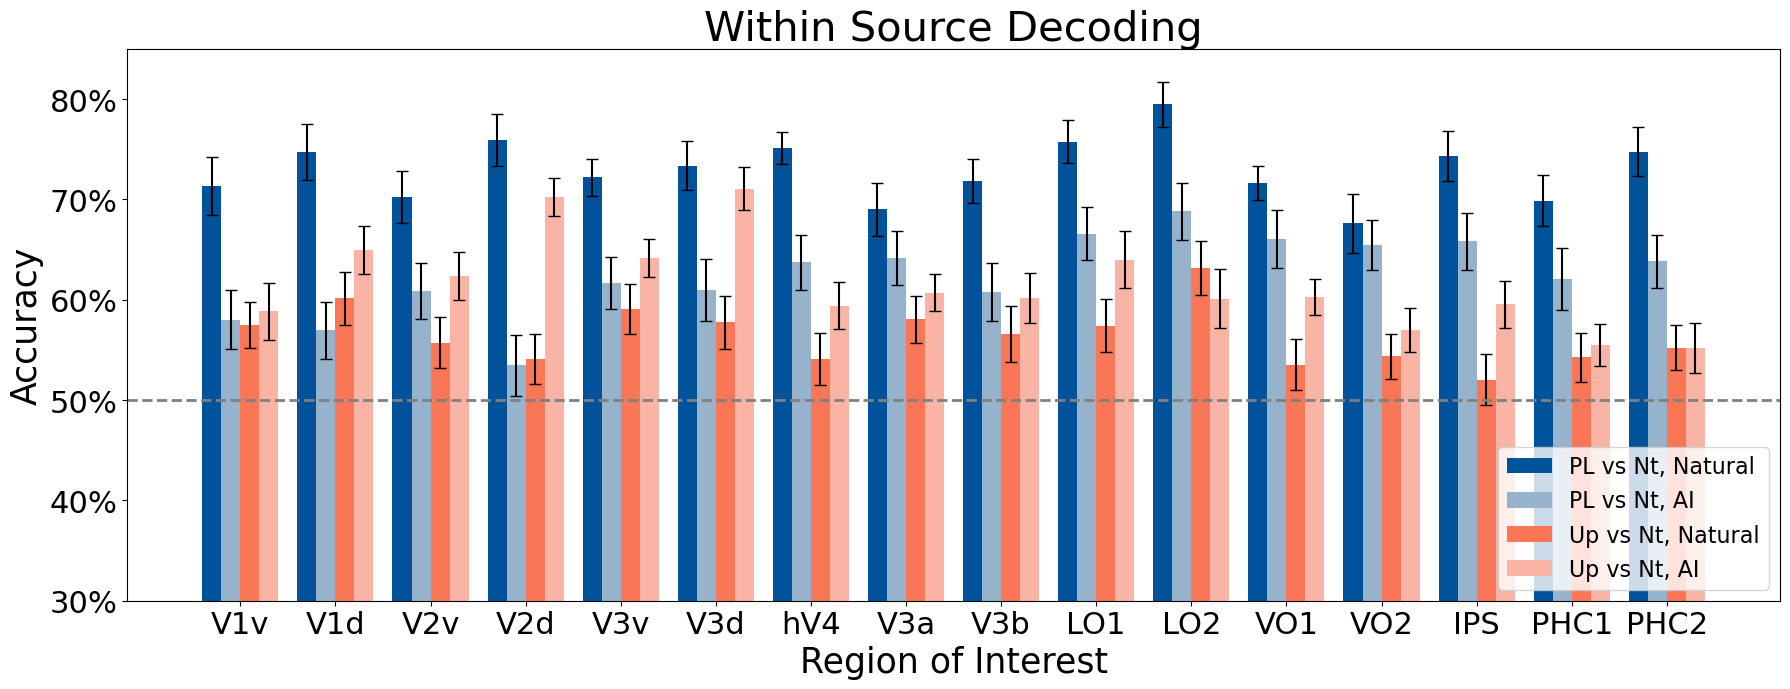

In [21]:
legends = ['PL vs Nt, Natural', 'PL vs Nt, AI', 'Up vs Nt, Natural', 'Up vs Nt, AI']
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

# Compute mean and SEM (subject-wise)
mean_values = np.mean(accuracies_avg_toplot, axis=2)                 # mean across subjects
sem_values  = np.std(accuracies_avg_toplot, axis=2, ddof=1) / np.sqrt(accuracies_avg_toplot.shape[2])  # SEM across subjects

# Plot with SEM error bars
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)
rois = list(roi_masks.keys())

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=legends[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Source Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')

# percentage labels for y-axis
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()


## Two days decoding

In [7]:
beta_flat = beta_all.reshape(beta_all.shape[0], beta_all.shape[1], -1)

beta_flat_nan = beta_flat.copy()

# Replace zeros with NaN (treat as invalid data)
beta_flat_nan[beta_flat_nan == 0] = np.nan

In [8]:
beta_flat_nan.shape

(30, 600, 592895)

This general beta file is based on the original trial and run sequence kept from the SPM single trial beta estimation code, same as the stimuli file. 

sort method 1

In [9]:
import pandas as pd
import numpy as np

# Load your CSV file
stimuli = pd.read_csv("./stimuli_600trials.csv")


In [10]:
groups = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# Create a categorical column with custom order
stimuli['group_cat'] = pd.Categorical(stimuli['group'], categories=groups, ordered=True)

# Sort by the custom group order
stimuli_sorted = stimuli.sort_values(by=['group_cat', 'OriginalOrder']).reset_index(drop=True)

# Drop the temporary categorical column if you don't need it
stimuli_sorted = stimuli_sorted.drop(columns=['group_cat'])

# Get the sorted index order (from the original file)
sorted_indices = stimuli_sorted['OriginalOrder'].values

stimuli_sorted

,run,OriginalOrder,img,emotion_type,AI,group
0,1,4,2550.jpg,pleasant,NO,pleasant
1,1,18,4505.jpg,pleasant,NO,pleasant
2,1,19,2314.jpg,pleasant,NO,pleasant
3,1,26,4597.jpg,pleasant,NO,pleasant
4,1,30,4180.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,10,576,9630_0.jpg,unpleasant,YES,unpleasantAI
596,10,577,3051_0.jpg,unpleasant,YES,unpleasantAI
597,10,583,9300_1.jpg,unpleasant,YES,unpleasantAI
598,10,595,3016_1.jpg,unpleasant,YES,unpleasantAI


In [11]:
# beta_flat_sorted = beta_flat[:, sorted_indices, ...]
beta_flat_nan_sorted = beta_flat_nan[:, sorted_indices, ...]

sort method 2

In [10]:
del beta_all, beta_flat

In [11]:

# Define the groups
groups = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']
beta_tobesorted = beta_flat_nan.copy()
# Split the data into smaller batches
batch_size = 100
num_batches = int(np.ceil(beta_tobesorted.shape[0] / batch_size))

reordered_measures_list = []
indices_list = []
# Process data in batches
for batch_index in range(num_batches):
    start_index = batch_index * batch_size
    end_index = min((batch_index + 1) * batch_size, beta_tobesorted.shape[0])

    batch_measures = beta_tobesorted[start_index:end_index]

    batch_reordered_measures = []
    index_list = []
    # Process each measure in the batch
    for i in range(batch_measures.shape[0]):
        measure = batch_measures[i]
        reordered_measure = np.empty_like(measure)  # Create an empty array of the same shape
        reordered_index = 0
        
        # Process each group
        for group in groups:
            indices = stimuli.index[stimuli['group'] == group].tolist()
            for idx in indices:
                reordered_measure[reordered_index] = measure[idx]
                reordered_index += 1
            index_list.append(indices)
        batch_reordered_measures.append(reordered_measure)
        indices_list.append(np.array(index_list))
    reordered_measures_list.extend(batch_reordered_measures)

# Concatenate the reordered measures
beta_flat_nan_sorted2 = np.array(reordered_measures_list)


In [15]:
indices_list

[array([[  4,  18,  19,  26,  30,  39,  41,  43,  47,  56,  61,  71,  74,
          93,  99, 102, 108, 113, 116, 117, 126, 138, 141, 142, 151, 157,
         170, 172, 174, 177, 185, 186, 197, 202, 206, 207, 208, 211, 215,
         233, 249, 252, 259, 262, 267, 268, 270, 272, 273, 277, 301, 304,
         312, 328, 335, 336, 338, 340, 344, 347, 365, 367, 370, 384, 394,
         398, 400, 401, 407, 419, 423, 428, 430, 435, 441, 445, 446, 448,
         449, 454, 491, 500, 503, 504, 505, 507, 519, 523, 529, 530, 542,
         562, 567, 570, 573, 581, 582, 584, 591, 594],
        [  6,  15,  16,  24,  31,  32,  37,  48,  51,  55,  62,  64,  65,
          67,  72,  73,  80, 100, 109, 110, 122, 129, 132, 136, 146, 162,
         164, 168, 171, 178, 190, 194, 209, 210, 218, 220, 223, 227, 231,
         239, 243, 254, 265, 271, 276, 280, 281, 282, 290, 293, 308, 318,
         319, 321, 323, 342, 346, 354, 356, 357, 361, 372, 383, 386, 403,
         404, 409, 411, 412, 416, 422, 425, 427, 431, 434

In [16]:
beta_flat_nan_sorted.shape

(30, 600, 592895)

In [25]:
beta_flat_nan_sorted[0,0,102520]

np.float32(0.35264677)

In [17]:
beta_flat_nan_sorted2.shape

(30, 600, 592895)

In [26]:
beta_flat_nan_sorted2[0,0,102520]

np.float32(0.35264677)

In [18]:
are_equal = np.array_equal(beta_flat_nan_sorted[0,0,:], beta_flat_nan_sorted2[0,0,:])
print(f"Arrays are identical: {are_equal}")

Arrays are identical: False


(array([4.0000e+00, 2.0000e+00, 3.0000e+00, 2.0000e+00, 2.0000e+01,
        2.1000e+01, 3.8000e+01, 5.6000e+01, 6.9000e+01, 1.0000e+02,
        1.4100e+02, 1.9600e+02, 2.9900e+02, 4.5100e+02, 7.0800e+02,
        1.0410e+03, 1.6040e+03, 2.4600e+03, 3.9750e+03, 6.1470e+03,
        1.0130e+04, 1.5501e+04, 2.2557e+04, 2.9044e+04, 3.1141e+04,
        2.7956e+04, 2.1302e+04, 1.4858e+04, 9.4860e+03, 5.8640e+03,
        3.5450e+03, 2.2230e+03, 1.4060e+03, 8.2400e+02, 5.3600e+02,
        3.5400e+02, 2.3500e+02, 1.5200e+02, 1.0000e+02, 7.9000e+01,
        5.4000e+01, 3.6000e+01, 3.3000e+01, 3.3000e+01, 1.9000e+01,
        1.9000e+01, 1.4000e+01, 1.0000e+01, 8.0000e+00, 6.0000e+00]),
 array([-1.53509598e+01, -1.47113972e+01, -1.40718346e+01, -1.34322720e+01,
        -1.27927103e+01, -1.21531477e+01, -1.15135851e+01, -1.08740234e+01,
        -1.02344608e+01, -9.59489822e+00, -8.95533562e+00, -8.31577301e+00,
        -7.67621040e+00, -7.03664780e+00, -6.39708614e+00, -5.75752354e+00,
        -5.117

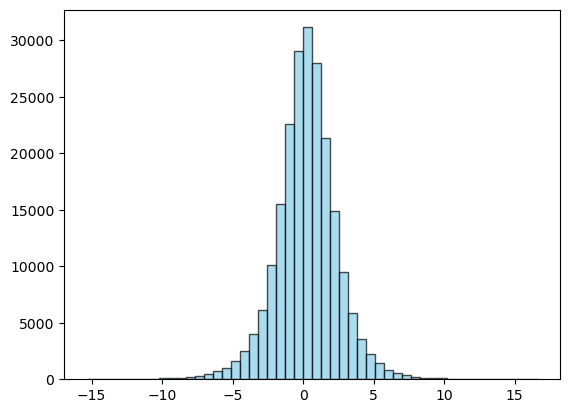

In [28]:
plt.hist(beta_flat_nan_sorted[0,0,:].flatten(), bins=50, color='skyblue', edgecolor='k', alpha=0.7)


(array([4.0000e+00, 2.0000e+00, 3.0000e+00, 2.0000e+00, 2.0000e+01,
        2.1000e+01, 3.8000e+01, 5.6000e+01, 6.9000e+01, 1.0000e+02,
        1.4100e+02, 1.9600e+02, 2.9900e+02, 4.5100e+02, 7.0800e+02,
        1.0410e+03, 1.6040e+03, 2.4600e+03, 3.9750e+03, 6.1470e+03,
        1.0130e+04, 1.5501e+04, 2.2557e+04, 2.9044e+04, 3.1141e+04,
        2.7956e+04, 2.1302e+04, 1.4858e+04, 9.4860e+03, 5.8640e+03,
        3.5450e+03, 2.2230e+03, 1.4060e+03, 8.2400e+02, 5.3600e+02,
        3.5400e+02, 2.3500e+02, 1.5200e+02, 1.0000e+02, 7.9000e+01,
        5.4000e+01, 3.6000e+01, 3.3000e+01, 3.3000e+01, 1.9000e+01,
        1.9000e+01, 1.4000e+01, 1.0000e+01, 8.0000e+00, 6.0000e+00]),
 array([-1.53509598e+01, -1.47113972e+01, -1.40718346e+01, -1.34322720e+01,
        -1.27927103e+01, -1.21531477e+01, -1.15135851e+01, -1.08740234e+01,
        -1.02344608e+01, -9.59489822e+00, -8.95533562e+00, -8.31577301e+00,
        -7.67621040e+00, -7.03664780e+00, -6.39708614e+00, -5.75752354e+00,
        -5.117

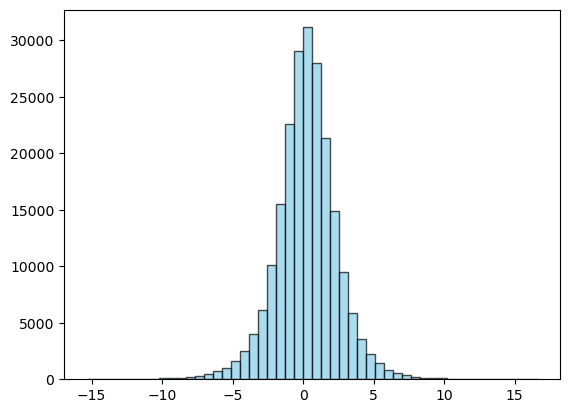

In [29]:
plt.hist(beta_flat_nan_sorted2[0,0,:].flatten(), bins=50, color='skyblue', edgecolor='k', alpha=0.7)


In [30]:
np.count_nonzero(np.isnan(beta_flat_nan_sorted[0,0,:]))

np.int64(378033)

In [31]:
np.count_nonzero(np.isnan(beta_flat_nan_sorted2[0,0,:]))

np.int64(378033)

In [32]:
are_equal = np.array_equal(beta_flat_nan_sorted[5,10,:], beta_flat_nan_sorted2[5,10,:], equal_nan=True)
print(f"Arrays are identical (NaN-aware): {are_equal}")

Arrays are identical (NaN-aware): True


First check (False): Compares NaN == NaN → False, so arrays are "different"
Second check (True): Treats matching NaN positions as equal, so arrays are "identical"

Decoding parameters

In [12]:
all_subs =          ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
                'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20',
                'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']

selected_subs = [ 'Sub1', 'Sub2',            'Sub4', 'Sub5', 'Sub6', 'Sub7',         'Sub9',  
                 'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20', 
                 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']


# subs =  ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
#          'Sub11']

# selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub10', 'Sub11']

# Create a mapping from selected_subs to their corresponding index in subs list
sub_indices = [all_subs.index(sub) for sub in selected_subs]


# Group comparisons
comparisons = [
    ('pleasant', 'neutral'),
    ('pleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI')
]

# Decoding parameters
N_FOLDS = 4
N_REPETITIONS = 10
RANDOM_STATE = 42

# Run selection - modify as needed
# SELECTED_RUNS = [1, 2, 3, 4, 5, 6]  # Use None for all runs, or [1, 2, 3, 4, 5] for specific runs
# SELECTED_RUNS = [7,8,9,10]  # Use None for all runs, or [1, 2, 3, 4, 5] for specific runs
SELECTED_RUNS = [1, 2, 3, 4,7,8]  # Use None for all runs, or [1, 2, 3, 4, 5] for specific runs

print(f'subject count: {len(sub_indices)} \n subject indices: {sub_indices}')
print(f"Folds: {N_FOLDS}, Repetitions: {N_REPETITIONS}")
print(f"Runs: {'All' if SELECTED_RUNS is None else SELECTED_RUNS}")

subject count: 27 
 subject indices: [0, 1, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Folds: 4, Repetitions: 10
Runs: [1, 2, 3, 4, 7, 8]


Day 1: 1-360 all tirals, 1-60 trials in group
Day 1: 361-600 all tirals, 61-100 trials in group

In [49]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

Averaged trials decoding

In [13]:
# Store all results
from sklearn.calibration import LinearSVC
from sklearn.discriminant_analysis import StandardScaler

# beta_data = beta_flat_sorted
# beta_data = beta_flat_nan
beta_data = beta_flat_nan_sorted

stimuli_lable = stimuli_sorted
# stimuli_lable = stimuli

all_results = {}

# Calculate total iterations
total_iterations = len(comparisons) * len(roi_masks) * len(selected_subs) * N_REPETITIONS

# Single progress bar for everything
with tqdm(total=total_iterations, desc="Total Progress") as pbar:
    
    # Loop over comparisons
    for group1, group2 in comparisons:
        comparison_name = f"{group1}_vs_{group2}"
        all_results[comparison_name] = {}
        
        # Loop over ROIs
        for roi_name, roi_mask in roi_masks.items():
            
            # Get ROI voxel indices
            flat_roi_data = roi_mask.get_fdata().flatten()
            indices = np.where(flat_roi_data)[0]
            
            # Filter trials
            mask = stimuli_lable['group'].isin([group1, group2])
            if SELECTED_RUNS is not None:
                mask = mask & stimuli_lable['run'].isin(SELECTED_RUNS)
            trial_indices = np.where(mask)[0]
            labels = stimuli_lable.loc[mask, 'group'].map({group1: 0, group2: 1}).values
            
            # Extract data for selected subjects, trials, and ROI voxels
            data = beta_data[np.ix_(sub_indices, trial_indices, indices)]
            
            # Storage for results
            results_list = []
            
            # Loop over subjects
            for sub_idx_in_selected, sub_idx_original in enumerate(sub_indices):
                X = data[sub_idx_in_selected]
                y = labels
                
                np.random.seed(RANDOM_STATE + sub_idx_original)
                
                # Loop over repetitions
                for rep in range(N_REPETITIONS):
                    shuffled_indices = np.random.permutation(len(trial_indices))
                    X_shuffled = X[shuffled_indices]
                    y_shuffled = y[shuffled_indices]
                    
                    # Cross-validation
                    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=False)
                    fold_accs = []
                    
                    for train_idx, test_idx in skf.split(X_shuffled, y_shuffled):
                        X_train = X_shuffled[train_idx]
                        X_test = X_shuffled[test_idx]
                        y_train = y_shuffled[train_idx]
                        y_test = y_shuffled[test_idx]
                        
                        # Average trials within each class for training
                        train_class0 = X_train[y_train == 0].mean(axis=0, keepdims=True)
                        train_class1 = X_train[y_train == 1].mean(axis=0, keepdims=True)
                        X_train_avg = np.vstack([train_class0, train_class1])
                        y_train_avg = np.array([0, 1])
                        
                        # Average trials within each class for testing
                        test_class0 = X_test[y_test == 0].mean(axis=0, keepdims=True)
                        test_class1 = X_test[y_test == 1].mean(axis=0, keepdims=True)
                        X_test_avg = np.vstack([test_class0, test_class1])
                        y_test_avg = np.array([0, 1])
                        
                        # Standardize
                        scaler = StandardScaler()
                        X_train_avg = scaler.fit_transform(X_train_avg)
                        X_test_avg = scaler.transform(X_test_avg)
                        
                        # Handle NaN values
                        X_train_avg = np.nan_to_num(X_train_avg, nan=0.0)
                        X_test_avg = np.nan_to_num(X_test_avg, nan=0.0)
                        
                        # Train Linear SVM
                        clf = LinearSVC(max_iter=50000, dual='auto', random_state=RANDOM_STATE)
                        clf.fit(X_train_avg, y_train_avg)
                        
                        # Predict
                        y_pred = clf.predict(X_test_avg)
                        
                        # Calculate accuracy
                        fold_accs.append(accuracy_score(y_test_avg, y_pred))
                    
                    results_list.append({
                        'subject': selected_subs[sub_idx_in_selected],
                        'repetition': rep,
                        'accuracy': np.mean(fold_accs)
                    })
                                        
                    pbar.update(1)
            
            all_results[comparison_name][roi_name] = pd.DataFrame(results_list)

print("DECODING COMPLETE!")

Total Progress: 100%|██████████| 17280/17280 [01:32<00:00, 187.53it/s]

DECODING COMPLETE!


In [ ]:
# from sklearn.svm import LinearSVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import accuracy_score

# # beta_data is already sorted by groups
# beta_data = beta_flat_nan_sorted

# # Define group order and their trial indices
# groups = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']
# trials_per_group = 100

# # Create mapping of group name to trial indices
# group_indices = {}
# for i, group in enumerate(groups):
#     start_idx = i * trials_per_group
#     end_idx = start_idx + trials_per_group
#     group_indices[group] = np.arange(start_idx, end_idx)

# print("Group trial indices:")
# for group, indices in group_indices.items():
#     print(f"{group}: {indices[0]} to {indices[-1]} ({len(indices)} trials)")

# # Store all results
# all_results = {}

# # Calculate total iterations
# total_iterations = len(comparisons) * len(roi_masks) * len(selected_subs) * N_REPETITIONS

# # Single progress bar for everything
# with tqdm(total=total_iterations, desc="Total Progress") as pbar:
    
#     # Loop over comparisons
#     for group1, group2 in comparisons:
#         comparison_name = f"{group1}_vs_{group2}"
#         all_results[comparison_name] = {}
        
#         # Get trial indices for both groups
#         group1_trials = group_indices[group1]
#         group2_trials = group_indices[group2]
        
#         # Combine trial indices
#         trial_indices = np.concatenate([group1_trials, group2_trials])
        
#         # Create labels (0 for group1, 1 for group2)
#         labels = np.array([0] * len(group1_trials) + [1] * len(group2_trials))
        
#         print(f"\n{comparison_name}:")
#         print(f"  Group1 ({group1}): {len(group1_trials)} trials → label 0")
#         print(f"  Group2 ({group2}): {len(group2_trials)} trials → label 1")
#         print(f"  Total trials: {len(trial_indices)}")
        
#         # Loop over ROIs
#         for roi_name, roi_mask in roi_masks.items():
            
#             # Get ROI voxel indices
#             flat_roi_data = roi_mask.get_fdata().flatten()
#             voxel_indices = np.where(flat_roi_data)[0]
            
#             # Extract data for selected subjects, trials, and ROI voxels
#             data = beta_data[np.ix_(sub_indices, trial_indices, voxel_indices)]
            
#             # Storage for results
#             results_list = []
            
#             # Loop over subjects
#             for sub_idx_in_selected, sub_idx_original in enumerate(sub_indices):
#                 X = data[sub_idx_in_selected]  # Shape: (n_trials, n_voxels)
#                 y = labels
                
#                 np.random.seed(RANDOM_STATE + sub_idx_original)
                
#                 # Loop over repetitions
#                 for rep in range(N_REPETITIONS):
#                     # Shuffle data
#                     shuffled_indices = np.random.permutation(len(trial_indices))
#                     X_shuffled = X[shuffled_indices]
#                     y_shuffled = y[shuffled_indices]
                    
#                     # Cross-validation
#                     skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=False)
#                     fold_accs = []
                    
#                     for train_idx, test_idx in skf.split(X_shuffled, y_shuffled):
#                         X_train = X_shuffled[train_idx]
#                         X_test = X_shuffled[test_idx]
#                         y_train = y_shuffled[train_idx]
#                         y_test = y_shuffled[test_idx]
                        
#                         # Average trials within each class for training
#                         train_class0 = X_train[y_train == 0].mean(axis=0, keepdims=True)
#                         train_class1 = X_train[y_train == 1].mean(axis=0, keepdims=True)
#                         X_train_avg = np.vstack([train_class0, train_class1])
#                         y_train_avg = np.array([0, 1])
                        
#                         # Average trials within each class for testing
#                         test_class0 = X_test[y_test == 0].mean(axis=0, keepdims=True)
#                         test_class1 = X_test[y_test == 1].mean(axis=0, keepdims=True)
#                         X_test_avg = np.vstack([test_class0, test_class1])
#                         y_test_avg = np.array([0, 1])
                        
#                         # Standardize
#                         scaler = StandardScaler()
#                         X_train_avg = scaler.fit_transform(X_train_avg)
#                         X_test_avg = scaler.transform(X_test_avg)
                        
#                         # Handle NaN values
#                         X_train_avg = np.nan_to_num(X_train_avg, nan=0.0)
#                         X_test_avg = np.nan_to_num(X_test_avg, nan=0.0)
                        
#                         # Train Linear SVM
#                         clf = LinearSVC(max_iter=50000, dual='auto', random_state=RANDOM_STATE)
#                         clf.fit(X_train_avg, y_train_avg)
                        
#                         # Predict
#                         y_pred = clf.predict(X_test_avg)
                        
#                         # Calculate accuracy
#                         fold_accs.append(accuracy_score(y_test_avg, y_pred))
                    
#                     results_list.append({
#                         'subject': selected_subs[sub_idx_in_selected],
#                         'repetition': rep,
#                         'accuracy': np.mean(fold_accs)
#                     })
                    
#                     pbar.update(1)
            
#             all_results[comparison_name][roi_name] = pd.DataFrame(results_list)

# print("\n" + "="*50)
# print("DECODING COMPLETE!")
# print("="*50)

Group trial indices:
pleasant: 0 to 99 (100 trials)
neutral: 100 to 199 (100 trials)
unpleasant: 200 to 299 (100 trials)
pleasantAI: 300 to 399 (100 trials)
neutralAI: 400 to 499 (100 trials)
unpleasantAI: 500 to 599 (100 trials)


Total Progress:   0%|          | 0/17280 [00:00<?, ?it/s]


pleasant_vs_neutral:
  Group1 (pleasant): 100 trials → label 0
  Group2 (neutral): 100 trials → label 1
  Total trials: 200


Total Progress:  25%|██▍       | 4310/17280 [00:29<01:02, 206.42it/s]


pleasantAI_vs_neutralAI:
  Group1 (pleasantAI): 100 trials → label 0
  Group2 (neutralAI): 100 trials → label 1
  Total trials: 200


Total Progress:  50%|████▉     | 8638/17280 [00:58<00:42, 204.91it/s]


unpleasant_vs_neutral:
  Group1 (unpleasant): 100 trials → label 0
  Group2 (neutral): 100 trials → label 1
  Total trials: 200


Total Progress:  75%|███████▍  | 12957/17280 [01:27<00:20, 207.01it/s]


unpleasantAI_vs_neutralAI:
  Group1 (unpleasantAI): 100 trials → label 0
  Group2 (neutralAI): 100 trials → label 1
  Total trials: 200


Total Progress: 100%|██████████| 17280/17280 [01:56<00:00, 147.96it/s]


DECODING COMPLETE!


Single trial decoding (non-averaging)

In [16]:
all_results = {}

# Calculate total iterations
total_iterations = len(comparisons) * len(roi_masks) * len(selected_subs) * N_REPETITIONS

# Single progress bar for everything
with tqdm(total=total_iterations, desc="Total Progress") as pbar:
    
    # Loop over comparisons
    for group1, group2 in comparisons:
        comparison_name = f"{group1}_vs_{group2}"
        all_results[comparison_name] = {}
        
        # Loop over ROIs
        for roi_name, roi_mask in roi_masks.items():
            
            # Get ROI voxel indices
            flat_roi_data = roi_mask.get_fdata().flatten()
            indices = np.where(flat_roi_data)[0]
            
            # Filter trials
            mask = stimuli['group'].isin([group1, group2])
            if SELECTED_RUNS is not None:
                mask = mask & stimuli['run'].isin(SELECTED_RUNS)
            trial_indices = np.where(mask)[0]
            labels = stimuli.loc[mask, 'group'].map({group1: 0, group2: 1}).values
            
            # Extract data for selected subjects, trials, and ROI voxels
            data = beta_flat[np.ix_(sub_indices, trial_indices, indices)]
            
            # Storage for results
            results_list = []
            
            # Loop over subjects
            for sub_idx_in_selected, sub_idx_original in enumerate(sub_indices):
                X = data[sub_idx_in_selected]
                y = labels
                
                np.random.seed(RANDOM_STATE + sub_idx_original)
                
                # Loop over repetitions
                for rep in range(N_REPETITIONS):
                    shuffled_indices = np.random.permutation(len(trial_indices))
                    X_shuffled = X[shuffled_indices]
                    y_shuffled = y[shuffled_indices]
                    
                    # Cross-validation
                    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=False)
                    fold_accs = []
                    
                    for train_idx, test_idx in skf.split(X_shuffled, y_shuffled):
                        X_train = X_shuffled[train_idx]
                        X_test = X_shuffled[test_idx]
                        y_train = y_shuffled[train_idx]
                        y_test = y_shuffled[test_idx]
                        
                        # Standardize
                        scaler = StandardScaler()
                        X_train = scaler.fit_transform(X_train)
                        X_test = scaler.transform(X_test)
                        
                        # Handle NaN values
                        X_train = np.nan_to_num(X_train, nan=0.0)
                        X_test = np.nan_to_num(X_test, nan=0.0)
                        
                        # Train Linear SVM
                        clf = LinearSVC(max_iter=50000, dual='auto', random_state=RANDOM_STATE)
                        clf.fit(X_train, y_train)
                        
                        # Predict
                        y_pred = clf.predict(X_test)
                        y_decision = clf.decision_function(X_test)
                        
                        # Calculate metrics
                        fold_accs.append(accuracy_score(y_test, y_pred))
                    
                    # Store results
                    results_list.append({
                        'subject': selected_subs[sub_idx_in_selected],
                        'repetition': rep,
                        'accuracy': np.mean(fold_accs)
                    })
                    
                    pbar.update(1)
            
            all_results[comparison_name][roi_name] = pd.DataFrame(results_list)

print("DECODING COMPLETE!")

Total Progress:   3%|▎         | 530/17280 [06:29<3:38:13,  1.28it/s] c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Total Progress:   3%|▎         | 536/17280 [06:52<15:38:03,  3.36s/it]c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Total Progress:  28%|██▊       | 4793/17280 [40:23<7:53:34,  2.28s/it] c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Total Progress:  28%|██▊       | 4794/17280 [40:27<9:46:17,  2.82s/it]c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\sklearn\svm\_base.py:125

DECODING COMPLETE!


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_24084\2819474700.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


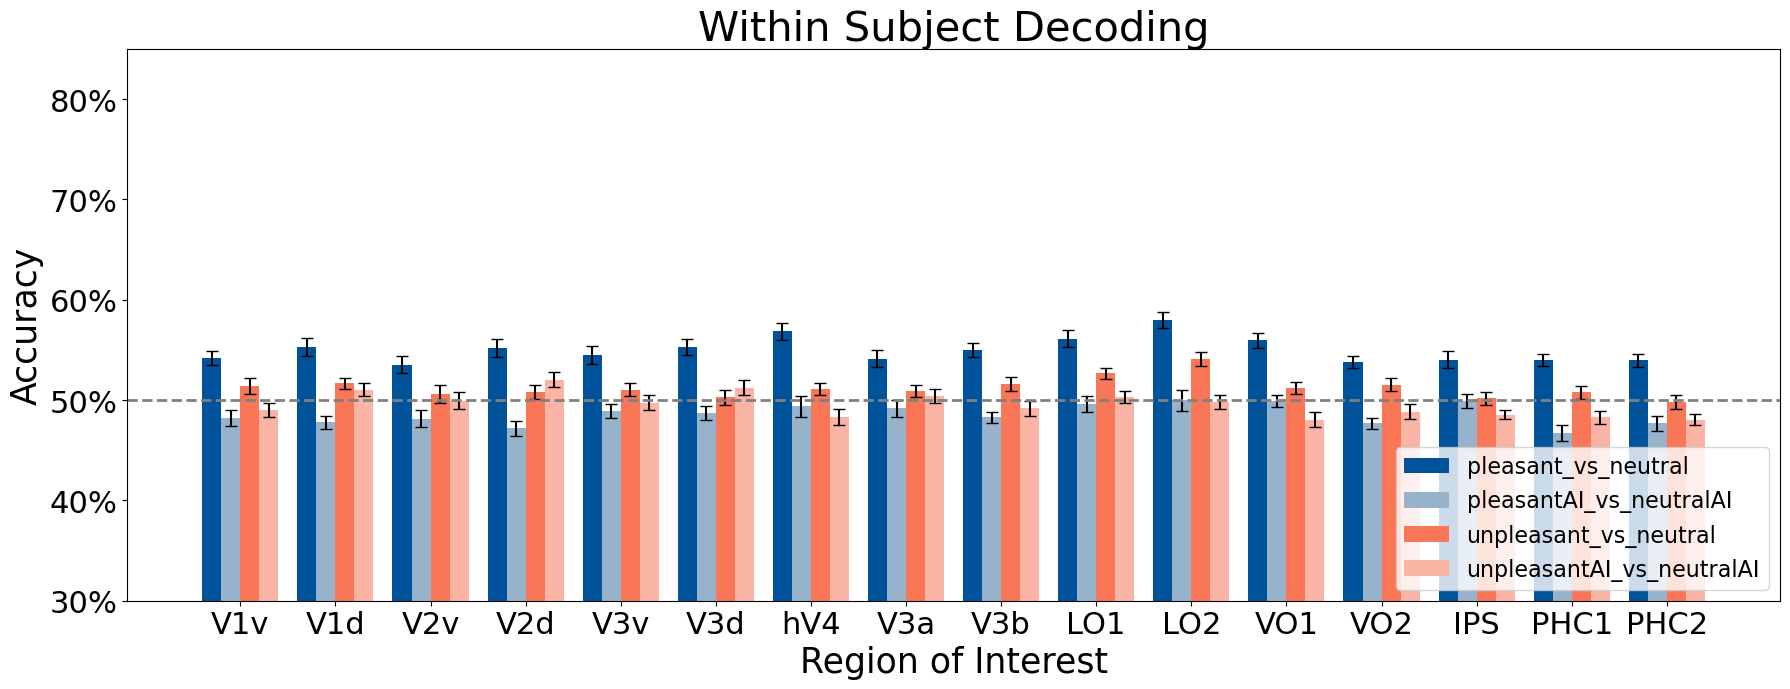

In [17]:
# Extract data from all_results into plotting format
comparisons_order = ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI', 
                     'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']

n_comparisons = len(comparisons_order)
n_rois = len(roi_masks)
n_subjects = len(selected_subs)
rois = list(roi_masks.keys())

# Create array: (comparisons, ROIs, subjects)
accuracies_avg = np.zeros((n_comparisons, n_rois, n_subjects))

# Fill in the array
for comp_idx, comparison in enumerate(comparisons_order):
    for roi_idx, roi_name in enumerate(rois):
        df = all_results[comparison][roi_name]
        # Average across repetitions for each subject
        subject_means = df.groupby('subject')['accuracy'].mean()
        # Ensure correct subject order
        for sub_idx, sub_name in enumerate(selected_subs):
            accuracies_avg[comp_idx, roi_idx, sub_idx] = subject_means[sub_name]

# Colors
colors = [(0/255, 82/255, 155/255),
          (151/255, 179/255, 203/255),
          (249/255, 118/255, 86/255),
          (250/255, 180/255, 166/255)]

# Compute mean and SEM
mean_values = np.mean(accuracies_avg, axis=2)
sem_values = np.std(accuracies_avg, axis=2, ddof=1) / np.sqrt(n_subjects)

# Plot
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=comparisons_order[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Subject Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_24084\2819474700.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


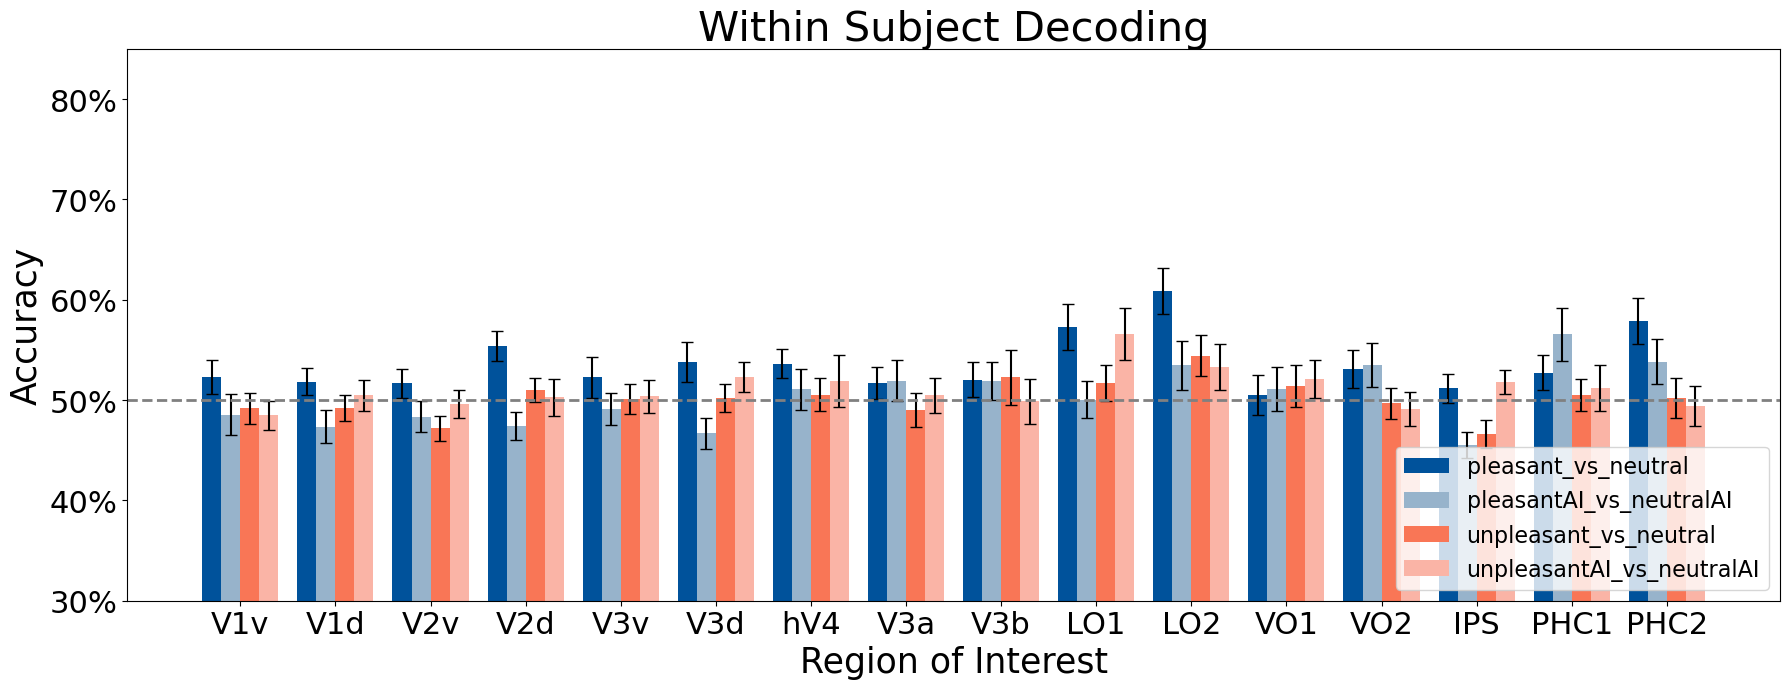

In [15]:
# Extract data from all_results into plotting format
comparisons_order = ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI', 
                     'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']

n_comparisons = len(comparisons_order)
n_rois = len(roi_masks)
n_subjects = len(selected_subs)
rois = list(roi_masks.keys())

# Create array: (comparisons, ROIs, subjects)
accuracies_avg = np.zeros((n_comparisons, n_rois, n_subjects))

# Fill in the array
for comp_idx, comparison in enumerate(comparisons_order):
    for roi_idx, roi_name in enumerate(rois):
        df = all_results[comparison][roi_name]
        # Average across repetitions for each subject
        subject_means = df.groupby('subject')['accuracy'].mean()
        # Ensure correct subject order
        for sub_idx, sub_name in enumerate(selected_subs):
            accuracies_avg[comp_idx, roi_idx, sub_idx] = subject_means[sub_name]

# Colors
colors = [(0/255, 82/255, 155/255),
          (151/255, 179/255, 203/255),
          (249/255, 118/255, 86/255),
          (250/255, 180/255, 166/255)]

# Compute mean and SEM
mean_values = np.mean(accuracies_avg, axis=2)
sem_values = np.std(accuracies_avg, axis=2, ddof=1) / np.sqrt(n_subjects)

# Plot
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=comparisons_order[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Subject Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()

## Within-subject, cross-condition Decoding


In [54]:
z_flat_sorted.shape

(30, 600, 592895)

In [55]:
group_order = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

In [56]:
subs =  ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
         'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20',
         'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']

selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub10', 
                 'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20', 
                 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']

# subs =          ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub11', 'Sub12']
# selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub11', 'Sub12']
# Create a mapping from selected_subs to their corresponding index in subs list
selected_indices = [subs.index(sub) for sub in selected_subs]
len(selected_indices)

28

In [22]:
# Parameters
n_repeats = 20  # Number of repeats
n_folds = 4     # Number of folds in cross-validation

# Define the cross-condition comparisons you want to loop through
comparisons = [
    ('pleasant', 'neutral', 'pleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral', 'unpleasantAI', 'neutralAI'),
    ('pleasantAI', 'neutralAI', 'pleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI', 'unpleasant', 'neutral')
]

n_comparisons = len(comparisons)
n_rois = len(roi_masks)
n_subjects = len(selected_indices)
total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds

# Initialize a dictionary to store the accuracies for each comparison and ROI
accuracy_results = {}

# Initialize the overall tqdm progress bar
with tqdm(total=total_iterations, desc="Overall Progress") as pbar:
    # Loop through the comparisons
    for condition1, condition2, condition1_cross, condition2_cross in comparisons:
        # print(f"Decoding {condition1} vs {condition2} cross with {condition1_cross} vs {condition2_cross}...")

        # Get the indices of the conditions in the group_order
        condition1_idx = group_order.index(condition1)
        condition2_idx = group_order.index(condition2)
        condition1_cross_idx = group_order.index(condition1_cross)
        condition2_cross_idx = group_order.index(condition2_cross)

        accuracy_rois = []

        # Loop through each ROI
        for m, (roi_name, roi_mask) in enumerate(roi_masks.items()):
            # print(f"Decoding ROI: {roi_name}...")

            # Flatten the ROI mask and get the indices of the ROI voxels
            flat_roi_data = roi_mask.get_fdata().flatten()
            indices = np.where(flat_roi_data)[0]

            # Extract the relevant data from z_series_sorted for the current ROI
            data = z_flat_sorted[:, :, indices]

            accuracy_subs = []

            # Loop over each subject
            for subject in selected_indices:
                subject_data = data[subject]
                condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
                condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]
                condition1_cross_trials = subject_data[condition1_cross_idx * 100:(condition1_cross_idx + 1) * 100]
                condition2_cross_trials = subject_data[condition2_cross_idx * 100:(condition2_cross_idx + 1) * 100]

                # Remove NaN columns
                condition1_trials = condition1_trials[:, ~np.isnan(condition1_trials[0, :])]
                condition2_trials = condition2_trials[:, ~np.isnan(condition2_trials[0, :])]
                condition1_cross_trials = condition1_cross_trials[:, ~np.isnan(condition1_cross_trials[0, :])]
                condition2_cross_trials = condition2_cross_trials[:, ~np.isnan(condition2_cross_trials[0, :])]

                accuracies = []

                # Perform repeats and folds of cross-validation
                for repeat in range(n_repeats):
                    kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                    condition1_indices = np.arange(condition1_trials.shape[0])
                    condition2_indices = np.arange(condition2_trials.shape[0])

                    for train_idx, test_idx in kf.split(condition1_indices, condition2_indices):
                        train_indices = np.random.permutation(condition1_trials.shape[0])
                        group_indices = np.array_split(train_indices, n_folds)
                    
                        # Average trials within each group
                        train_condition1_averaged = np.array([np.mean(condition1_trials[group_idx, :], axis=0) for group_idx in group_indices])
                        train_condition2_averaged = np.array([np.mean(condition2_trials[group_idx, :], axis=0) for group_idx in group_indices])
                        # Stack the training data along the first axis
                        train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                        train_labels = np.array([1] * len(train_condition1_averaged) + [0] * len(train_condition2_averaged))

                        # Average trials within each group
                        test_condition1_averaged = np.array([np.mean(condition1_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
                        test_condition2_averaged = np.array([np.mean(condition2_cross_trials[group_idx, :], axis=0) for group_idx in group_indices])
                        # Stack the training data along the first axis
                        test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                        test_labels = np.array([1] * len(test_condition1_averaged) + [0] * len(test_condition2_averaged))

                        # Train the SVM classifier
                        clf = SVC(kernel='linear')
                        clf.fit(train_data, train_labels)
                        accuracy = clf.score(test_data, test_labels)
                        accuracies.append(accuracy)

                        # Update the progress bar after each fold
                        pbar.update(1)

                # Store the average accuracy across repeats for this subject
                accuracy_subs.append(np.mean(accuracies))

            # Store the average accuracy across subjects for this ROI
            accuracy_rois.append(np.array(accuracy_subs))

        # Store the results for the current comparison
        comparison_key = f"{condition1}_vs_{condition2}_cross_{condition1_cross}_vs_{condition2_cross}"
        accuracy_results[comparison_key] = np.array(accuracy_rois)

# The final accuracy_results will contain the decoding accuracies for each comparison and ROI


Overall Progress: 100%|██████████| 138240/138240 [01:54<00:00, 1207.14it/s]


In [26]:
comparisons_order = accuracy_results.keys()

# Initialize an array to store accuracies for each comparison, ROI, and subject
n_comparisons = len(comparisons_order)
n_rois = 16  # 16 ROIs
n_subjects = 27 # 10 subjects

# Create a 3D array to hold the accuracy data: (comparisons, ROIs, subjects)
accuracies_avg = np.zeros((n_comparisons, n_rois, n_subjects))

# Fill in the accuracies_avg array with data from accuracy_results
for comp_idx, comparison in enumerate(comparisons_order):
    accuracies_avg[comp_idx, :, :] = accuracy_results[comparison]


In [27]:
# accuracies_avg_toplot = np.delete(accuracies_avg, 2, axis=2)
accuracies_avg_toplot = accuracies_avg[:,:,:]
# accuracies_avg_toplot = accuracies_avg
accuracies_avg_toplot.shape

(4, 16, 27)

In [67]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Assuming accuracies_avg_toplot shape = (n_comparisons, n_rois, n_subjects)
# n_comparisons, n_rois, n_subjects = accuracies_avg_toplot.shape

# # Define custom colors and legends
# colors = [
#     (0/255, 82/255, 155/255),
#     (151/255, 179/255, 203/255),
#     (249/255, 118/255, 86/255),
#     (250/255,180/255,166/255)
# ]
# legends = [
#     'PL vs Nt, trained on NA and tested on AI',
#     'Pl vs Nt, trained on AI and tested on NA',
#     'Up vs Nt, trained on NA and tested on AI',
#     'Up vs Nt, trained on AI and tested on NA'
# ]

# # Prepare figure and axes (4 cols × 7 rows = 28 subjects)
# fig, axes = plt.subplots(7, 4, figsize=(28, 35))  # Adjust figure size to your liking
# axes = axes.flatten()  # Flatten 2D grid of axes to 1D array

# bar_width = 0.2
# x = np.arange(n_rois)
# rois = list(roi_masks.keys())

# # Loop through each subject
# for subj_idx in range(n_subjects):
#     ax = axes[subj_idx]
#     subj_data = accuracies_avg_toplot[:, :, subj_idx]
#     mean_values = np.mean(subj_data, axis=-1) if subj_data.ndim > 2 else subj_data
#     # You can compute std if needed; here assuming std across repeats if any
#     for i in range(n_comparisons):
#         ax.bar(
#             x + i * bar_width,
#             subj_data[i],
#             width=bar_width,
#             color=colors[i],
#             label=legends[i] if subj_idx == 0 else None  # legend only once
#         )
#     ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5)
#     ax.set_ylim(0.3, 0.8)
#     ax.set_xticks(x + 1.5 * bar_width)
#     ax.set_xticklabels(rois, fontsize=8, rotation=45)
#     ax.set_title(f'Subject {subj_idx + 1}', fontsize=12)
#     ax.tick_params(axis='y', labelsize=10)

# # Common labels
# fig.text(0.5, 0.04, 'Region of Interest', ha='center', fontsize=20)
# fig.text(0.04, 0.5, 'Accuracy', va='center', rotation='vertical', fontsize=20)
# fig.suptitle('Within-Subject, Cross-Modality Decoding (28 subjects)', fontsize=26, y=0.93)

# # Add single legend at bottom
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, fontsize=14, loc='lower center', ncol=2)

# plt.tight_layout(rect=[0.04, 0.06, 1, 0.93])
# plt.show()


28 subjects

Beta

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_10932\2643880228.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


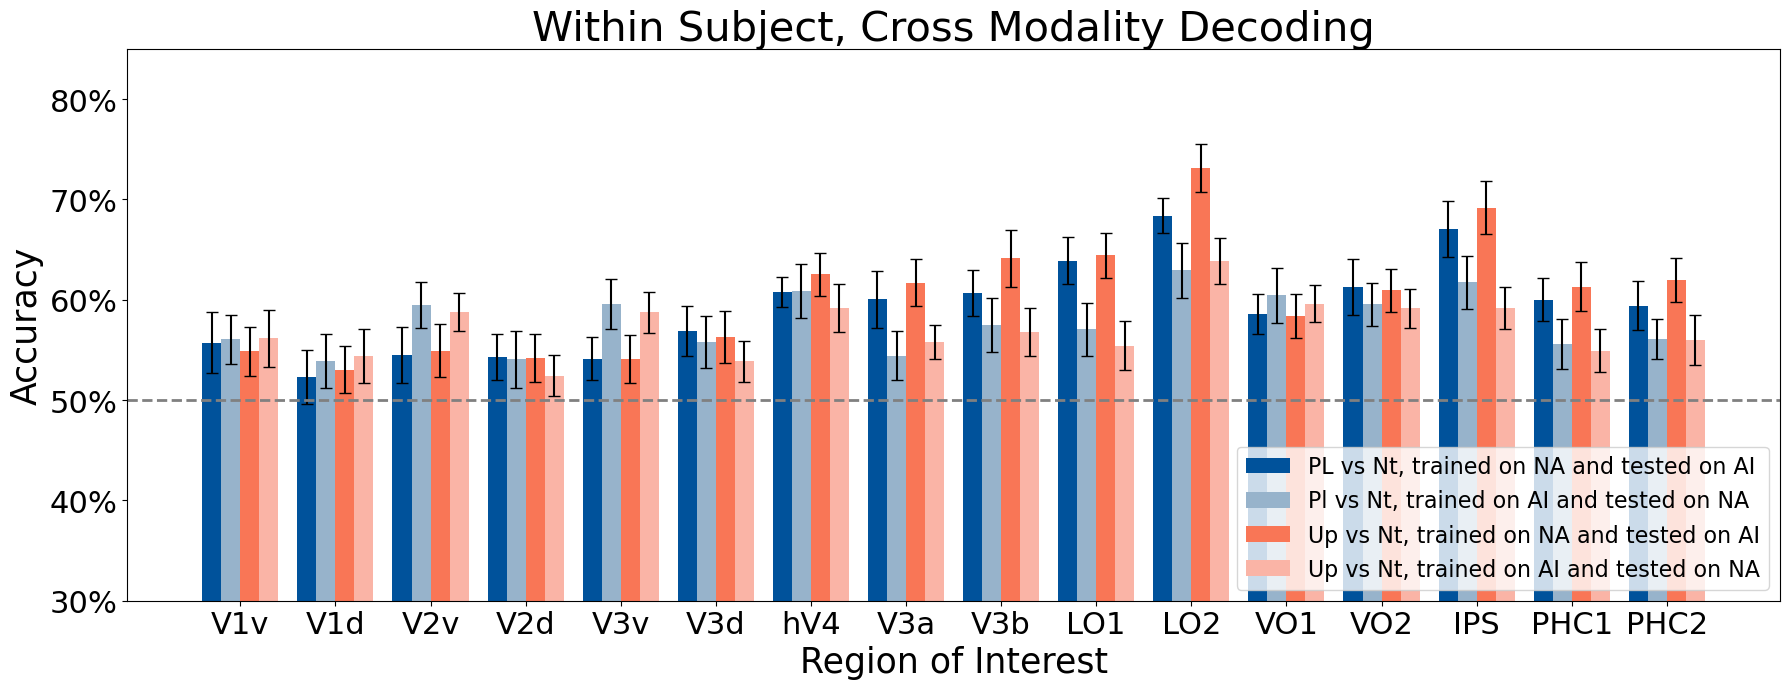

In [50]:
mean_values = np.mean(accuracies_avg_toplot, axis=2)
std_values = np.std(accuracies_avg_toplot, axis=2) / np.sqrt(accuracies_avg_toplot.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

legends = []
legends.append('PL vs Nt, trained on NA and tested on AI')
legends.append('Pl vs Nt, trained on AI and tested on NA')
legends.append('Up vs Nt, trained on NA and tested on AI')
legends.append('Up vs Nt, trained on AI and tested on NA')

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)  # Number of ROIs
rois = roi_masks.keys()
# Plot each comparison's mean values with error bars
for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=legends[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))
    
# Set labels and title
ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)  # Set y-axis range from 0 to 1
ax.set_title('Within Subject, Cross Modality Decoding', fontsize=30)

# Set x-ticks and labels
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)

# Format y-ticks as percentages
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

# Add horizontal line at 0.5 accuracy (chance level)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)

# Add legend
ax.legend(fontsize=16, loc='lower right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

Z scores based

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_18308\3470632186.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


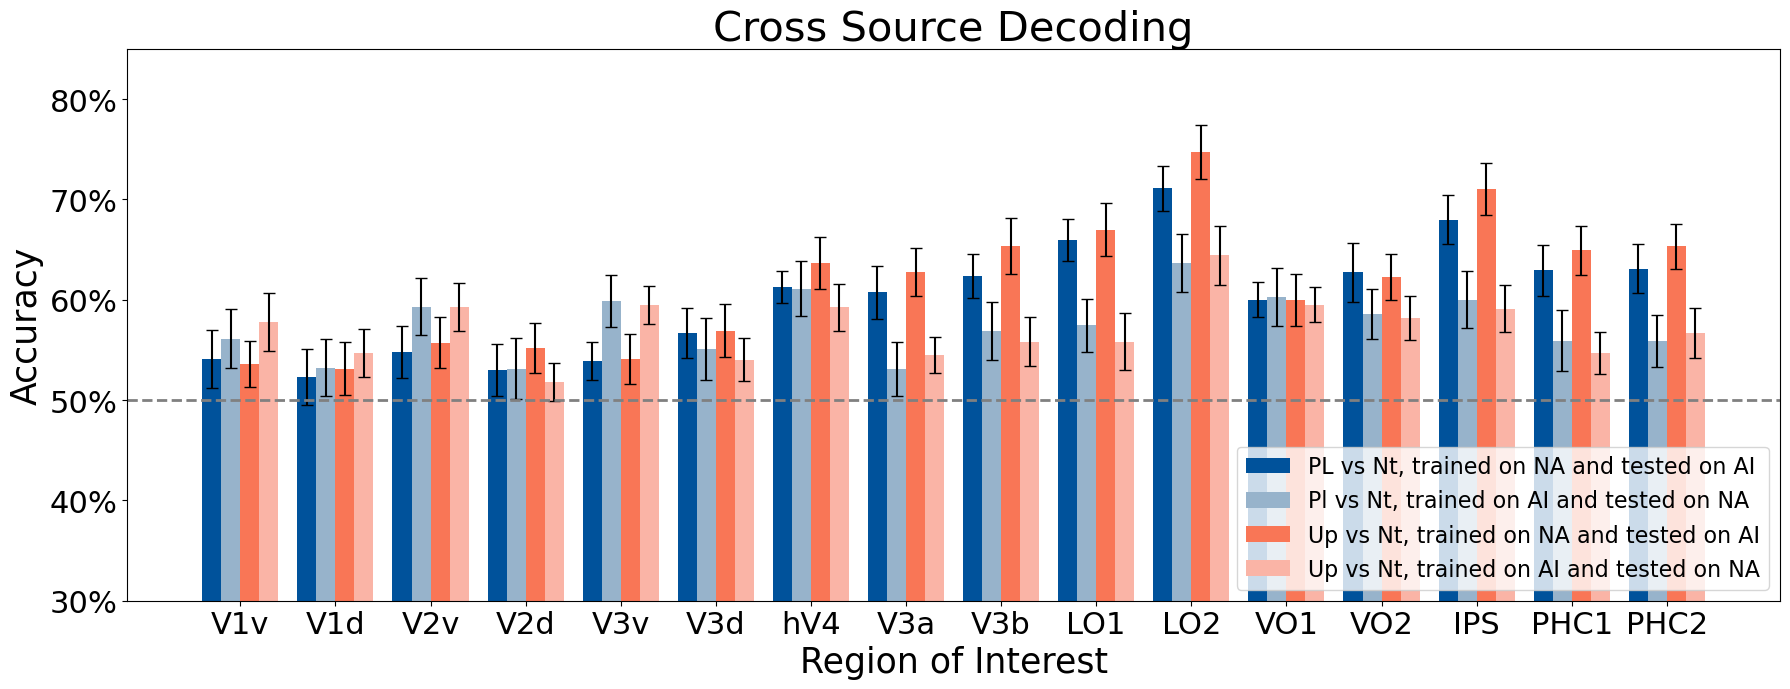

In [29]:
mean_values = np.mean(accuracies_avg_toplot, axis=2)
std_values = np.std(accuracies_avg_toplot, axis=2) / np.sqrt(accuracies_avg_toplot.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

legends = []
legends.append('PL vs Nt, trained on NA and tested on AI')
legends.append('Pl vs Nt, trained on AI and tested on NA')
legends.append('Up vs Nt, trained on NA and tested on AI')
legends.append('Up vs Nt, trained on AI and tested on NA')

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)  # Number of ROIs
rois = roi_masks.keys()
# Plot each comparison's mean values with error bars
for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=legends[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))
    
# Set labels and title
ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)  # Set y-axis range from 0 to 1
ax.set_title('Cross Source Decoding', fontsize=30)

# Set x-ticks and labels
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)

# Format y-ticks as percentages
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

# Add horizontal line at 0.5 accuracy (chance level)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)

# Add legend
ax.legend(fontsize=16, loc='lower right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

9 subs

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_13272\3490784629.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


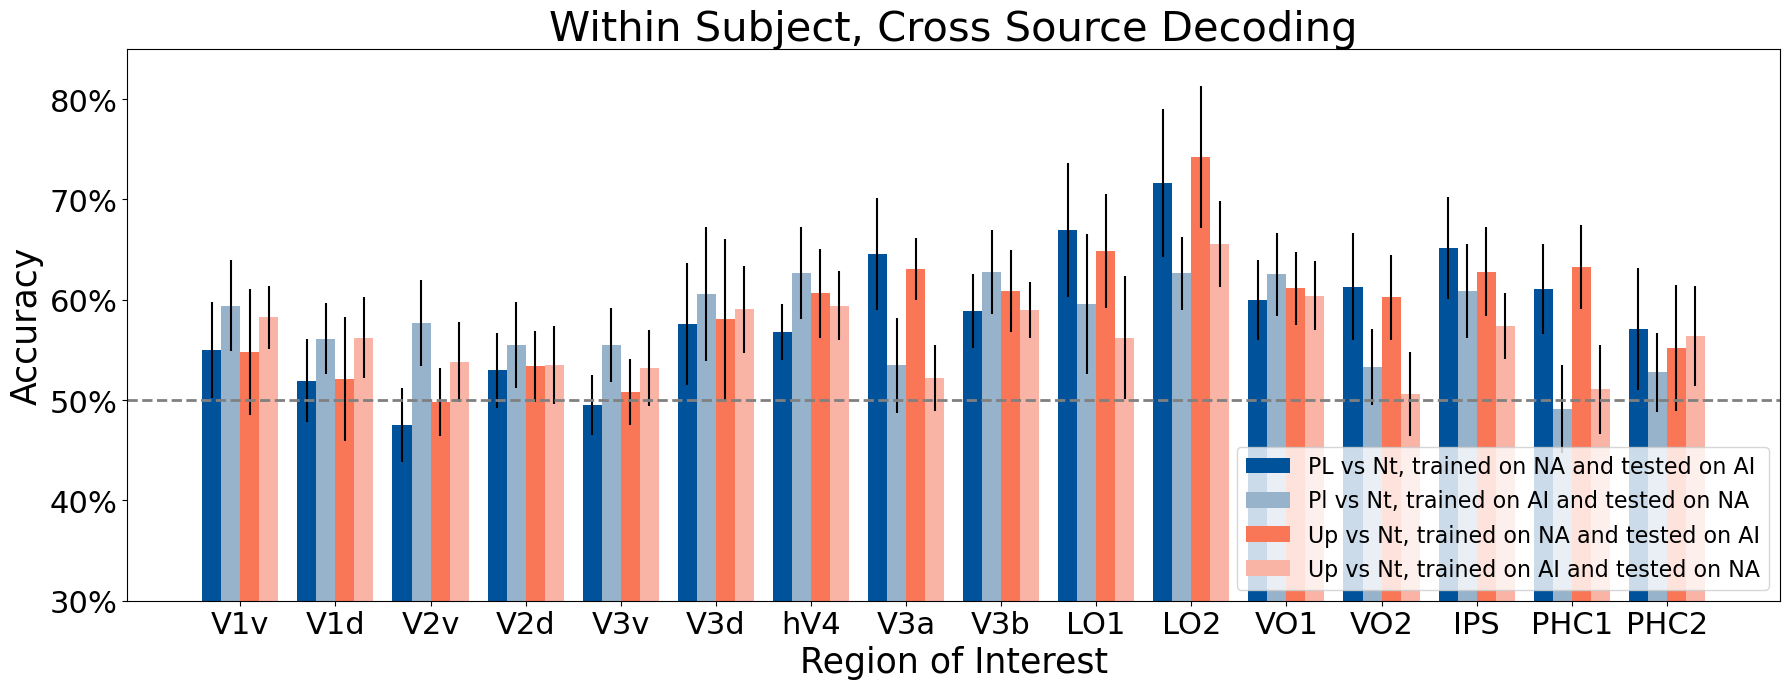

In [140]:
mean_values = np.mean(accuracies_avg_toplot, axis=2)
std_values = np.std(accuracies_avg_toplot, axis=2) / np.sqrt(accuracies_avg_toplot.shape[2])

# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

legends = []
legends.append('PL vs Nt, trained on NA and tested on AI')
legends.append('Pl vs Nt, trained on AI and tested on NA')
legends.append('Up vs Nt, trained on NA and tested on AI')
legends.append('Up vs Nt, trained on AI and tested on NA')

# Create the bar chart with custom colors
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)  # Number of ROIs
rois = roi_masks.keys()
# Plot each comparison's mean values with error bars
for i in range(n_comparisons):
    ax.bar(x + i * bar_width, mean_values[i], yerr=std_values[i], width=bar_width, label=legends[i], color=colors[i])

# Set labels and title
ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)  # Set y-axis range from 0 to 1
ax.set_title('Within Subject, Cross Source Decoding', fontsize=30)

# Set x-ticks and labels
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)

# Format y-ticks as percentages
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

# Add horizontal line at 0.5 accuracy (chance level)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)

# Add legend
ax.legend(fontsize=16, loc='lower right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

# ERP, averaging stimuli

## Within modality

In [46]:
import numpy as np
import pandas as pd

# Inputs:
# stimuli: DataFrame with 600 rows and columns at least ['img', 'group']
# z_flat:  numpy array of shape (30, 600, 592895)
group_order = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# 1) Ensure row order in `stimuli` matches trial order in z_flat's 2nd dim
assert len(stimuli) == z_flat.shape[1], "stimuli rows must match z_flat trials"

# 2) Enforce group order (helps downstream sorting)
stimuli = stimuli.copy()
stimuli['group'] = pd.Categorical(stimuli['group'], categories=group_order, ordered=True)

index_groups = []   # list of np.array trial indices (length 5 each)
labels = []         # list of (group, img)
problems = []

# 3) Build 120 groups of indices: for each group in group_order, collect 20 unique imgs
for g in group_order:
    gdf = stimuli[stimuli['group'] == g]
    # preserve first occurrence order of each img within the group
    img_order = gdf.drop_duplicates(subset='img', keep='first')['img'].tolist()

    if len(img_order) != 20:
        problems.append(f"[{g}] expected 20 unique imgs, found {len(img_order)}")

    for img in img_order:
        idx = gdf.index[gdf['img'] == img].to_numpy()
        if len(idx) != 5:
            problems.append(f"[{g}, {img}] expected 5 repeats, found {len(idx)}")
        index_groups.append(idx)
        labels.append((g, img))

# Sanity checks
if problems:
    raise ValueError("Data integrity issues:\n" + "\n".join(problems))
assert len(index_groups) == 120, f"Expected 120 averaged units, got {len(index_groups)}"

# 4) Average across the 5 repeats for each stimulus (per subject, per voxel)
S, T, V = z_flat.shape
z_flat_avg = np.empty((S, 120, V), dtype=z_flat.dtype)

for j, idx in enumerate(index_groups):
    # z_flat[:, idx, :] -> (S, 5, V); average across those 5 repeats
    z_flat_avg[:, j, :] = np.nanmean(z_flat[:, idx, :], axis=1)

# 5) Also return a metadata frame to map columns back to (group, img) and indices used
avg_meta = pd.DataFrame({
    'out_col': np.arange(120, dtype=int),
    'group': [g for g, _ in labels],
    'img':   [img for _, img in labels],
    'trial_indices': [idx for idx in index_groups],
})

# Optional: keep columns ordered by your group_order (already is), but this is explicit:
avg_meta['group'] = pd.Categorical(avg_meta['group'], categories=group_order, ordered=True)
avg_meta = avg_meta.sort_values(['group', 'out_col']).reset_index(drop=True)

# Results:
# z_flat_avg.shape == (30, 120, 592895)
# avg_meta tells you which (group, img) each of the 120 columns corresponds to
print("z_flat_avg shape:", z_flat_avg.shape)
print(avg_meta.head())


NameError: name 'z_flat' is not defined

In [78]:
import pandas as pd

# Show up to 600 rows and all columns (adjust as needed)
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)  # auto-adjust width for wrapping

print(avg_meta)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

     out_col     group          img            trial_indices       
0        0        pleasant      2550.jpg    [4, 174, 328, 428, 570]
1        1        pleasant      4505.jpg   [18, 185, 272, 398, 529]
2        2        pleasant      2314.jpg   [19, 186, 273, 435, 567]
3        3        pleasant      4597.jpg   [26, 208, 249, 446, 507]
4        4        pleasant      4180.jpg   [30, 157, 268, 454, 542]
5        5        pleasant      4604.jpg   [39, 197, 312, 448, 581]
6        6        pleasant      4601.jpg   [41, 142, 304, 419, 500]
7        7        pleasant      4628.jpg   [43, 126, 252, 401, 519]
8        8        pleasant      2540.jpg   [47, 151, 262, 407, 491]
9        9        pleasant      4150.jpg   [56, 177, 259, 423, 573]
10      10        pleasant      4232.jpg   [61, 202, 336, 400, 505]
11      11        pleasant      2300.jpg   [71, 207, 267, 445, 504]
12      12        pleasant      2045.jpg   [74, 172, 335, 370, 584]
13      13        pleasant      7451.jpg   [93, 

In [48]:
subs =  ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
         'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20',
         'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']

selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub10', 
                 'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18', 'Sub19', 'Sub20', 
                 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30']


# subs =  ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9', 'Sub10', 
#          'Sub11']

# selected_subs = ['Sub1', 'Sub2', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub10', 'Sub11']

# Create a mapping from selected_subs to their corresponding index in subs list
selected_indices = [subs.index(sub) for sub in selected_subs]
len(selected_indices)

28

In [42]:
z_flat_avg = beta_flat_avg  # from previous code snippet
z_flat_avg.shape

(30, 120, 592895)

In [49]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm import tqdm

# Assumptions:
# - z_flat_avg: shape (30, 120, 592895), averaged per-stimulus (20 per group) and sorted by group_order
# - roi_masks: dict of name -> NIfTI image (same voxel space as z_flat_avg's last dim)
# - selected_indices: list of subject indices into the 30 subjects in z_flat_avg
# - comparisons: list of tuples like ('pleasant', 'neutral')
# - group_order as given

# Helper to get the [start, end) column span for a group in z_flat_avg
def span_for_group(group_name, per_group=20):
    gi = group_order.index(group_name)
    start = gi * per_group
    end   = start + per_group
    return start, end

comparisons = [
    ('pleasant', 'neutral'),
    ('pleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI')
]

# Params
n_repeats = 20
n_folds = 4

n_comparisons = len(comparisons)
n_rois        = len(roi_masks)
n_subjects    = len(selected_indices)

# progress = comps × rois × subs × repeats × folds
total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds

accuracy_results = {}

with tqdm(total=total_iterations, desc="Decoding Progress") as pbar:
    for condition1, condition2 in comparisons:
        accuracy_rois = []

        # Precompute column spans (20 averaged items per group)
        c1_start, c1_end = span_for_group(condition1, per_group=20)
        c2_start, c2_end = span_for_group(condition2, per_group=20)

        for roi_name, roi_mask in roi_masks.items():
            # ROI voxel indices
            flat_roi = roi_mask.get_fdata().flatten()
            roi_idx = np.where(flat_roi)[0]

            # Collect per-subject accuracies
            accuracy_subs = []

            for subj in selected_indices:
                # Take averaged data, then ROI slice
                # z_flat_avg[subj] -> (120, V); select ROI voxels -> (120, V_roi)
                subj_avg_roi = z_flat_avg[subj][:, roi_idx]  # (120, V_roi)

                # Pull the 20 averaged samples per condition
                c1 = subj_avg_roi[c1_start:c1_end, :]  # (20, V_roi)
                c2 = subj_avg_roi[c2_start:c2_end, :]  # (20, V_roi)

                # Remove NaN voxels consistently across both classes
                # (keep voxels that are finite for all 40 averaged samples)
                both = np.vstack([c1, c2])  # (40, V_roi)
                good_vox = np.all(np.isfinite(both), axis=0)
                c1 = c1[:, good_vox]
                c2 = c2[:, good_vox]

                # Optional sanity check (like your 80% threshold)
                assert good_vox.sum() >= 0.8 * len(roi_idx), \
                    f"[{roi_name}] Kept voxels {good_vox.sum()} < 80% of ROI ({len(roi_idx)})"

                # 4-fold CV on the 20 items per class; same split for both classes
                indices20 = np.arange(20)
                accs = []

                for repeat in range(n_repeats):
                    kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                    for tr_idx, te_idx in kf.split(indices20):
                        # Train on selected stimulus means from each class
                        Xtr = np.vstack([c1[tr_idx], c2[tr_idx]])  # (2*len(tr_idx), V_roi_kept)
                        ytr = np.r_[np.ones(len(tr_idx)), np.zeros(len(tr_idx))]

                        # Test on held-out stimulus means (per class)
                        Xte = np.vstack([c1[te_idx], c2[te_idx]])
                        yte = np.r_[np.ones(len(te_idx)), np.zeros(len(te_idx))]

                        clf = SVC(kernel='linear')
                        clf.fit(Xtr, ytr)
                        accs.append(clf.score(Xte, yte))

                        pbar.update(1)

                accuracy_subs.append(np.mean(accs))

            accuracy_rois.append(np.array(accuracy_subs))

        accuracy_results[f"{condition1}_vs_{condition2}"] = np.array(accuracy_rois)

# accuracy_results[comp] -> array shape (n_rois, n_subjects) of mean accuracy per subject


Decoding Progress: 100%|██████████| 143360/143360 [02:21<00:00, 1015.59it/s]


In [55]:
# Check the shape
print(f"z_flat_avg shape: {z_flat_avg.shape}")  # Should be (30, 120, num_voxels)

# Verify that stimuli are grouped correctly
# For example, if pleasant is first, check if those 20 stimuli make sense
test_subj = 0
pleasant_data = z_flat_avg[test_subj, 0:20, :]
print(f"Pleasant stimuli data shape: {pleasant_data.shape}")

z_flat_avg shape: (30, 120, 592895)
Pleasant stimuli data shape: (20, 592895)


In [56]:
# Check how z-scoring was done. Common mistakes:
# BAD: z-scoring across all conditions together (removes differences)
# GOOD: z-scoring within runs or sessions, before averaging

# Verify there are differences between conditions:
c1_data = z_flat_avg[0, 0:20, :].mean(axis=0)
c2_data = z_flat_avg[0, 20:40, :].mean(axis=0)
print(f"Mean difference between conditions: {np.mean(np.abs(c1_data - c2_data))}")
print(f"Any differences > 0.1? {np.any(np.abs(c1_data - c2_data) > 0.1)}")

Mean difference between conditions: nan
Any differences > 0.1? True


In [57]:
# Check how many NaN values are in your data
print(f"Total NaN values in z_flat_avg: {np.isnan(z_flat_avg).sum()}")
print(f"Percentage of NaN: {np.isnan(z_flat_avg).sum() / z_flat_avg.size * 100:.2f}%")

# Check NaN distribution across subjects
for i in range(len(selected_indices)):
    subj_idx = selected_indices[i]
    nan_count = np.isnan(z_flat_avg[subj_idx]).sum()
    print(f"Subject {selected_subs[i]}: {nan_count} NaN values")

# Check NaN distribution across voxels
nan_per_voxel = np.isnan(z_flat_avg).sum(axis=(0, 1))  # Sum across subjects and stimuli
print(f"Voxels with all NaN: {(nan_per_voxel == 30*120).sum()}")
print(f"Voxels with some NaN: {(nan_per_voxel > 0).sum()}")
print(f"Voxels with no NaN: {(nan_per_voxel == 0).sum()}")

Total NaN values in z_flat_avg: 1312113600
Percentage of NaN: 61.47%
Subject Sub1: 43737120 NaN values
Subject Sub2: 43737120 NaN values
Subject Sub4: 43737120 NaN values
Subject Sub5: 43737120 NaN values
Subject Sub6: 43737120 NaN values
Subject Sub7: 43737120 NaN values
Subject Sub9: 43737120 NaN values
Subject Sub10: 43737120 NaN values
Subject Sub11: 43737120 NaN values
Subject Sub12: 43737120 NaN values
Subject Sub13: 43737120 NaN values
Subject Sub14: 43737120 NaN values
Subject Sub15: 43737120 NaN values
Subject Sub16: 43737120 NaN values
Subject Sub17: 43737120 NaN values
Subject Sub18: 43737120 NaN values
Subject Sub19: 43737120 NaN values
Subject Sub20: 43737120 NaN values
Subject Sub21: 43737120 NaN values
Subject Sub22: 43737120 NaN values
Subject Sub23: 43737120 NaN values
Subject Sub24: 43737120 NaN values
Subject Sub25: 43737120 NaN values
Subject Sub26: 43737120 NaN values
Subject Sub27: 43737120 NaN values
Subject Sub28: 43737120 NaN values
Subject Sub29: 43737120 NaN 

In [58]:
comparisons_order = accuracy_results.keys()

# Initialize an array to store accuracies for each comparison, ROI, and subject
n_comparisons = len(comparisons_order)
n_rois = 16  # 16 ROIs
n_subjects = 28 # 10 subjects

# Create a 3D array to hold the accuracy data: (comparisons, ROIs, subjects)
accuracies_avg = np.zeros((n_comparisons, n_rois, n_subjects))

# Fill in the accuracies_avg array with data from accuracy_results
for comp_idx, comparison in enumerate(comparisons_order):
    accuracies_avg[comp_idx, :, :] = accuracy_results[comparison]

# accuracies_avg_toplot = np.delete(accuracies_avg, 2, axis=2)
accuracies_avg_toplot = accuracies_avg
accuracies_avg_toplot.shape


(4, 16, 28)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_10932\1813329534.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)


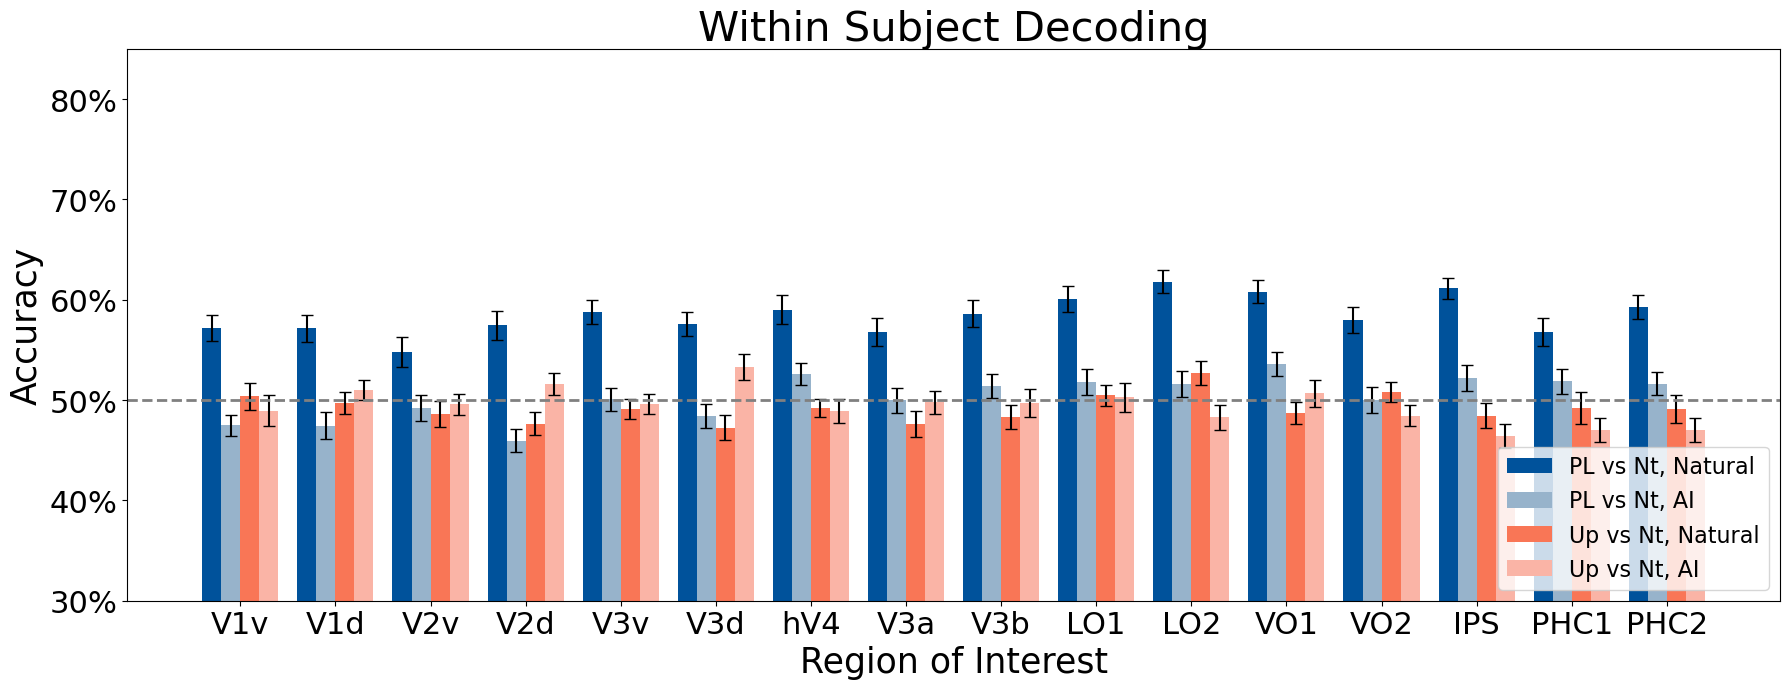

In [74]:
# Compute mean and SEM (subject-wise)
mean_values = np.mean(accuracies_avg_toplot, axis=2)                 # mean across subjects
sem_values  = np.std(accuracies_avg_toplot, axis=2, ddof=1) / np.sqrt(accuracies_avg_toplot.shape[2])  # SEM across subjects

# Plot with SEM error bars
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)
rois = list(roi_masks.keys())

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=legends[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Subject Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')

# percentage labels for y-axis
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()


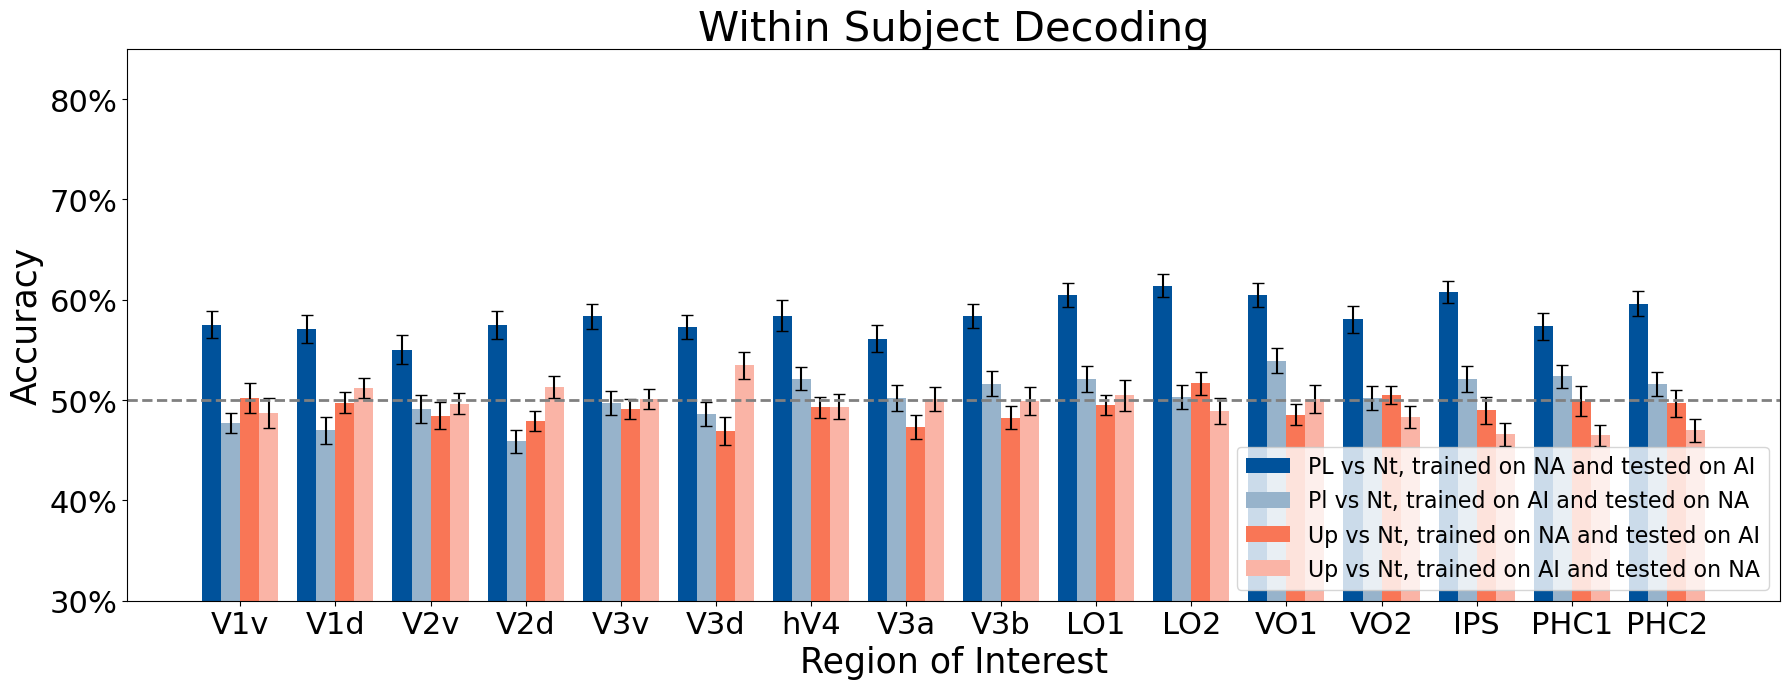

In [59]:
# Compute mean and SEM (subject-wise)
mean_values = np.mean(accuracies_avg_toplot, axis=2)                 # mean across subjects
sem_values  = np.std(accuracies_avg_toplot, axis=2, ddof=1) / np.sqrt(accuracies_avg_toplot.shape[2])  # SEM across subjects

# Plot with SEM error bars
fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.2
x = np.arange(n_rois)
rois = list(roi_masks.keys())

legends = []
legends.append('PL vs Nt, trained on NA and tested on AI')
legends.append('Pl vs Nt, trained on AI and tested on NA')
legends.append('Up vs Nt, trained on NA and tested on AI')
legends.append('Up vs Nt, trained on AI and tested on NA')
# Define custom colors for each dataset
colors = [(0/255, 82/255, 155/255),  # RGB values for the first color
          (151/255, 179/255, 203/255),  # RGB values for the second color
          (249/255, 118/255, 86/255),   # RGB values for the third color
          (250/255,180/255, 166/255)]  # RGB values for the fourth color

for i in range(n_comparisons):
    ax.bar(x + i * bar_width,
           mean_values[i],
           yerr=sem_values[i],
           width=bar_width,
           label=legends[i],
           color=colors[i],
           capsize=4,
           error_kw=dict(linewidth=1.5))

ax.set_xlabel('Region of Interest', fontsize=25)
ax.set_ylabel('Accuracy', fontsize=25)
ax.set_ylim(0.3, 0.85)
ax.set_title('Within Subject Decoding', fontsize=30)
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(rois, fontsize=22)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2)
ax.legend(fontsize=16, loc='lower right')

# percentage labels for y-axis
ax.set_yticklabels(['{:,.0%}'.format(y) for y in ax.get_yticks()], fontsize=20)
ax.tick_params(axis='y', labelsize=22)

plt.tight_layout()
plt.show()


In [86]:
beta_all.shape

(30, 600, 79, 95, 79)

In [8]:
beta_flat = beta_all.reshape(beta_all.shape[0],beta_all.shape[1],-1)

In [88]:
beta_flat.shape

(30, 600, 592895)

In [100]:
# del beta_all
del beta_flat

In [99]:
z_flat = beta_flat.copy()

In [101]:
import numpy as np
import pandas as pd

# Inputs:
# stimuli: DataFrame with 600 rows and columns at least ['img', 'group']
# z_flat:  numpy array of shape (30, 600, 592895)
group_order = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# 1) Ensure row order in `stimuli` matches trial order in z_flat's 2nd dim
assert len(stimuli) == z_flat.shape[1], "stimuli rows must match z_flat trials"

# 2) Enforce group order (helps downstream sorting)
stimuli = stimuli.copy()
stimuli['group'] = pd.Categorical(stimuli['group'], categories=group_order, ordered=True)

index_groups = []   # list of np.array trial indices (length 5 each)
labels = []         # list of (group, img)
problems = []

# 3) Build 120 groups of indices: for each group in group_order, collect 20 unique imgs
for g in group_order:
    gdf = stimuli[stimuli['group'] == g]
    # preserve first occurrence order of each img within the group
    img_order = gdf.drop_duplicates(subset='img', keep='first')['img'].tolist()

    if len(img_order) != 20:
        problems.append(f"[{g}] expected 20 unique imgs, found {len(img_order)}")

    for img in img_order:
        idx = gdf.index[gdf['img'] == img].to_numpy()
        if len(idx) != 5:
            problems.append(f"[{g}, {img}] expected 5 repeats, found {len(idx)}")
        index_groups.append(idx)
        labels.append((g, img))

# Sanity checks
if problems:
    raise ValueError("Data integrity issues:\n" + "\n".join(problems))
assert len(index_groups) == 120, f"Expected 120 averaged units, got {len(index_groups)}"

# 4) Average across the 5 repeats for each stimulus (per subject, per voxel)
S, T, V = z_flat.shape
z_flat_avg = np.empty((S, 120, V), dtype=z_flat.dtype)

for j, idx in enumerate(index_groups):
    # z_flat[:, idx, :] -> (S, 5, V); average across those 5 repeats
    z_flat_avg[:, j, :] = np.nanmean(z_flat[:, idx, :], axis=1)

# 5) Also return a metadata frame to map columns back to (group, img) and indices used
avg_meta = pd.DataFrame({
    'out_col': np.arange(120, dtype=int),
    'group': [g for g, _ in labels],
    'img':   [img for _, img in labels],
    'trial_indices': [idx for idx in index_groups],
})

# Optional: keep columns ordered by your group_order (already is), but this is explicit:
avg_meta['group'] = pd.Categorical(avg_meta['group'], categories=group_order, ordered=True)
avg_meta = avg_meta.sort_values(['group', 'out_col']).reset_index(drop=True)

# Results:
# z_flat_avg.shape == (30, 120, 592895)
# avg_meta tells you which (group, img) each of the 120 columns corresponds to
print("z_flat_avg shape:", z_flat_avg.shape)
print(avg_meta.head())


z_flat_avg shape: (30, 120, 592895)
   out_col   group      img          trial_indices      
0     0     pleasant  2550.jpg   [4, 174, 328, 428, 570]
1     1     pleasant  4505.jpg  [18, 185, 272, 398, 529]
2     2     pleasant  2314.jpg  [19, 186, 273, 435, 567]
3     3     pleasant  4597.jpg  [26, 208, 249, 446, 507]
4     4     pleasant  4180.jpg  [30, 157, 268, 454, 542]


In [102]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm import tqdm
import warnings

# Helper to get the [start, end) column span for a group in z_flat_avg
def span_for_group(group_name, per_group=20):
    gi = group_order.index(group_name)
    start = gi * per_group
    end = start + per_group
    return start, end

comparisons = [
    ('pleasant', 'neutral'),
    ('pleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI')
]

# Params
n_repeats = 20
n_folds = 4
min_voxel_threshold = 0.5  # Minimum proportion of ROI voxels required (adjustable)
min_voxels_absolute = 10   # Minimum absolute number of voxels required for decoding

n_comparisons = len(comparisons)
n_rois = len(roi_masks)
n_subjects = len(selected_indices)

# Track statistics
decoding_stats = {}
skipped_analyses = []

# Calculate total iterations (accounting for potential skips)
total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds

accuracy_results = {}
voxel_counts = {}  # Store how many voxels were used for each analysis

with tqdm(total=total_iterations, desc="Decoding Progress") as pbar:
    for condition1, condition2 in comparisons:
        comparison_name = f"{condition1}_vs_{condition2}"
        accuracy_rois = []
        voxel_count_rois = []
        
        # Precompute column spans (20 averaged items per group)
        c1_start, c1_end = span_for_group(condition1, per_group=20)
        c2_start, c2_end = span_for_group(condition2, per_group=20)
        
        for roi_name, roi_mask in roi_masks.items():
            # ROI voxel indices
            flat_roi = roi_mask.get_fdata().flatten()
            roi_idx = np.where(flat_roi)[0]
            total_roi_voxels = len(roi_idx)
            
            # Collect per-subject accuracies
            accuracy_subs = []
            voxel_count_subs = []
            
            for subj_idx, subj in enumerate(selected_indices):
                # Take averaged data, then ROI slice
                subj_avg_roi = z_flat_avg[subj][:, roi_idx]  # (120, V_roi)
                
                # Pull the 20 averaged samples per condition
                c1 = subj_avg_roi[c1_start:c1_end, :]  # (20, V_roi)
                c2 = subj_avg_roi[c2_start:c2_end, :]  # (20, V_roi)
                
                # Remove NaN voxels consistently across both classes
                # (keep voxels that are finite for all 40 averaged samples)
                both = np.vstack([c1, c2])  # (40, V_roi)
                good_vox = np.all(np.isfinite(both), axis=0)
                n_good_voxels = good_vox.sum()
                voxel_proportion = n_good_voxels / total_roi_voxels
                
                # Check if we have enough valid voxels
                if n_good_voxels < min_voxels_absolute:
                    warning_msg = (f"[{comparison_name}][{roi_name}][Subj {selected_subs[subj_idx]}] "
                                 f"Only {n_good_voxels} valid voxels (< {min_voxels_absolute} minimum). Skipping.")
                    warnings.warn(warning_msg)
                    skipped_analyses.append({
                        'comparison': comparison_name,
                        'roi': roi_name,
                        'subject': selected_subs[subj_idx],
                        'reason': f'Too few valid voxels ({n_good_voxels})',
                        'voxel_proportion': voxel_proportion
                    })
                    accuracy_subs.append(np.nan)
                    voxel_count_subs.append(n_good_voxels)
                    
                    # Update progress bar for skipped iterations
                    pbar.update(n_repeats * n_folds)
                    continue
                
                if voxel_proportion < min_voxel_threshold:
                    warning_msg = (f"[{comparison_name}][{roi_name}][Subj {selected_subs[subj_idx]}] "
                                 f"Only {voxel_proportion:.1%} of ROI voxels are valid "
                                 f"({n_good_voxels}/{total_roi_voxels}). Proceeding with caution.")
                    warnings.warn(warning_msg)
                
                # Store voxel count
                voxel_count_subs.append(n_good_voxels)
                
                # Use only valid voxels
                c1 = c1[:, good_vox]
                c2 = c2[:, good_vox]
                
                # Additional check: ensure there's variance in the data
                if c1.var() == 0 or c2.var() == 0:
                    warning_msg = (f"[{comparison_name}][{roi_name}][Subj {selected_subs[subj_idx]}] "
                                 f"No variance in data. Skipping.")
                    warnings.warn(warning_msg)
                    accuracy_subs.append(np.nan)
                    pbar.update(n_repeats * n_folds)
                    continue
                
                # 4-fold CV on the 20 items per class
                indices20 = np.arange(20)
                accs = []
                
                for repeat in range(n_repeats):
                    kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                    for tr_idx, te_idx in kf.split(indices20):
                        try:
                            # Train on selected stimulus means from each class
                            Xtr = np.vstack([c1[tr_idx], c2[tr_idx]])
                            ytr = np.r_[np.ones(len(tr_idx)), np.zeros(len(tr_idx))]
                            
                            # Test on held-out stimulus means
                            Xte = np.vstack([c1[te_idx], c2[te_idx]])
                            yte = np.r_[np.ones(len(te_idx)), np.zeros(len(te_idx))]
                            
                            # Check for any remaining NaNs (shouldn't happen, but safety check)
                            if np.any(np.isnan(Xtr)) or np.any(np.isnan(Xte)):
                                raise ValueError("NaN values found in training/test data after filtering")
                            
                            clf = SVC(kernel='linear', C=1.0)
                            clf.fit(Xtr, ytr)
                            acc = clf.score(Xte, yte)
                            accs.append(acc)
                            
                        except Exception as e:
                            warning_msg = (f"[{comparison_name}][{roi_name}][Subj {selected_subs[subj_idx]}] "
                                         f"Error during SVM: {str(e)}. Using chance accuracy.")
                            warnings.warn(warning_msg)
                            accs.append(0.5)  # Chance level
                        
                        pbar.update(1)
                
                if len(accs) > 0:
                    accuracy_subs.append(np.mean(accs))
                else:
                    accuracy_subs.append(np.nan)
            
            accuracy_rois.append(np.array(accuracy_subs))
            voxel_count_rois.append(np.array(voxel_count_subs))
        
        accuracy_results[comparison_name] = np.array(accuracy_rois)
        voxel_counts[comparison_name] = np.array(voxel_count_rois)

# Create summary statistics
print("\n" + "="*80)
print("DECODING SUMMARY")
print("="*80)

for comparison in accuracy_results:
    print(f"\n{comparison}:")
    acc_array = accuracy_results[comparison]
    vox_array = voxel_counts[comparison]
    
    for roi_idx, roi_name in enumerate(roi_masks.keys()):
        roi_accs = acc_array[roi_idx]
        roi_voxels = vox_array[roi_idx]
        
        # Calculate statistics excluding NaN values
        valid_accs = roi_accs[~np.isnan(roi_accs)]
        n_valid = len(valid_accs)
        n_total = len(roi_accs)
        
        if n_valid > 0:
            mean_acc = np.mean(valid_accs)
            std_acc = np.std(valid_accs)
            mean_voxels = np.nanmean(roi_voxels)
            
            print(f"  {roi_name}: "
                  f"Acc={mean_acc:.3f}±{std_acc:.3f}, "
                  f"Valid subjects={n_valid}/{n_total}, "
                  f"Avg voxels={mean_voxels:.0f}")
        else:
            print(f"  {roi_name}: No valid subjects")

# Report skipped analyses
if skipped_analyses:
    print(f"\n⚠️  {len(skipped_analyses)} analyses were skipped due to insufficient data")
    print("Details saved in 'skipped_analyses' variable")

# Optional: Save detailed results
results_summary = {
    'accuracy': accuracy_results,
    'voxel_counts': voxel_counts,
    'skipped': skipped_analyses,
    'parameters': {
        'n_repeats': n_repeats,
        'n_folds': n_folds,
        'min_voxel_threshold': min_voxel_threshold,
        'min_voxels_absolute': min_voxels_absolute
    }
}

print(f"\n✓ Decoding complete. Results stored in 'accuracy_results' and 'results_summary'")

Decoding Progress: 100%|██████████| 143360/143360 [02:22<00:00, 1008.95it/s]


DECODING SUMMARY

pleasant_vs_neutral:
  V1v: Acc=0.575±0.069, Valid subjects=28/28, Avg voxels=842
  V1d: Acc=0.571±0.074, Valid subjects=28/28, Avg voxels=738
  V2v: Acc=0.550±0.076, Valid subjects=28/28, Avg voxels=721
  V2d: Acc=0.575±0.071, Valid subjects=28/28, Avg voxels=644
  V3v: Acc=0.583±0.067, Valid subjects=28/28, Avg voxels=527
  V3d: Acc=0.573±0.063, Valid subjects=28/28, Avg voxels=517
  hV4: Acc=0.584±0.082, Valid subjects=28/28, Avg voxels=328
  V3a: Acc=0.561±0.068, Valid subjects=28/28, Avg voxels=554
  V3b: Acc=0.584±0.062, Valid subjects=28/28, Avg voxels=263
  LO1: Acc=0.605±0.063, Valid subjects=28/28, Avg voxels=324
  LO2: Acc=0.614±0.060, Valid subjects=28/28, Avg voxels=125
  VO1: Acc=0.605±0.062, Valid subjects=28/28, Avg voxels=153
  VO2: Acc=0.581±0.070, Valid subjects=28/28, Avg voxels=253
  IPS: Acc=0.608±0.057, Valid subjects=28/28, Avg voxels=973
  PHC1: Acc=0.573±0.069, Valid subjects=28/28, Avg voxels=175
  PHC2: Acc=0.596±0.064, Valid subjects=28/2

testing

### Load data and stimuli

In [4]:
import numpy as np
import os

# Directory and file paths
data_dir = r"N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\30subs"
beta_file = os.path.join(data_dir, "beta_all.npy")
# z_file    = os.path.join(data_dir, "z_all.npy")

# Load back the arrays
beta_all  = np.load(beta_file)
# z_all     = np.load(z_file)



In [5]:
print("Loaded beta_all shape:", beta_all.shape)
# print("Loaded z_all shape:", z_all.shape)


Loaded beta_all shape: (30, 600, 79, 95, 79)


In [6]:
stimuli = pd.read_csv("./stimuli_600trials.csv")
stimuli

,run,OriginalOrder,img,emotion_type,AI,group
0,1,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,1,2,5395_2.jpg,neutral,YES,neutralAI
3,1,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,1,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,10,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,10,596,9140.jpg,unpleasant,NO,unpleasant
597,10,597,2446.jpg,neutral,NO,neutral
598,10,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [7]:
beta_flat = beta_all.reshape(beta_all.shape[0],beta_all.shape[1],-1)
beta_flat.shape

(30, 600, 592895)

In [31]:

# Define the groups
groups = ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# Split the data into smaller batches
batch_size = 100
num_batches = int(np.ceil(beta_flat.shape[0] / batch_size))

reordered_measures_list = []
indices_list = []
# Process data in batches
for batch_index in range(num_batches):
    start_index = batch_index * batch_size
    end_index = min((batch_index + 1) * batch_size, beta_flat.shape[0])

    batch_measures = beta_flat[start_index:end_index]

    batch_reordered_measures = []
    index_list = []
    # Process each measure in the batch
    for i in range(batch_measures.shape[0]):
        measure = batch_measures[i]
        reordered_measure = np.empty_like(measure)  # Create an empty array of the same shape
        reordered_index = 0
        
        # Process each group
        for group in groups:
            indices = stimuli.index[stimuli['group'] == group].tolist()
            for idx in indices:
                reordered_measure[reordered_index] = measure[idx]
                reordered_index += 1
            index_list.append(indices)
        batch_reordered_measures.append(reordered_measure)
        indices_list.append(np.array(index_list))
    reordered_measures_list.extend(batch_reordered_measures)

# Concatenate the reordered measures
beta_flat_sorted = np.array(reordered_measures_list)
# reordered_single_trial_z = np.array(reordered_measures_list)


### z-scoring and averaging

In [ ]:
import numpy as np
import pandas as pd
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm import tqdm
import nibabel as nib  # only if your roi_masks are NiBabel images

# -----------------------------------------------------------------------------
# INPUTS you already have:
#   beta_all:  np.ndarray shape (30, 600, 79, 95, 79)
#   stimuli:   DataFrame (600 rows) with columns at least ['img','group']
#   roi_masks: dict[str -> nib.Nifti1Image]  (same 79x95x79 grid)
#   selected_indices: list/array of subject indices to include (e.g., np.arange(30))
#   selected_subs:    subject labels for printing (len matches selected_indices)
# -----------------------------------------------------------------------------

S, T, X, Y, Z = beta_all.shape
V = X * Y * Z

# --------- 0) Flatten + basic voxel screen (drop dead voxels to save RAM) ----------
betas = beta_all.reshape(S, T, V).astype(np.float32)

# voxels that are all NaN across everything or constant (std==0) across all subjects & trials
voxel_is_nan = ~np.isfinite(betas).any(axis=(0,1))
voxel_std_all = np.nanstd(betas, axis=(0,1))
voxel_is_const = (voxel_std_all == 0) | ~np.isfinite(voxel_std_all)

good_vox = ~(voxel_is_nan | voxel_is_const)
if good_vox.sum() < V:
    print(f"Keeping {good_vox.sum():,} / {V:,} voxels after basic screening.")
betas = betas[:, :, good_vox]   # shape (S, T, Vgood)
Vgood = betas.shape[-1]

# --------- 1) Run-wise z-scoring per subject, per voxel (unsupervised, removes run drift) ----------
# We assume 10 runs × 60 trials each, in-order. If you have a 'run' column in stimuli,
# you can use its indices instead of the simple slices below.
RUNS = 10
TRIALS_PER_RUN = T // RUNS
assert T == RUNS * TRIALS_PER_RUN, "600 trials must be divisible into equal run blocks."

betas_z = np.empty_like(betas, dtype=np.float32)

for s in range(S):
    for r in range(RUNS):
        lo = r * TRIALS_PER_RUN
        hi = (r+1) * TRIALS_PER_RUN
        X_sr = betas[s, lo:hi, :]           # (60, Vgood)
        mu = np.nanmean(X_sr, axis=0, keepdims=True)
        sd = np.nanstd(X_sr, axis=0, keepdims=True)
        sd[sd == 0] = 1.0                   # avoid /0; constant → 0 after standardization
        betas_z[s, lo:hi, :] = (X_sr - mu) / sd

del betas  # free memory

# --------- 2) Build 120 averaged items (5 repeats per unique image) -----------------
group_order = ['pleasant', 'neutral', 'unpleasant',
               'pleasantAI', 'neutralAI', 'unpleasantAI']

assert len(stimuli) == T, "stimuli rows must match 600 trials."
stimuli = stimuli.copy()
stimuli['group'] = pd.Categorical(stimuli['group'], categories=group_order, ordered=True)

index_groups = []  # list of np.array of 5 trial indices per (group,img)
labels       = []  # parallel list of (group, img)
problems     = []

for g in group_order:
    gdf = stimuli[stimuli['group'] == g]
    img_order = gdf.drop_duplicates(subset='img', keep='first')['img'].tolist()
    if len(img_order) != 20:
        problems.append(f"[{g}] expected 20 unique imgs, found {len(img_order)}")
    for img in img_order:
        idx = gdf.index[gdf['img'] == img].to_numpy()
        if len(idx) != 5:
            problems.append(f"[{g}, {img}] expected 5 repeats, found {len(idx)}")
        index_groups.append(idx)
        labels.append((g, img))

if problems:
    raise ValueError("Data integrity issues:\n" + "\n".join(problems))
assert len(index_groups) == 120, f"Expected 120 averaged units, got {len(index_groups)}"

# Average across 5 repeats (per subject, per voxel)
z_flat_avg = np.empty((S, 120, Vgood), dtype=np.float32)
for j, idx in enumerate(index_groups):
    z_flat_avg[:, j, :] = np.nanmean(betas_z[:, idx, :], axis=1)

avg_meta = pd.DataFrame({
    'out_col': np.arange(120, dtype=int),
    'group'  : [g for g, _ in labels],
    'img'    : [i for _, i in labels],
    'trial_indices': [idx for idx in index_groups],
})
avg_meta['group'] = pd.Categorical(avg_meta['group'], categories=group_order, ordered=True)
avg_meta = avg_meta.sort_values(['group','out_col']).reset_index(drop=True)

print("Averaged matrix:", z_flat_avg.shape)  # (S, 120, Vgood)



Keeping 227,101 / 592,895 voxels after basic screening.
Averaged matrix: (30, 120, 227101)


NameError: name 'selected_indices' is not defined

In [15]:
betas_z.shape

(30, 600, 227101)

In [12]:
z_flat_avg.shape

(30, 120, 227101)

In [14]:
# Replace your averaging section with this:
print("\n=== Creating Averaged Data ===")
z_flat_avg = np.empty((S, 120, Vgood), dtype=np.float32)

nan_counts_before = []
nan_counts_after = []

for j, idx in enumerate(index_groups):
    # Check for NaNs before averaging
    data_to_avg = betas_z[:, idx, :]  # (S, 5, Vgood)
    nans_before = np.isnan(data_to_avg).sum()
    nan_counts_before.append(nans_before)
    
    # Use nanmean to handle NaNs gracefully
    z_flat_avg[:, j, :] = np.nanmean(data_to_avg, axis=1)
    
    # Check NaNs after averaging
    nans_after = np.isnan(z_flat_avg[:, j, :]).sum()
    nan_counts_after.append(nans_after)
    
    # Warning if averaging created more NaNs
    if nans_after > nans_before / 5:
        print(f"  Item {j}: NaNs increased from {nans_before} to {nans_after}")

print(f"Total NaNs before averaging: {sum(nan_counts_before)}")
print(f"Total NaNs after averaging: {sum(nan_counts_after)}")
print(f"Items with any NaN: {sum(n > 0 for n in nan_counts_after)}/120")


=== Creating Averaged Data ===
Total NaNs before averaging: 0
Total NaNs after averaging: 0
Items with any NaN: 0/120


In [32]:

# --------- 3) Helper to slice the 20 items per group in the averaged matrix ----------
def span_for_group(group_name, per_group=20):
    gi = group_order.index(group_name)
    return gi * per_group, (gi+1) * per_group

# --------- 4) Decode with leak-free scaling inside each CV split ---------------------
comparisons = [
    ('pleasant',      'neutral'),
    ('pleasantAI',    'neutralAI'),
    ('unpleasant',    'neutral'),
    ('unpleasantAI',  'neutralAI'),
]

n_repeats = 20
n_folds   = 5
min_voxel_threshold = 0.5
min_voxels_absolute = 10

n_comparisons = len(comparisons)
n_rois = len(roi_masks)
n_subjects = len(selected_indices)

accuracy_results = {}
voxel_counts = {}
skipped_analyses = []

total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds

with tqdm(total=total_iterations, desc="Decoding Progress") as pbar:
    for (condition1, condition2) in comparisons:
        comparison_name = f"{condition1}_vs_{condition2}"
        roi_acc_list = []
        roi_vox_list = []

        c1_start, c1_end = span_for_group(condition1, per_group=20)
        c2_start, c2_end = span_for_group(condition2, per_group=20)

        for roi_name, roi_img in roi_masks.items():
            flat_roi = roi_img.get_fdata().astype(bool).flatten()[good_vox]  # align to Vgood
            roi_idx = np.where(flat_roi)[0]
            total_roi_voxels = len(roi_idx)

            subj_accs = []
            subj_vox  = []

            for si, subj in enumerate(selected_indices):
                Xs = z_flat_avg[subj][:, roi_idx]  # (120, V_roi_raw)
                # take the 20 items per class (already averaged)
                c1 = Xs[c1_start:c1_end, :]  # (20, V_roi_raw)
                c2 = Xs[c2_start:c2_end, :]  # (20, V_roi_raw)

                # remove voxels that contain any NaNs across the 40 items
                both = np.vstack([c1, c2])  # (40, V_roi_raw)
                good = np.all(np.isfinite(both), axis=0)
                n_good = int(good.sum())
                prop   = n_good / max(1, total_roi_voxels)

                if n_good < min_voxels_absolute:
                    warnings.warn(f"[{comparison_name}][{roi_name}][Subj {selected_subs[si]}] "
                                  f"Only {n_good} valid voxels (<{min_voxels_absolute}). Skipping.")
                    skipped_analyses.append({
                        'comparison': comparison_name,
                        'roi': roi_name,
                        'subject': selected_subs[si],
                        'reason': f'too few valid voxels ({n_good})',
                        'voxel_proportion': prop
                    })
                    subj_accs.append(np.nan)
                    subj_vox.append(n_good)
                    pbar.update(n_repeats * n_folds)
                    continue

                if prop < min_voxel_threshold:
                    warnings.warn(f"[{comparison_name}][{roi_name}][Subj {selected_subs[si]}] "
                                  f"Only {prop:.1%} of ROI voxels valid "
                                  f"({n_good}/{total_roi_voxels}). Proceeding.")

                c1 = c1[:, good]
                c2 = c2[:, good]
                subj_vox.append(n_good)

                if (np.nanstd(c1) == 0) or (np.nanstd(c2) == 0):
                    warnings.warn(f"[{comparison_name}][{roi_name}][Subj {selected_subs[si]}] "
                                  f"No variance in class data. Skipping.")
                    subj_accs.append(np.nan)
                    pbar.update(n_repeats * n_folds)
                    continue

                # 20 items per class → 4-fold CV; repeat with different shuffles
                idx20 = np.arange(20)
                accs = []

                for rep in range(n_repeats):
                    kf = KFold(n_splits=n_folds, shuffle=True, random_state=rep)
                    for tr, te in kf.split(idx20):
                        # Build train/test sets
                        Xtr = np.vstack([c1[tr], c2[tr]])
                        ytr = np.r_[np.ones(len(tr), dtype=int), np.zeros(len(tr), dtype=int)]
                        Xte = np.vstack([c1[te], c2[te]])
                        yte = np.r_[np.ones(len(te), dtype=int), np.zeros(len(te), dtype=int)]

                        # IMPORTANT: leak-free feature scaling (fit on train only)
                        scaler = StandardScaler(with_mean=True, with_std=True)
                        Xtr = scaler.fit_transform(Xtr)
                        Xte = scaler.transform(Xte)

                        clf = SVC(kernel='linear', C=1.0)
                        clf.fit(Xtr, ytr)
                        accs.append(clf.score(Xte, yte))
                        pbar.update(1)

                subj_accs.append(float(np.mean(accs)) if len(accs) else np.nan)

            roi_acc_list.append(np.array(subj_accs, dtype=np.float32))
            roi_vox_list.append(np.array(subj_vox, dtype=np.int32))

        accuracy_results[comparison_name] = np.stack(roi_acc_list, axis=0)  # (n_rois, n_subjects)
        voxel_counts[comparison_name] = np.stack(roi_vox_list, axis=0)      # (n_rois, n_subjects)

# --------- 5) Summaries -------------------------------------------------------------
print("\n" + "="*80)
print("DECODING SUMMARY")
print("="*80)
roi_names_in_order = list(roi_masks.keys())

for cmp_name, acc_mat in accuracy_results.items():
    print(f"\n{cmp_name}:")
    vox_mat = voxel_counts[cmp_name]
    for r_i, roi_name in enumerate(roi_names_in_order):
        roi_accs = acc_mat[r_i]
        roi_voxs = vox_mat[r_i]
        valid = ~np.isnan(roi_accs)
        if valid.any():
            mean_acc = float(np.mean(roi_accs[valid]))
            std_acc  = float(np.std(roi_accs[valid]))
            mean_vox = float(np.mean(roi_voxs[valid]))
            n_valid  = int(valid.sum())
            print(f"  {roi_name}: Acc={mean_acc:.3f}±{std_acc:.3f}, "
                  f"Valid subjects={n_valid}/{len(roi_accs)}, "
                  f"Avg voxels={int(round(mean_vox))}")
        else:
            print(f"  {roi_name}: No valid subjects")

if skipped_analyses:
    print(f"\n⚠️  {len(skipped_analyses)} analyses were skipped due to insufficient data.")


Decoding Progress: 100%|██████████| 179200/179200 [05:26<00:00, 548.75it/s]


DECODING SUMMARY

pleasant_vs_neutral:
  V1v: Acc=0.583±0.084, Valid subjects=28/28, Avg voxels=842
  V1d: Acc=0.595±0.074, Valid subjects=28/28, Avg voxels=738
  V2v: Acc=0.570±0.089, Valid subjects=28/28, Avg voxels=721
  V2d: Acc=0.598±0.066, Valid subjects=28/28, Avg voxels=644
  V3v: Acc=0.603±0.055, Valid subjects=28/28, Avg voxels=527
  V3d: Acc=0.586±0.069, Valid subjects=28/28, Avg voxels=517
  hV4: Acc=0.610±0.073, Valid subjects=28/28, Avg voxels=328
  V3a: Acc=0.581±0.071, Valid subjects=28/28, Avg voxels=554
  V3b: Acc=0.598±0.063, Valid subjects=28/28, Avg voxels=263
  LO1: Acc=0.613±0.084, Valid subjects=28/28, Avg voxels=324
  LO2: Acc=0.630±0.075, Valid subjects=28/28, Avg voxels=125
  VO1: Acc=0.621±0.063, Valid subjects=28/28, Avg voxels=153
  VO2: Acc=0.601±0.061, Valid subjects=28/28, Avg voxels=253
  IPS: Acc=0.618±0.060, Valid subjects=28/28, Avg voxels=973
  PHC1: Acc=0.591±0.068, Valid subjects=28/28, Avg voxels=175
  PHC2: Acc=0.615±0.063, Valid subjects=28/2

In [39]:
del beta_flat_sorted

In [40]:
import numpy as np
import pandas as pd
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm import tqdm
import nibabel as nib

# =============================================================================
# COMPLETE PIPELINE WITH FIXES
# =============================================================================

# Your data:
# beta_flat: (30, 600, 592895) - flattened beta values
# stimuli: DataFrame with 600 rows matching trial order

# Step 1: Verify data structure
print(f"Beta shape: {beta_flat.shape}")
print(f"Stimuli shape: {stimuli.shape}")
print(f"Unique images: {stimuli['img'].nunique()}")  # Should be 120

# Step 2: Z-score WITHIN RUNS to preserve condition differences
def zscore_within_runs(beta_flat, stimuli):
    """Z-score within each run to remove run effects but preserve condition differences"""
    n_subjects, n_trials, n_voxels = beta_flat.shape
    z_scored = np.zeros_like(beta_flat, dtype=np.float32)
    
    for subj in range(n_subjects):
        for run in stimuli['run'].unique():
            run_mask = stimuli['run'] == run
            run_indices = np.where(run_mask)[0]
            
            # Z-score each voxel within this run
            run_data = beta_flat[subj, run_indices, :]
            
            # Calculate mean and std for this run
            run_mean = np.nanmean(run_data, axis=0, keepdims=True)
            run_std = np.nanstd(run_data, axis=0, keepdims=True)
            run_std[run_std == 0] = 1  # Avoid division by zero
            
            # Z-score
            z_scored[subj, run_indices, :] = (run_data - run_mean) / run_std
    
    return z_scored

print("Z-scoring within runs...")
beta_z = zscore_within_runs(beta_flat, stimuli)

# Step 3: Average across 5 repetitions per stimulus
def average_repetitions(beta_z, stimuli):
    """Average the 5 repetitions of each unique stimulus"""
    n_subjects, n_trials, n_voxels = beta_z.shape
    unique_imgs = stimuli['img'].unique()
    n_unique = len(unique_imgs)
    
    print(f"Unique stimuli to average: {n_unique}")
    
    # Create averaged array
    beta_avg = np.zeros((n_subjects, n_unique, n_voxels), dtype=np.float32)
    
    # Create metadata for averaged data
    avg_metadata = []
    
    for i, img in enumerate(unique_imgs):
        # Find all trials with this image
        img_mask = stimuli['img'] == img
        img_indices = np.where(img_mask)[0]
        
        if len(img_indices) != 5:
            print(f"Warning: {img} has {len(img_indices)} repetitions (expected 5)")
        
        # Average across repetitions for each subject
        beta_avg[:, i, :] = np.nanmean(beta_z[:, img_indices, :], axis=1)
        
        # Store metadata
        img_info = stimuli[img_mask].iloc[0]
        avg_metadata.append({
            'idx': i,
            'img': img,
            'group': img_info['group'],
            'emotion_type': img_info['emotion_type'],
            'AI': img_info['AI'],
            'trial_indices': img_indices.tolist()
        })
    
    avg_df = pd.DataFrame(avg_metadata)
    
    # Sort by group to ensure consistent ordering
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    avg_df['group'] = pd.Categorical(avg_df['group'], categories=group_order, ordered=True)
    avg_df = avg_df.sort_values(['group', 'img']).reset_index(drop=True)
    
    # Reorder beta_avg to match
    beta_avg_sorted = beta_avg[:, avg_df['idx'].values, :]
    
    return beta_avg_sorted, avg_df

print("\nAveraging repetitions...")
z_flat_avg, avg_metadata = average_repetitions(beta_z, stimuli)
print(f"Averaged shape: {z_flat_avg.shape}")  # Should be (30, 120, 592895)

# Verify group counts
print("\nStimuli per group:")
print(avg_metadata['group'].value_counts().sort_index())

# Step 4: Decoding with proper voxel tracking
def decode_with_voxel_tracking(z_flat_avg, avg_metadata, roi_masks, 
                               selected_indices, selected_subs):
    """
    Perform decoding with detailed voxel tracking
    """
    
    # Group order for indexing
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    
    def span_for_group(group_name, per_group=20):
        gi = group_order.index(group_name)
        return gi * per_group, (gi + 1) * per_group
    
    # Comparisons
    comparisons = [
        ('pleasant', 'neutral'),
        ('pleasantAI', 'neutralAI'),
        ('unpleasant', 'neutral'),
        ('unpleasantAI', 'neutralAI'),
    ]
    
    # Parameters
    n_repeats = 20
    n_folds = 5
    min_voxels_absolute = 10
    min_voxel_threshold = 0.1  # Minimum 10% of ROI voxels
    
    # Results storage
    accuracy_results = {}
    voxel_info = {}  # Detailed voxel counts
    
    n_comparisons = len(comparisons)
    n_rois = len(roi_masks)
    n_subjects = len(selected_indices)
    
    total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds
    
    with tqdm(total=total_iterations, desc="Decoding Progress") as pbar:
        for condition1, condition2 in comparisons:
            comparison_name = f"{condition1}_vs_{condition2}"
            roi_accuracies = []
            roi_voxel_info = []
            
            c1_start, c1_end = span_for_group(condition1)
            c2_start, c2_end = span_for_group(condition2)
            
            print(f"\n{comparison_name}: items {c1_start}-{c1_end-1} vs {c2_start}-{c2_end-1}")
            
            for roi_name, roi_mask in roi_masks.items():
                # Get ROI voxels (properly handle mask alignment)
                roi_data = roi_mask.get_fdata().flatten()
                roi_voxels = np.where(roi_data > 0)[0]
                total_roi_voxels = len(roi_voxels)
                
                subj_accuracies = []
                subj_voxel_counts = []
                
                for subj_idx, subj in enumerate(selected_indices):
                    # Get data for this subject and ROI
                    subj_roi_data = z_flat_avg[subj][:, roi_voxels]  # (120, n_roi_voxels)
                    
                    # Get conditions
                    c1_data = subj_roi_data[c1_start:c1_end, :]  # (20, n_roi_voxels)
                    c2_data = subj_roi_data[c2_start:c2_end, :]  # (20, n_roi_voxels)
                    
                    # Find valid voxels (no NaN across all samples)
                    all_data = np.vstack([c1_data, c2_data])
                    valid_voxels = np.all(np.isfinite(all_data), axis=0)
                    n_valid = valid_voxels.sum()
                    
                    # Store voxel info
                    voxel_proportion = n_valid / total_roi_voxels if total_roi_voxels > 0 else 0
                    
                    subj_voxel_counts.append({
                        'subject': selected_subs[subj_idx],
                        'n_valid': n_valid,
                        'n_total_roi': total_roi_voxels,
                        'proportion': voxel_proportion
                    })
                    
                    # Check if we have enough voxels
                    if n_valid < min_voxels_absolute:
                        warnings.warn(f"{comparison_name}/{roi_name}/{selected_subs[subj_idx]}: "
                                    f"Only {n_valid} valid voxels. Skipping.")
                        subj_accuracies.append(np.nan)
                        pbar.update(n_repeats * n_folds)
                        continue
                    
                    if voxel_proportion < min_voxel_threshold:
                        warnings.warn(f"{comparison_name}/{roi_name}/{selected_subs[subj_idx]}: "
                                    f"Only {voxel_proportion:.1%} of ROI voxels valid.")
                    
                    # Use only valid voxels
                    c1_clean = c1_data[:, valid_voxels]
                    c2_clean = c2_data[:, valid_voxels]
                    
                    # Check for variance
                    if c1_clean.std() == 0 or c2_clean.std() == 0:
                        warnings.warn(f"No variance in data for {selected_subs[subj_idx]}")
                        subj_accuracies.append(np.nan)
                        pbar.update(n_repeats * n_folds)
                        continue
                    
                    # Cross-validation
                    indices = np.arange(20)
                    fold_accuracies = []
                    
                    for repeat in range(n_repeats):
                        kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                        
                        for train_idx, test_idx in kf.split(indices):
                            # Prepare data
                            X_train = np.vstack([c1_clean[train_idx], c2_clean[train_idx]])
                            y_train = np.hstack([np.ones(len(train_idx)), 
                                                np.zeros(len(train_idx))])
                            
                            X_test = np.vstack([c1_clean[test_idx], c2_clean[test_idx]])
                            y_test = np.hstack([np.ones(len(test_idx)), 
                                              np.zeros(len(test_idx))])
                            
                            # Feature scaling (fit on train only)
                            scaler = StandardScaler()
                            X_train = scaler.fit_transform(X_train)
                            X_test = scaler.transform(X_test)
                            
                            # Train and test
                            clf = SVC(kernel='linear', C=1.0)
                            clf.fit(X_train, y_train)
                            acc = clf.score(X_test, y_test)
                            fold_accuracies.append(acc)
                            
                            pbar.update(1)
                    
                    subj_accuracies.append(np.mean(fold_accuracies))
                
                roi_accuracies.append(subj_accuracies)
                roi_voxel_info.append(subj_voxel_counts)
            
            accuracy_results[comparison_name] = np.array(roi_accuracies)  # (n_rois, n_subjects)
            voxel_info[comparison_name] = roi_voxel_info
    
    return accuracy_results, voxel_info

# Run decoding
print("\n" + "="*60)
print("Starting Decoding")
print("="*60)

accuracy_results, voxel_info = decode_with_voxel_tracking(
    z_flat_avg, avg_metadata, roi_masks, 
    selected_indices, selected_subs
)

# Step 5: Display detailed results
print("\n" + "="*60)
print("DETAILED RESULTS")
print("="*60)

roi_names = list(roi_masks.keys())

for comparison in accuracy_results:
    print(f"\n{comparison}:")
    print("-" * 40)
    
    acc_matrix = accuracy_results[comparison]
    vox_matrix = voxel_info[comparison]
    
    for roi_idx, roi_name in enumerate(roi_names):
        print(f"\n  {roi_name}:")
        roi_accs = acc_matrix[roi_idx]
        roi_voxels = vox_matrix[roi_idx]
        
        # Subject-level results
        for subj_idx in range(len(roi_accs)):
            acc = roi_accs[subj_idx]
            vox_data = roi_voxels[subj_idx]
            
            if not np.isnan(acc):
                print(f"    {vox_data['subject']}: "
                      f"Acc={acc:.3f}, "
                      f"Voxels={vox_data['n_valid']}/{vox_data['n_total_roi']} "
                      f"({vox_data['proportion']:.1%})")
            else:
                print(f"    {vox_data['subject']}: "
                      f"SKIPPED (only {vox_data['n_valid']} voxels)")
        
        # ROI summary
        valid_accs = roi_accs[~np.isnan(roi_accs)]
        if len(valid_accs) > 0:
            print(f"    ROI Mean: {np.mean(valid_accs):.3f} ± {np.std(valid_accs):.3f} "
                  f"({len(valid_accs)}/{len(roi_accs)} subjects)")

# Save results
results_dict = {
    'accuracy': accuracy_results,
    'voxel_info': voxel_info,
    'metadata': avg_metadata
}

print("\n✓ Decoding complete!")

Beta shape: (30, 600, 592895)
Stimuli shape: (600, 6)
Unique images: 120
Z-scoring within runs...

Averaging repetitions...
Unique stimuli to average: 120
Averaged shape: (30, 120, 592895)

Stimuli per group:
group
pleasant        20
neutral         20
unpleasant      20
pleasantAI      20
neutralAI       20
unpleasantAI    20
Name: count, dtype: int64

Starting Decoding


Decoding Progress:   0%|          | 1/179200 [00:00<5:39:06,  8.81it/s]


pleasant_vs_neutral: items 0-19 vs 20-39


Decoding Progress:  25%|██▌       | 44910/179200 [00:53<02:42, 828.93it/s]


pleasantAI_vs_neutralAI: items 60-79 vs 80-99


Decoding Progress:  50%|█████     | 89669/179200 [01:47<01:50, 807.20it/s]


unpleasant_vs_neutral: items 40-59 vs 20-39


Decoding Progress:  75%|███████▌  | 134485/179200 [02:42<00:53, 832.65it/s]


unpleasantAI_vs_neutralAI: items 100-119 vs 80-99


Decoding Progress: 100%|██████████| 179200/179200 [03:37<00:00, 822.27it/s]


DETAILED RESULTS

pleasant_vs_neutral:
----------------------------------------

  V1v:
    Sub1: Acc=0.691, Voxels=842/856 (98.4%)
    Sub2: Acc=0.545, Voxels=842/856 (98.4%)
    Sub4: Acc=0.583, Voxels=842/856 (98.4%)
    Sub5: Acc=0.616, Voxels=842/856 (98.4%)
    Sub6: Acc=0.585, Voxels=842/856 (98.4%)
    Sub7: Acc=0.474, Voxels=842/856 (98.4%)
    Sub9: Acc=0.624, Voxels=842/856 (98.4%)
    Sub10: Acc=0.569, Voxels=842/856 (98.4%)
    Sub11: Acc=0.649, Voxels=842/856 (98.4%)
    Sub12: Acc=0.539, Voxels=842/856 (98.4%)
    Sub13: Acc=0.469, Voxels=842/856 (98.4%)
    Sub14: Acc=0.706, Voxels=842/856 (98.4%)
    Sub15: Acc=0.415, Voxels=842/856 (98.4%)
    Sub16: Acc=0.519, Voxels=842/856 (98.4%)
    Sub17: Acc=0.645, Voxels=842/856 (98.4%)
    Sub18: Acc=0.496, Voxels=842/856 (98.4%)
    Sub19: Acc=0.584, Voxels=842/856 (98.4%)
    Sub20: Acc=0.608, Voxels=842/856 (98.4%)
    Sub21: Acc=0.579, Voxels=842/856 (98.4%)
    Sub22: Acc=0.685, Voxels=842/856 (98.4%)
    Sub23: Acc=0.4

In [43]:
import numpy as np
import pandas as pd
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm import tqdm
import nibabel as nib

# =============================================================================
# COMPLETE PIPELINE WITH FIXES
# =============================================================================

# Your data:
# beta_flat: (30, 600, 592895) - flattened beta values
# stimuli: DataFrame with 600 rows matching trial order

# Step 1: Verify data structure
print(f"Beta shape: {beta_flat.shape}")
print(f"Stimuli shape: {stimuli.shape}")
print(f"Unique images: {stimuli['img'].nunique()}")  # Should be 120

# Step 2: Z-score WITHIN RUNS to preserve condition differences
def zscore_within_runs(beta_flat, stimuli):
    """Z-score within each run to remove run effects but preserve condition differences"""
    n_subjects, n_trials, n_voxels = beta_flat.shape
    z_scored = np.zeros_like(beta_flat, dtype=np.float32)
    
    for subj in range(n_subjects):
        for run in stimuli['run'].unique():
            run_mask = stimuli['run'] == run
            run_indices = np.where(run_mask)[0]
            
            # Z-score each voxel within this run
            run_data = beta_flat[subj, run_indices, :]
            
            # Calculate mean and std for this run
            run_mean = np.nanmean(run_data, axis=0, keepdims=True)
            run_std = np.nanstd(run_data, axis=0, keepdims=True)
            run_std[run_std == 0] = 1  # Avoid division by zero
            
            # Z-score
            z_scored[subj, run_indices, :] = (run_data - run_mean) / run_std
    
    return z_scored

print("Z-scoring within runs...")
# beta_z = zscore_within_runs(beta_flat, stimuli)

beta_z = beta_flat
# Step 3: Average across 5 repetitions per stimulus
def average_repetitions(beta_z, stimuli):
    """Average the 5 repetitions of each unique stimulus"""
    n_subjects, n_trials, n_voxels = beta_z.shape
    unique_imgs = stimuli['img'].unique()
    n_unique = len(unique_imgs)
    
    print(f"Unique stimuli to average: {n_unique}")
    
    # Create averaged array
    beta_avg = np.zeros((n_subjects, n_unique, n_voxels), dtype=np.float32)
    
    # Create metadata for averaged data
    avg_metadata = []
    
    for i, img in enumerate(unique_imgs):
        # Find all trials with this image
        img_mask = stimuli['img'] == img
        img_indices = np.where(img_mask)[0]
        
        if len(img_indices) != 5:
            print(f"Warning: {img} has {len(img_indices)} repetitions (expected 5)")
        
        # Average across repetitions for each subject
        beta_avg[:, i, :] = np.nanmean(beta_z[:, img_indices, :], axis=1)
        
        # Store metadata
        img_info = stimuli[img_mask].iloc[0]
        avg_metadata.append({
            'idx': i,
            'img': img,
            'group': img_info['group'],
            'emotion_type': img_info['emotion_type'],
            'AI': img_info['AI'],
            'trial_indices': img_indices.tolist()
        })
    
    avg_df = pd.DataFrame(avg_metadata)
    
    # Sort by group to ensure consistent ordering
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    avg_df['group'] = pd.Categorical(avg_df['group'], categories=group_order, ordered=True)
    avg_df = avg_df.sort_values(['group', 'img']).reset_index(drop=True)
    
    # Reorder beta_avg to match
    beta_avg_sorted = beta_avg[:, avg_df['idx'].values, :]
    
    return beta_avg_sorted, avg_df

print("\nAveraging repetitions...")
z_flat_avg, avg_metadata = average_repetitions(beta_z, stimuli)
print(f"Averaged shape: {z_flat_avg.shape}")  # Should be (30, 120, 592895)

# Verify group counts
print("\nStimuli per group:")
print(avg_metadata['group'].value_counts().sort_index())

# Step 4: Decoding with proper voxel tracking
def decode_with_voxel_tracking(z_flat_avg, avg_metadata, roi_masks, 
                               selected_indices, selected_subs):
    """
    Perform decoding with detailed voxel tracking
    """
    
    # Group order for indexing
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    
    def span_for_group(group_name, per_group=20):
        gi = group_order.index(group_name)
        return gi * per_group, (gi + 1) * per_group
    
    # Comparisons
    comparisons = [
        ('pleasant', 'neutral'),
        ('pleasantAI', 'neutralAI'),
        ('unpleasant', 'neutral'),
        ('unpleasantAI', 'neutralAI'),
    ]
    
    # Parameters
    n_repeats = 20
    n_folds = 5
    min_voxels_absolute = 10
    min_voxel_threshold = 0.1  # Minimum 10% of ROI voxels
    
    # Results storage
    accuracy_results = {}
    voxel_info = {}  # Detailed voxel counts
    
    n_comparisons = len(comparisons)
    n_rois = len(roi_masks)
    n_subjects = len(selected_indices)
    
    total_iterations = n_comparisons * n_rois * n_subjects * n_repeats * n_folds
    
    with tqdm(total=total_iterations, desc="Decoding Progress") as pbar:
        for condition1, condition2 in comparisons:
            comparison_name = f"{condition1}_vs_{condition2}"
            roi_accuracies = []
            roi_voxel_info = []
            
            c1_start, c1_end = span_for_group(condition1)
            c2_start, c2_end = span_for_group(condition2)
            
            print(f"\n{comparison_name}: items {c1_start}-{c1_end-1} vs {c2_start}-{c2_end-1}")
            
            for roi_name, roi_mask in roi_masks.items():
                # Get ROI voxels (properly handle mask alignment)
                roi_data = roi_mask.get_fdata().flatten()
                roi_voxels = np.where(roi_data > 0)[0]
                total_roi_voxels = len(roi_voxels)
                
                subj_accuracies = []
                subj_voxel_counts = []
                
                for subj_idx, subj in enumerate(selected_indices):
                    # Get data for this subject and ROI
                    subj_roi_data = z_flat_avg[subj][:, roi_voxels]  # (120, n_roi_voxels)
                    
                    # Get conditions
                    c1_data = subj_roi_data[c1_start:c1_end, :]  # (20, n_roi_voxels)
                    c2_data = subj_roi_data[c2_start:c2_end, :]  # (20, n_roi_voxels)
                    
                    # Find valid voxels (no NaN across all samples)
                    all_data = np.vstack([c1_data, c2_data])
                    valid_voxels = np.all(np.isfinite(all_data), axis=0)
                    n_valid = valid_voxels.sum()
                    
                    # Store voxel info
                    voxel_proportion = n_valid / total_roi_voxels if total_roi_voxels > 0 else 0
                    
                    subj_voxel_counts.append({
                        'subject': selected_subs[subj_idx],
                        'n_valid': n_valid,
                        'n_total_roi': total_roi_voxels,
                        'proportion': voxel_proportion
                    })
                    
                    # Check if we have enough voxels
                    if n_valid < min_voxels_absolute:
                        warnings.warn(f"{comparison_name}/{roi_name}/{selected_subs[subj_idx]}: "
                                    f"Only {n_valid} valid voxels. Skipping.")
                        subj_accuracies.append(np.nan)
                        pbar.update(n_repeats * n_folds)
                        continue
                    
                    if voxel_proportion < min_voxel_threshold:
                        warnings.warn(f"{comparison_name}/{roi_name}/{selected_subs[subj_idx]}: "
                                    f"Only {voxel_proportion:.1%} of ROI voxels valid.")
                    
                    # Use only valid voxels
                    c1_clean = c1_data[:, valid_voxels]
                    c2_clean = c2_data[:, valid_voxels]
                    
                    # Check for variance
                    if c1_clean.std() == 0 or c2_clean.std() == 0:
                        warnings.warn(f"No variance in data for {selected_subs[subj_idx]}")
                        subj_accuracies.append(np.nan)
                        pbar.update(n_repeats * n_folds)
                        continue
                    
                    # Cross-validation
                    indices = np.arange(20)
                    fold_accuracies = []
                    
                    for repeat in range(n_repeats):
                        kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                        
                        for train_idx, test_idx in kf.split(indices):
                            # Prepare data
                            X_train = np.vstack([c1_clean[train_idx], c2_clean[train_idx]])
                            y_train = np.hstack([np.ones(len(train_idx)), 
                                                np.zeros(len(train_idx))])
                            
                            X_test = np.vstack([c1_clean[test_idx], c2_clean[test_idx]])
                            y_test = np.hstack([np.ones(len(test_idx)), 
                                              np.zeros(len(test_idx))])
                            
                            # Feature scaling (fit on train only)
                            scaler = StandardScaler()
                            X_train = scaler.fit_transform(X_train)
                            X_test = scaler.transform(X_test)
                            
                            # Train and test
                            clf = SVC(kernel='linear', C=1.0)
                            clf.fit(X_train, y_train)
                            acc = clf.score(X_test, y_test)
                            fold_accuracies.append(acc)
                            
                            pbar.update(1)
                    
                    subj_accuracies.append(np.mean(fold_accuracies))
                
                roi_accuracies.append(subj_accuracies)
                roi_voxel_info.append(subj_voxel_counts)
            
            accuracy_results[comparison_name] = np.array(roi_accuracies)  # (n_rois, n_subjects)
            voxel_info[comparison_name] = roi_voxel_info
    
    return accuracy_results, voxel_info

# Run decoding
print("\n" + "="*60)
print("Starting Decoding")
print("="*60)

accuracy_results, voxel_info = decode_with_voxel_tracking(
    z_flat_avg, avg_metadata, roi_masks, 
    selected_indices, selected_subs
)

# Step 5: Display detailed results
print("\n" + "="*60)
print("DETAILED RESULTS")
print("="*60)

roi_names = list(roi_masks.keys())

for comparison in accuracy_results:
    print(f"\n{comparison}:")
    print("-" * 40)
    
    acc_matrix = accuracy_results[comparison]
    vox_matrix = voxel_info[comparison]
    
    for roi_idx, roi_name in enumerate(roi_names):
        print(f"\n  {roi_name}:")
        roi_accs = acc_matrix[roi_idx]
        roi_voxels = vox_matrix[roi_idx]
        
        # Subject-level results
        for subj_idx in range(len(roi_accs)):
            acc = roi_accs[subj_idx]
            vox_data = roi_voxels[subj_idx]
            
            if not np.isnan(acc):
                print(f"    {vox_data['subject']}: "
                      f"Acc={acc:.3f}, "
                      f"Voxels={vox_data['n_valid']}/{vox_data['n_total_roi']} "
                      f"({vox_data['proportion']:.1%})")
            else:
                print(f"    {vox_data['subject']}: "
                      f"SKIPPED (only {vox_data['n_valid']} voxels)")
        
        # ROI summary
        valid_accs = roi_accs[~np.isnan(roi_accs)]
        if len(valid_accs) > 0:
            print(f"    ROI Mean: {np.mean(valid_accs):.3f} ± {np.std(valid_accs):.3f} "
                  f"({len(valid_accs)}/{len(roi_accs)} subjects)")

# Save results
results_dict = {
    'accuracy': accuracy_results,
    'voxel_info': voxel_info,
    'metadata': avg_metadata
}

print("\n✓ Decoding complete!")

Beta shape: (30, 600, 592895)
Stimuli shape: (600, 6)
Unique images: 120
Z-scoring within runs...

Averaging repetitions...
Unique stimuli to average: 120
Averaged shape: (30, 120, 592895)

Stimuli per group:
group
pleasant        20
neutral         20
unpleasant      20
pleasantAI      20
neutralAI       20
unpleasantAI    20
Name: count, dtype: int64

Starting Decoding


Decoding Progress:   0%|          | 150/179200 [00:00<04:03, 734.88it/s]


pleasant_vs_neutral: items 0-19 vs 20-39


Decoding Progress:  25%|██▌       | 44866/179200 [00:54<02:42, 824.65it/s]


pleasantAI_vs_neutralAI: items 60-79 vs 80-99


Decoding Progress:  50%|█████     | 89716/179200 [01:50<01:56, 768.89it/s]


unpleasant_vs_neutral: items 40-59 vs 20-39


Decoding Progress:  75%|███████▌  | 134520/179200 [02:46<00:56, 784.32it/s]


unpleasantAI_vs_neutralAI: items 100-119 vs 80-99


Decoding Progress: 100%|██████████| 179200/179200 [03:41<00:00, 807.40it/s]


DETAILED RESULTS

pleasant_vs_neutral:
----------------------------------------

  V1v:
    Sub1: Acc=0.635, Voxels=842/856 (98.4%)
    Sub2: Acc=0.579, Voxels=842/856 (98.4%)
    Sub4: Acc=0.565, Voxels=842/856 (98.4%)
    Sub5: Acc=0.639, Voxels=842/856 (98.4%)
    Sub6: Acc=0.646, Voxels=842/856 (98.4%)
    Sub7: Acc=0.502, Voxels=842/856 (98.4%)
    Sub9: Acc=0.603, Voxels=842/856 (98.4%)
    Sub10: Acc=0.500, Voxels=842/856 (98.4%)
    Sub11: Acc=0.630, Voxels=842/856 (98.4%)
    Sub12: Acc=0.496, Voxels=842/856 (98.4%)
    Sub13: Acc=0.475, Voxels=842/856 (98.4%)
    Sub14: Acc=0.672, Voxels=842/856 (98.4%)
    Sub15: Acc=0.406, Voxels=842/856 (98.4%)
    Sub16: Acc=0.519, Voxels=842/856 (98.4%)
    Sub17: Acc=0.616, Voxels=842/856 (98.4%)
    Sub18: Acc=0.525, Voxels=842/856 (98.4%)
    Sub19: Acc=0.619, Voxels=842/856 (98.4%)
    Sub20: Acc=0.596, Voxels=842/856 (98.4%)
    Sub21: Acc=0.554, Voxels=842/856 (98.4%)
    Sub22: Acc=0.595, Voxels=842/856 (98.4%)
    Sub23: Acc=0.4


DECODING ACCURACY TABLE
                                 Sub1   Sub2   Sub4   Sub5   Sub6   Sub7  \
pleasant_vs_neutral_V1v         0.635  0.579  0.565  0.639  0.646  0.502   
pleasant_vs_neutral_V1d         0.609  0.485  0.602  0.552  0.604  0.405   
pleasant_vs_neutral_V2v         0.611  0.516  0.631  0.588  0.526  0.446   
pleasant_vs_neutral_V2d         0.489  0.595  0.605  0.489  0.596  0.475   
pleasant_vs_neutral_V3v         0.551  0.575  0.696  0.489  0.461  0.576   
...                               ...    ...    ...    ...    ...    ...   
unpleasantAI_vs_neutralAI_VO1   0.496  0.489  0.490  0.455  0.460  0.556   
unpleasantAI_vs_neutralAI_VO2   0.462  0.360  0.419  0.438  0.426  0.495   
unpleasantAI_vs_neutralAI_IPS   0.448  0.324  0.411  0.465  0.448  0.534   
unpleasantAI_vs_neutralAI_PHC1  0.418  0.479  0.476  0.399  0.564  0.386   
unpleasantAI_vs_neutralAI_PHC2  0.360  0.471  0.435  0.501  0.539  0.474   

                                 Sub9  Sub10  Sub11  Sub12  ..

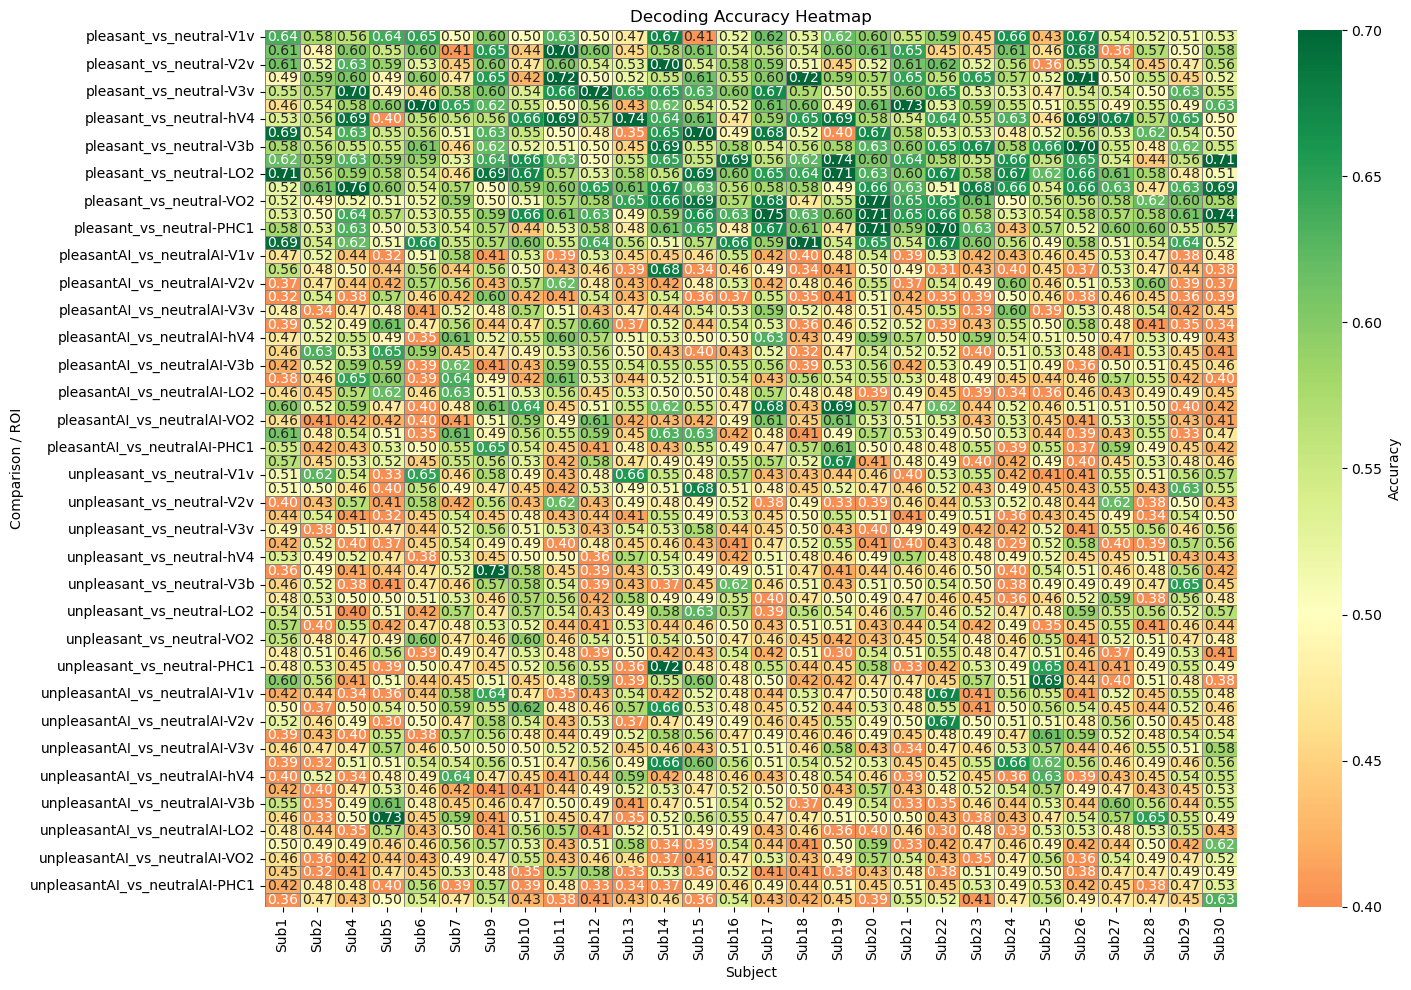


✓ Results table created and saved!


In [44]:
import pandas as pd
import numpy as np

def create_results_table(accuracy_results, roi_names, selected_subs):
    """
    Create a results table with:
    - Rows: Comparison_ROI combinations
    - Columns: Subjects
    - Values: Accuracy scores
    """
    
    # Initialize lists to build the DataFrame
    rows = []
    row_labels = []
    
    # Iterate through comparisons and ROIs
    for comparison in accuracy_results:
        acc_matrix = accuracy_results[comparison]  # (n_rois, n_subjects)
        
        for roi_idx, roi_name in enumerate(roi_names):
            # Create row label
            row_label = f"{comparison}_{roi_name}"
            row_labels.append(row_label)
            
            # Get accuracies for all subjects for this ROI
            roi_accuracies = acc_matrix[roi_idx]
            rows.append(roi_accuracies)
    
    # Create DataFrame
    df = pd.DataFrame(rows, columns=selected_subs, index=row_labels)
    
    # Round to 3 decimal places
    df = df.round(3)
    
    return df

# Create the table
roi_names = list(roi_masks.keys())
results_table = create_results_table(accuracy_results, roi_names, selected_subs)

# Display the table
print("\n" + "="*80)
print("DECODING ACCURACY TABLE")
print("="*80)
print(results_table)

# Create a more readable version with MultiIndex
def create_multiindex_table(accuracy_results, roi_names, selected_subs):
    """
    Create a multi-level index table for better readability
    """
    
    data_dict = {}
    
    for subj_idx, subj_name in enumerate(selected_subs):
        subj_data = []
        
        for comparison in accuracy_results:
            acc_matrix = accuracy_results[comparison]
            for roi_idx in range(len(roi_names)):
                subj_data.append(acc_matrix[roi_idx, subj_idx])
        
        data_dict[subj_name] = subj_data
    
    # Create MultiIndex for rows
    comparisons = []
    rois = []
    
    for comparison in accuracy_results:
        for roi_name in roi_names:
            comparisons.append(comparison)
            rois.append(roi_name)
    
    index = pd.MultiIndex.from_arrays([comparisons, rois], 
                                       names=['Comparison', 'ROI'])
    
    # Create DataFrame with MultiIndex
    df = pd.DataFrame(data_dict, index=index)
    
    return df.round(3)

# Create multi-index version
results_multi = create_multiindex_table(accuracy_results, roi_names, selected_subs)

print("\n" + "="*80)
print("MULTI-INDEX VERSION")
print("="*80)
print(results_multi)

# Calculate and add summary statistics
def add_summary_stats(df):
    """Add mean and std columns"""
    df_with_stats = df.copy()
    
    # Calculate mean and std ignoring NaN values
    df_with_stats['Mean'] = df.mean(axis=1, skipna=True).round(3)
    df_with_stats['Std'] = df.std(axis=1, skipna=True).round(3)
    df_with_stats['N_Valid'] = df.notna().sum(axis=1)
    
    return df_with_stats

# Add summary statistics
results_with_stats = add_summary_stats(results_multi)

print("\n" + "="*80)
print("RESULTS WITH SUMMARY STATISTICS")
print("="*80)
print(results_with_stats)

# Save to Excel with formatting
def save_to_excel(df, filename='decoding_results.xlsx'):
    """Save results to Excel with formatting"""
    
    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        df.to_excel(writer, sheet_name='Accuracy')
        
        # Get the workbook and worksheet
        workbook = writer.book
        worksheet = writer.sheets['Accuracy']
        
        # Define formats
        header_format = workbook.add_format({
            'bold': True,
            'text_wrap': True,
            'valign': 'top',
            'border': 1
        })
        
        # Format for accuracy values
        acc_format = workbook.add_format({
            'num_format': '0.000',
            'align': 'center'
        })
        
        # Format for NaN values
        nan_format = workbook.add_format({
            'bg_color': '#CCCCCC',
            'align': 'center'
        })
        
        # Apply conditional formatting for accuracy values
        # Highlight good (>0.6) and poor (<0.55) performance
        worksheet.conditional_format('D2:AZ100', {
            'type': '3_color_scale',
            'min_value': 0.4,
            'mid_value': 0.55,
            'max_value': 0.7,
            'min_color': '#FF6B6B',  # Red for poor
            'mid_color': '#FFFFCC',  # Yellow for chance
            'max_color': '#51CF66'   # Green for good
        })
    
    print(f"\nResults saved to {filename}")

# Save to Excel
# save_to_excel(results_with_stats)

# Create a summary table by comparison (averaging across ROIs)
def create_comparison_summary(accuracy_results, selected_subs):
    """Create summary table averaged across ROIs for each comparison"""
    
    summary_data = {}
    
    for comparison in accuracy_results:
        acc_matrix = accuracy_results[comparison]  # (n_rois, n_subjects)
        # Average across ROIs for each subject
        mean_across_rois = np.nanmean(acc_matrix, axis=0)
        summary_data[comparison] = mean_across_rois
    
    df = pd.DataFrame(summary_data, index=selected_subs).T
    df = df.round(3)
    
    # Add summary stats
    df['Mean'] = df.mean(axis=1, skipna=True).round(3)
    df['Std'] = df.std(axis=1, skipna=True).round(3)
    
    return df

comparison_summary = create_comparison_summary(accuracy_results, selected_subs)

print("\n" + "="*80)
print("SUMMARY BY COMPARISON (Averaged Across ROIs)")
print("="*80)
print(comparison_summary)

# Create a heatmap visualization
import matplotlib.pyplot as plt
import seaborn as sns

def plot_accuracy_heatmap(df, title="Decoding Accuracy Heatmap"):
    """Create a heatmap of accuracy values"""
    
    plt.figure(figsize=(15, 10))
    
    # Create heatmap
    sns.heatmap(df.select_dtypes(include=[np.number]),  # Only numeric columns
                annot=True, 
                fmt='.2f',
                cmap='RdYlGn',
                center=0.5,  # Center colormap at chance level
                vmin=0.4, 
                vmax=0.7,
                cbar_kws={'label': 'Accuracy'},
                linewidths=0.5,
                linecolor='gray')
    
    plt.title(title)
    plt.xlabel('Subject')
    plt.ylabel('Comparison / ROI')
    plt.tight_layout()
    plt.savefig('accuracy_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot heatmap (without summary stats columns)
subject_cols = [col for col in results_multi.columns if col in selected_subs]
plot_accuracy_heatmap(results_multi[subject_cols])

print("\n✓ Results table created and saved!")

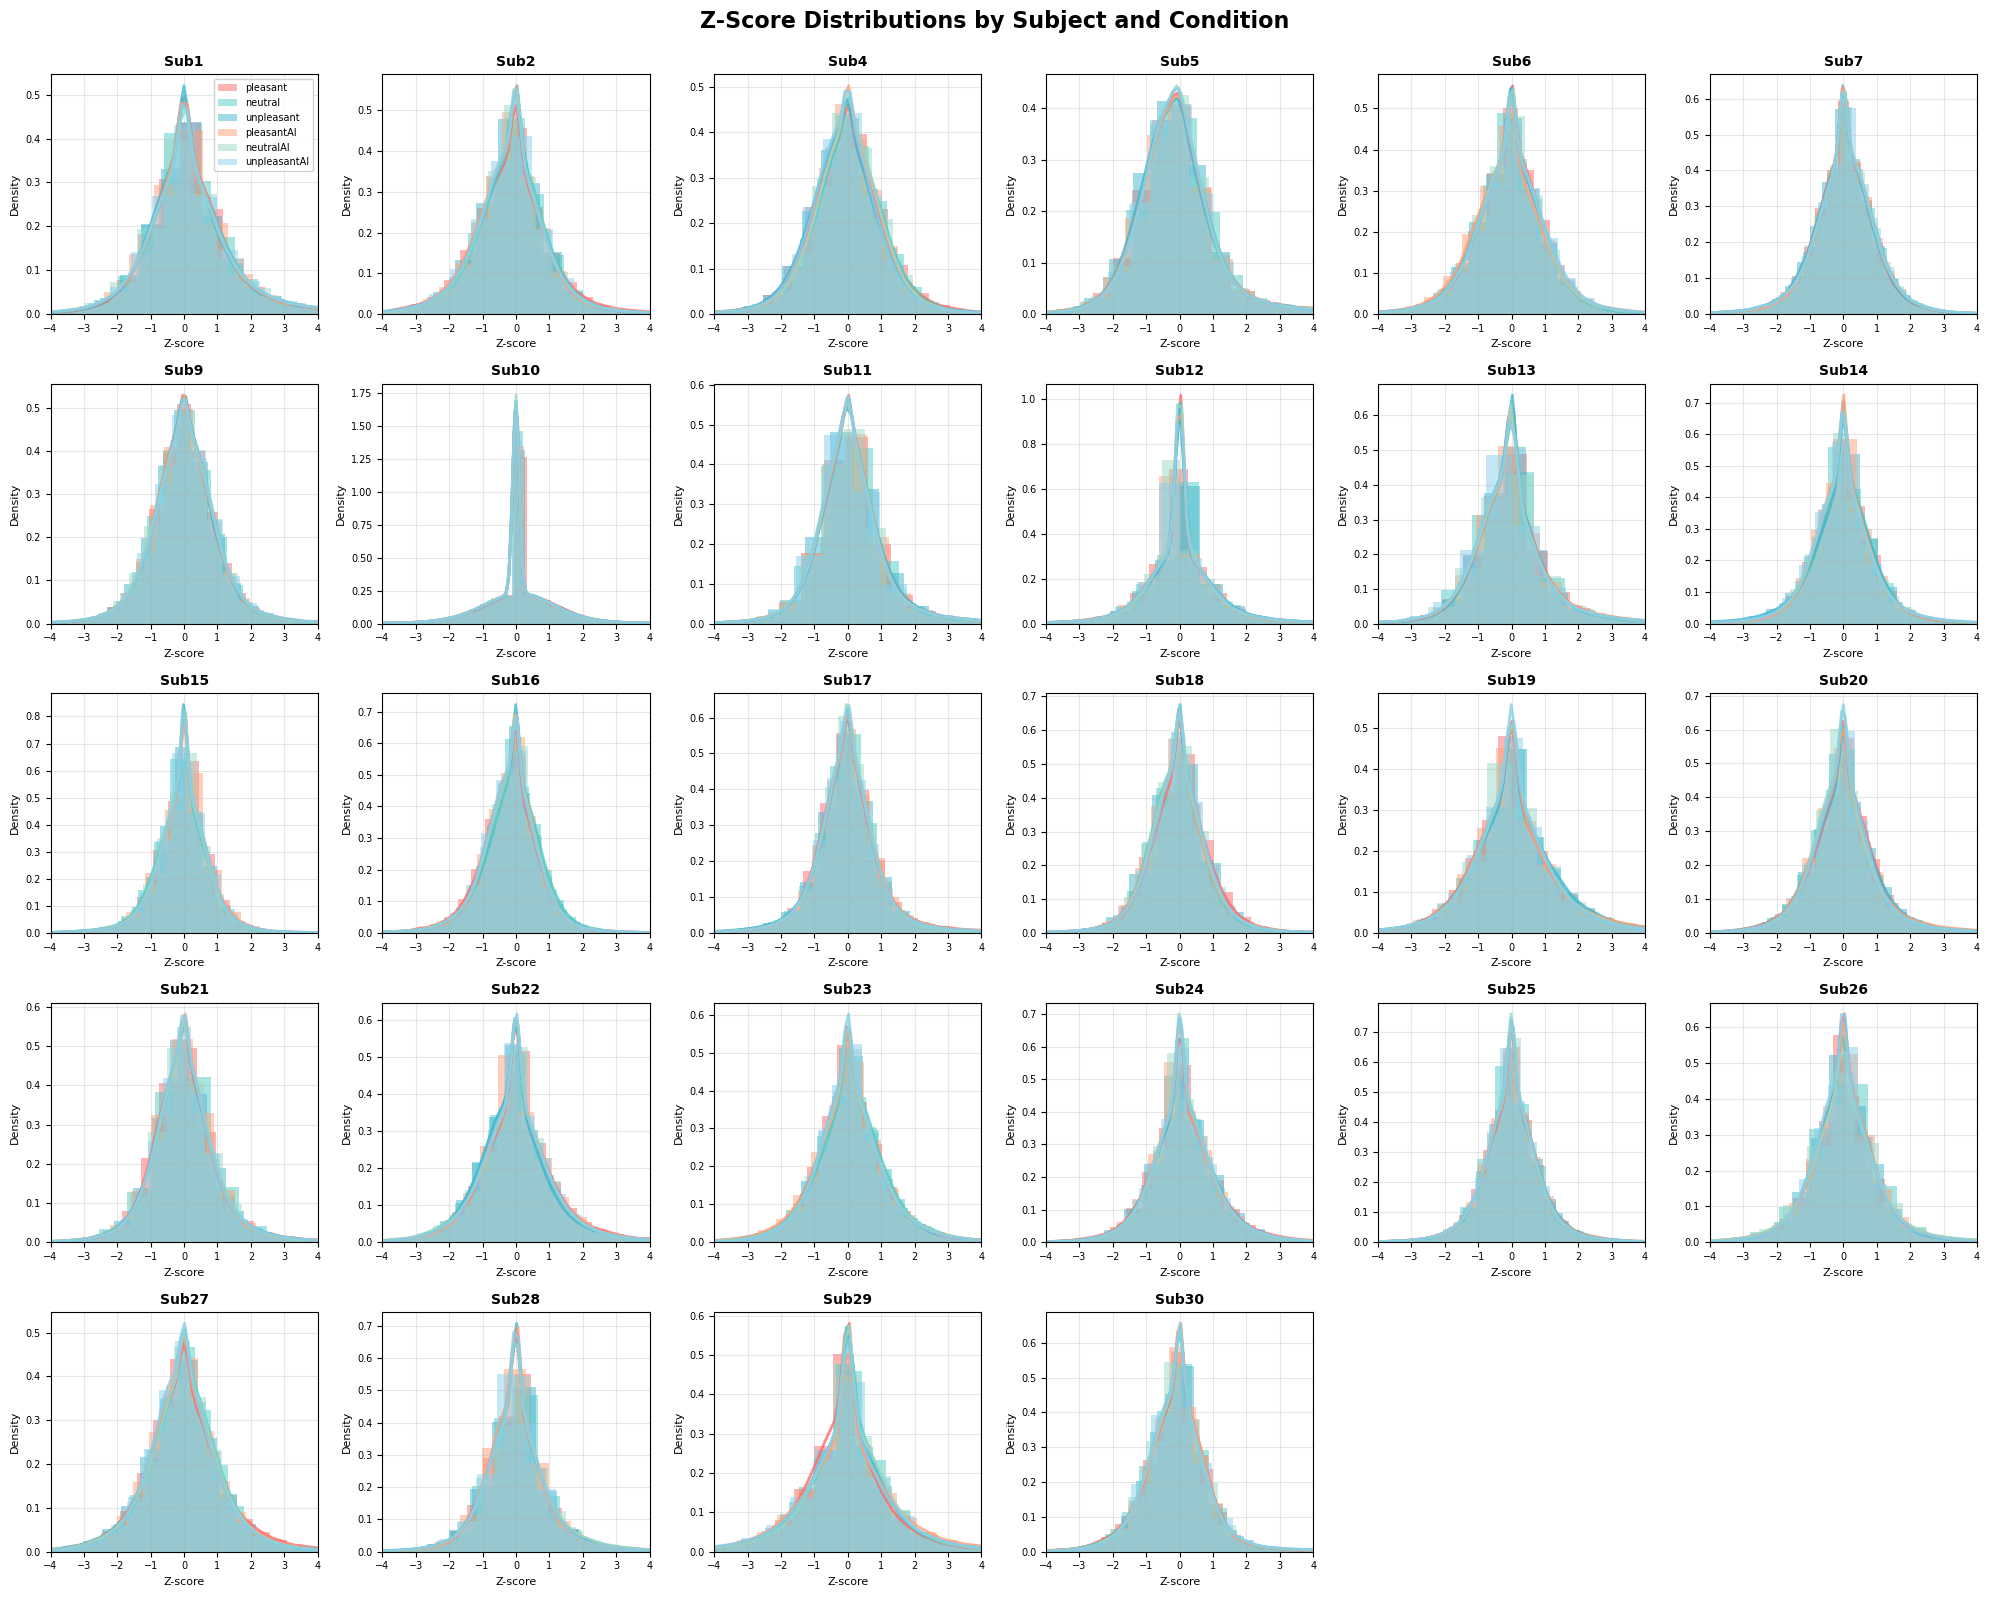


DISTRIBUTION SUMMARY STATISTICS

Sub1:
  pleasant       : mean= 0.233, std= 1.523, n=4,568,380
  neutral        : mean= 0.225, std= 1.536, n=4,568,380
  unpleasant     : mean= 0.163, std= 1.495, n=4,568,380
  pleasantAI     : mean= 0.199, std= 1.553, n=4,568,380
  neutralAI      : mean= 0.231, std= 1.642, n=4,568,380
  unpleasantAI   : mean= 0.214, std= 1.576, n=4,568,380

Sub2:
  pleasant       : mean=-0.163, std= 1.319, n=4,568,380
  neutral        : mean=-0.141, std= 1.200, n=4,568,380
  unpleasant     : mean=-0.211, std= 1.210, n=4,568,380
  pleasantAI     : mean=-0.217, std= 1.171, n=4,568,380
  neutralAI      : mean=-0.161, std= 1.170, n=4,568,380
  unpleasantAI   : mean=-0.234, std= 1.229, n=4,568,380

Sub4:
  pleasant       : mean=-0.033, std= 1.266, n=4,568,380
  neutral        : mean= 0.016, std= 1.182, n=4,568,380
  unpleasant     : mean=-0.113, std= 1.235, n=4,568,380
  pleasantAI     : mean=-0.032, std= 1.161, n=4,568,380
  neutralAI      : mean=-0.020, std= 1.147, n=4,56

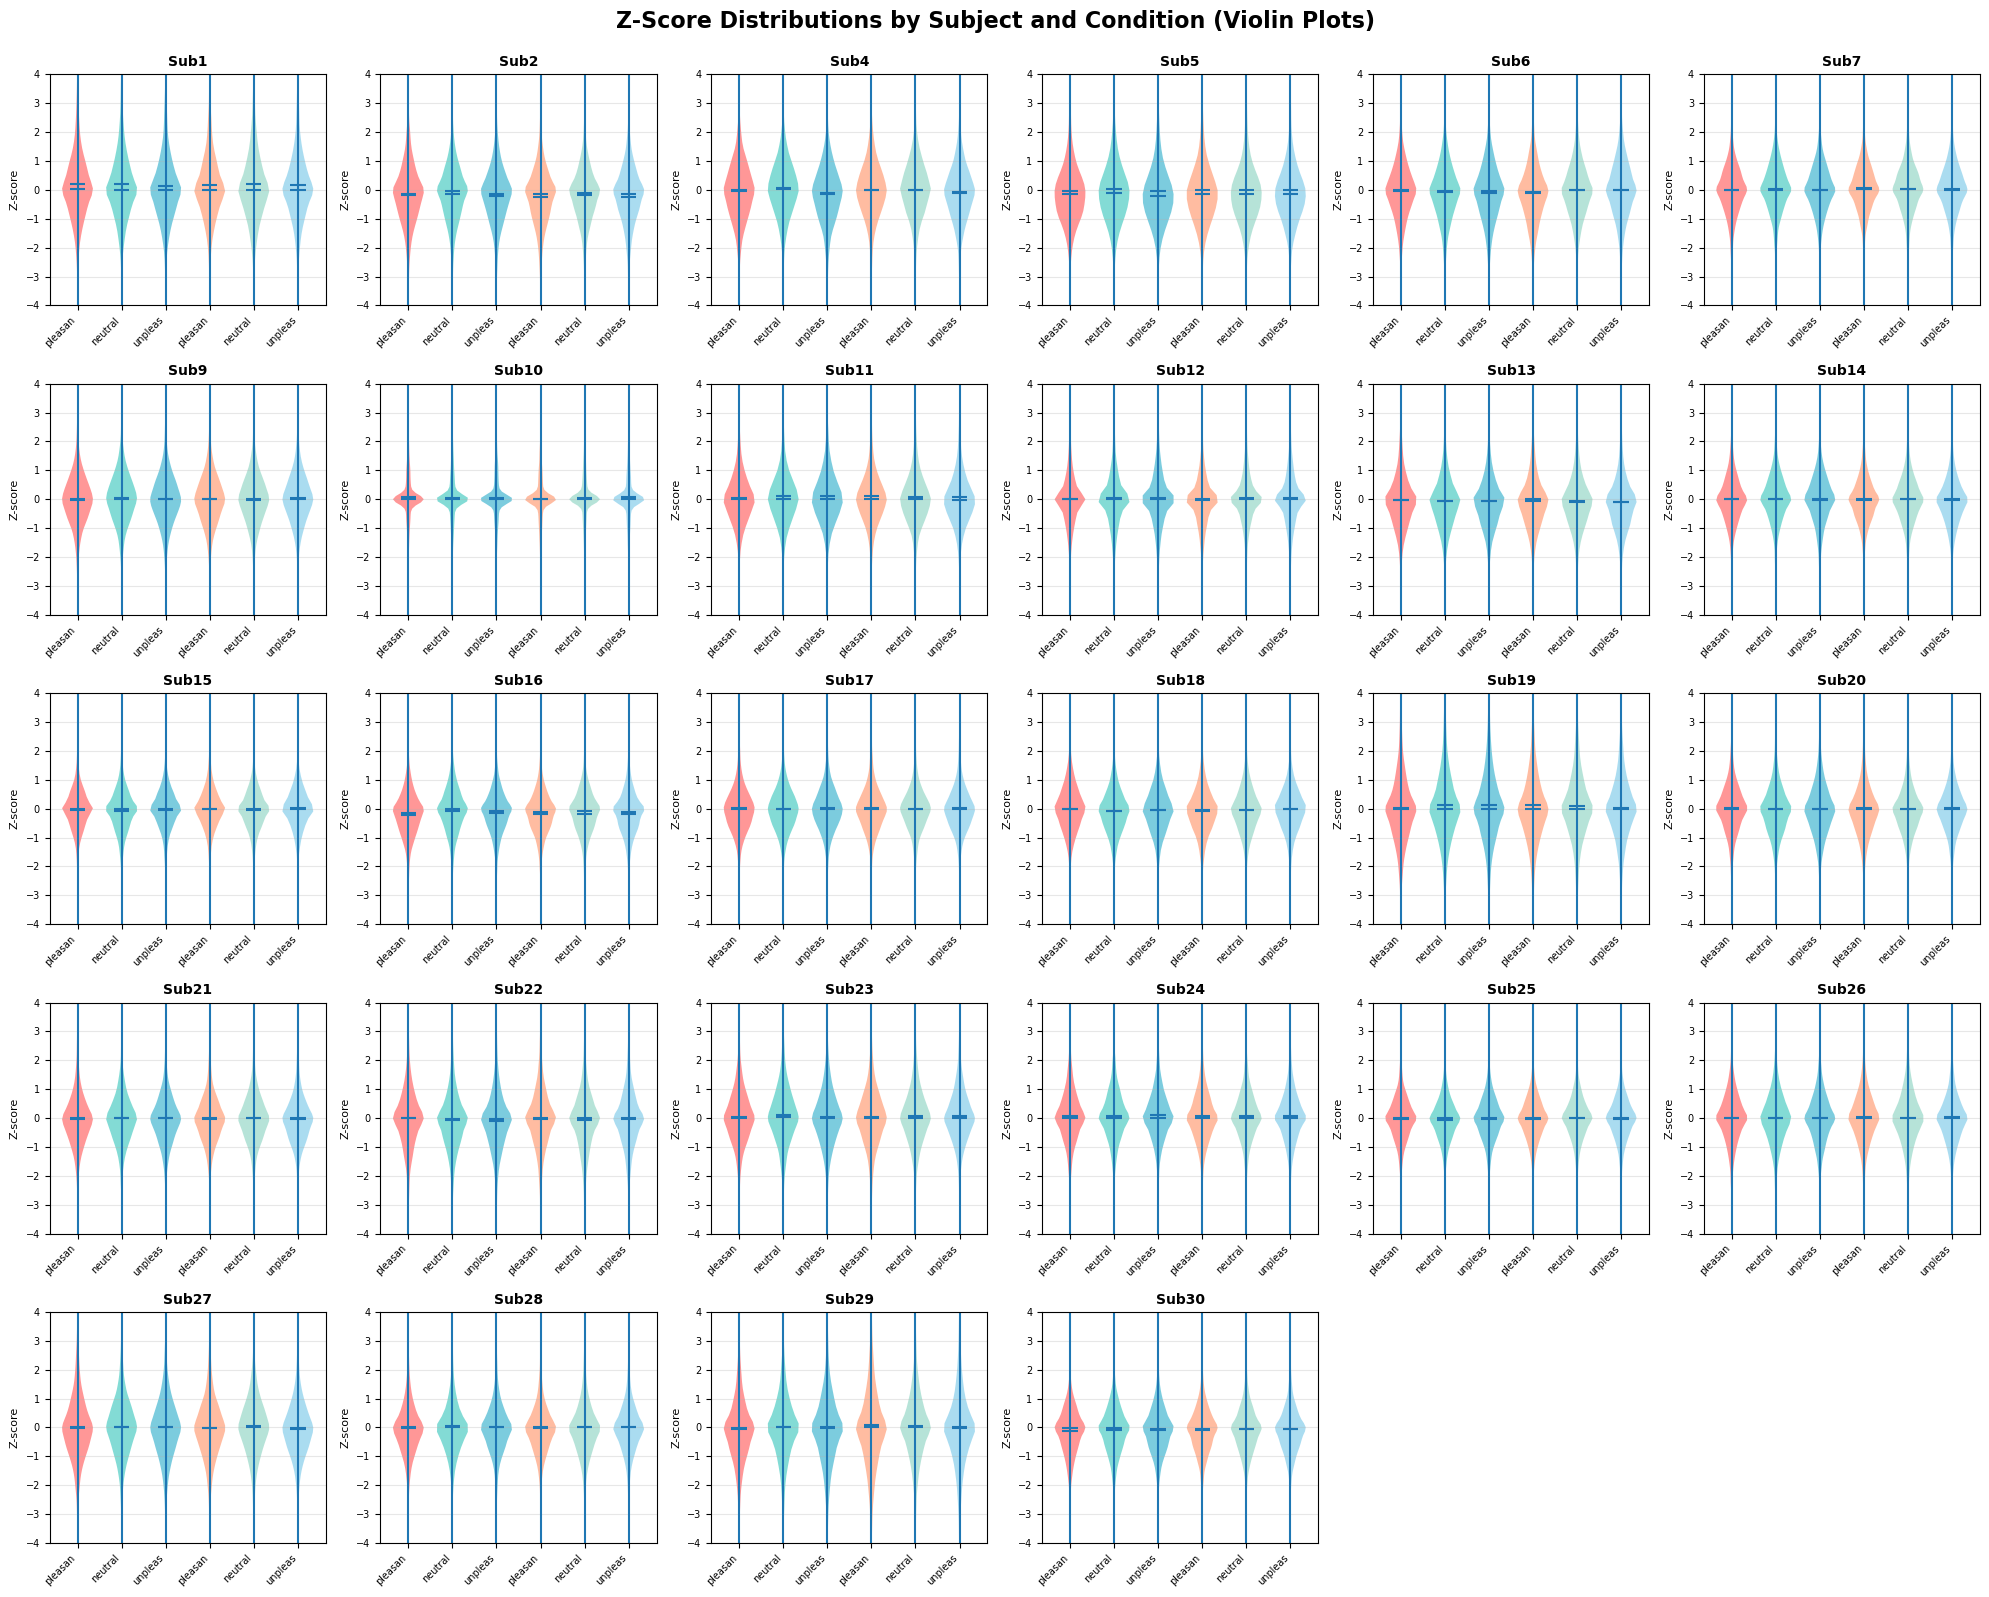

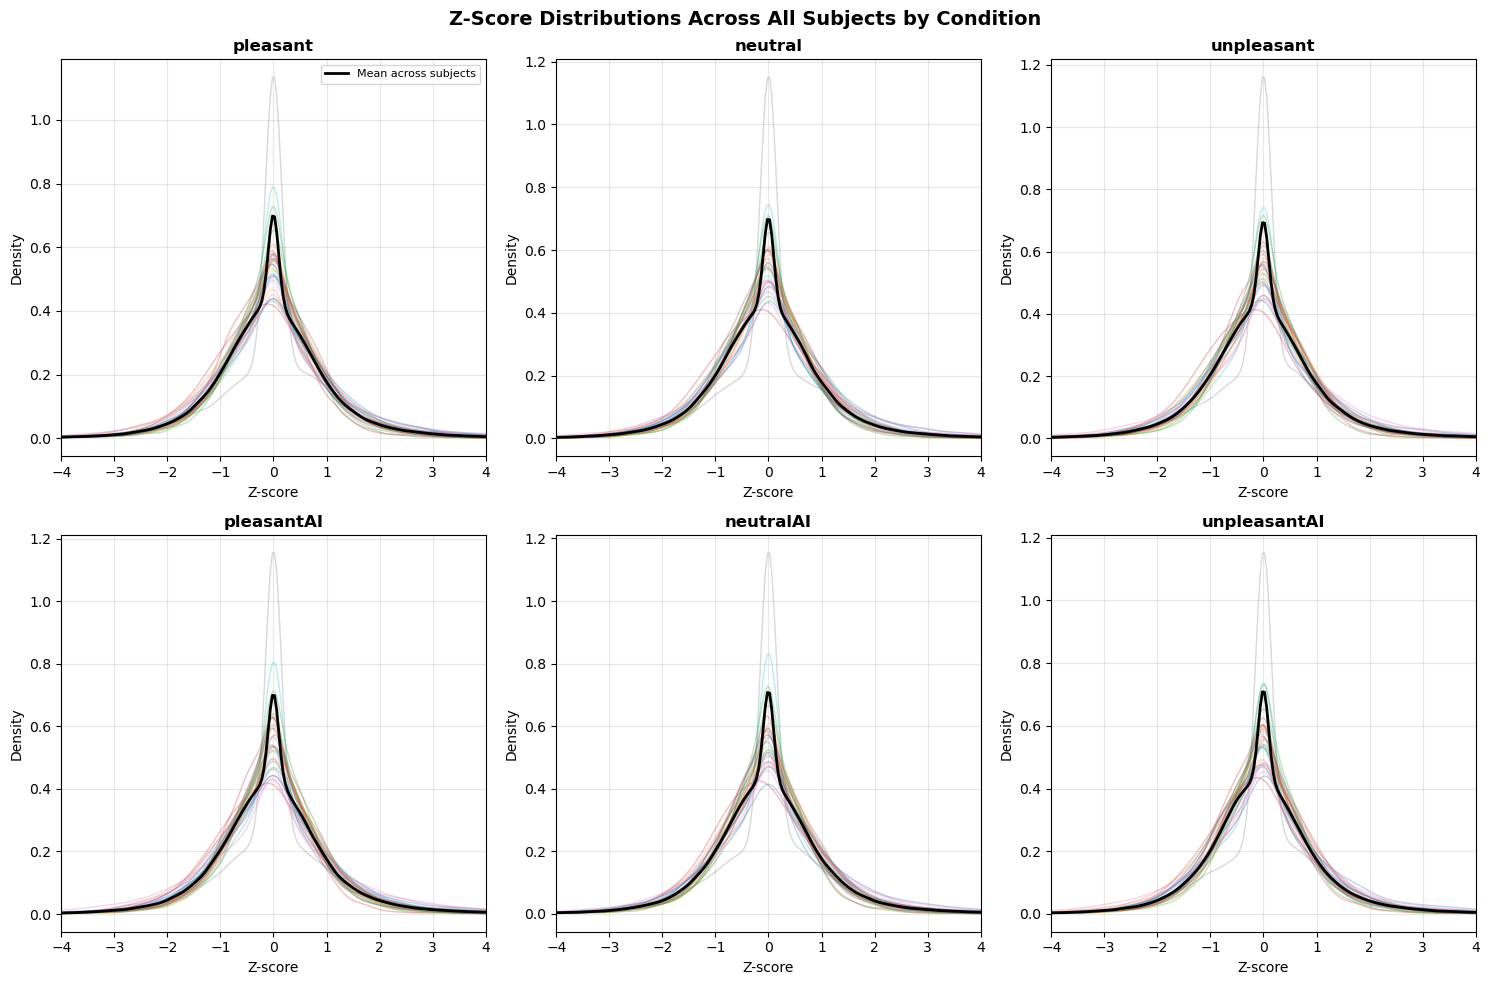


✓ Distribution plots created and saved!


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_subject_distributions(z_flat_avg, avg_metadata, selected_subs):
    """
    Create 5x6 subplot figure with z-value distributions for each subject
    Each subplot shows 6 distributions (one per condition) in different colors
    """
    
    # Define colors for each condition
    condition_colors = {
        'pleasant': '#FF6B6B',      # Red
        'neutral': '#4ECDC4',       # Teal
        'unpleasant': '#45B7D1',    # Blue
        'pleasantAI': '#FFA07A',     # Light Red
        'neutralAI': '#98D8C8',     # Light Teal
        'unpleasantAI': '#87CEEB'   # Sky Blue
    }
    
    # Create figure with 5x6 subplots
    fig, axes = plt.subplots(5, 6, figsize=(20, 16))
    axes = axes.flatten()  # Flatten for easier indexing
    
    # Get group order
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    
    # Process each subject
    for subj_idx in range(len(selected_subs)):
        ax = axes[subj_idx]
        
        # Store data for each condition
        condition_data = {}
        
        for group in group_order:
            # Get indices for this group
            group_mask = avg_metadata['group'] == group
            group_indices = np.where(group_mask)[0]
            
            # Get z-values for this subject and group
            # Flatten across all voxels and stimuli in this group
            group_z_values = z_flat_avg[subj_idx, group_indices, :].flatten()
            
            # Remove NaN values
            group_z_values = group_z_values[~np.isnan(group_z_values)]
            
            # Sample if too many values (for plotting efficiency)
            if len(group_z_values) > 100000:
                np.random.seed(42)  # For reproducibility
                group_z_values = np.random.choice(group_z_values, 100000, replace=False)
            
            condition_data[group] = group_z_values
        
        # Plot distributions
        for group in group_order:
            if len(condition_data[group]) > 0:
                # Use kernel density estimation for smooth curves
                ax.hist(condition_data[group], 
                       bins=50, 
                       alpha=0.5, 
                       color=condition_colors[group],
                       label=group,
                       density=True,
                       histtype='stepfilled')
                
                # Add KDE curve for better visualization
                from scipy import stats
                density = stats.gaussian_kde(condition_data[group])
                xs = np.linspace(condition_data[group].min(), 
                               condition_data[group].max(), 200)
                ax.plot(xs, density(xs), color=condition_colors[group], 
                       linewidth=2, alpha=0.8)
        
        # Customize subplot
        ax.set_title(f'{selected_subs[subj_idx]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Z-score', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_xlim(-4, 4)  # Standard z-score range
        ax.grid(True, alpha=0.3)
        
        # Add legend only to first subplot
        if subj_idx == 0:
            ax.legend(loc='upper right', fontsize=7, framealpha=0.9)
    
    # Remove empty subplots if less than 30 subjects
    for i in range(len(selected_subs), 30):
        axes[i].set_visible(False)
    
    # Overall title
    fig.suptitle('Z-Score Distributions by Subject and Condition', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    # Save figure
    plt.savefig('subject_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("DISTRIBUTION SUMMARY STATISTICS")
    print("="*60)
    
    for subj_idx in range(min(3, len(selected_subs))):  # Show first 3 subjects as example
        print(f"\n{selected_subs[subj_idx]}:")
        for group in group_order:
            group_mask = avg_metadata['group'] == group
            group_indices = np.where(group_mask)[0]
            group_z_values = z_flat_avg[subj_idx, group_indices, :].flatten()
            group_z_values = group_z_values[~np.isnan(group_z_values)]
            
            if len(group_z_values) > 0:
                print(f"  {group:15s}: mean={np.mean(group_z_values):6.3f}, "
                      f"std={np.std(group_z_values):6.3f}, "
                      f"n={len(group_z_values):,}")

# Create the plot
plot_subject_distributions(z_flat_avg, avg_metadata, selected_subs)

# Alternative: Violin plots for cleaner visualization
def plot_violin_distributions(z_flat_avg, avg_metadata, selected_subs):
    """
    Alternative visualization using violin plots
    """
    
    # Create figure with 5x6 subplots
    fig, axes = plt.subplots(5, 6, figsize=(20, 16))
    axes = axes.flatten()
    
    # Define colors
    condition_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', 
                       '#FFA07A', '#98D8C8', '#87CEEB']
    
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    
    for subj_idx in range(len(selected_subs)):
        ax = axes[subj_idx]
        
        # Prepare data for violin plot
        plot_data = []
        plot_labels = []
        
        for group in group_order:
            group_mask = avg_metadata['group'] == group
            group_indices = np.where(group_mask)[0]
            
            # Sample voxels for visualization (to avoid memory issues)
            n_voxels_to_sample = 1000
            group_z_values = z_flat_avg[subj_idx, group_indices, :]
            
            # Randomly sample voxels
            if group_z_values.shape[1] > n_voxels_to_sample:
                np.random.seed(42)
                voxel_sample = np.random.choice(group_z_values.shape[1], 
                                              n_voxels_to_sample, replace=False)
                group_z_values = group_z_values[:, voxel_sample]
            
            # Flatten and remove NaN
            group_z_values = group_z_values.flatten()
            group_z_values = group_z_values[~np.isnan(group_z_values)]
            
            if len(group_z_values) > 0:
                plot_data.append(group_z_values)
                plot_labels.append(group[:7])  # Truncate long labels
        
        # Create violin plot
        if plot_data:
            parts = ax.violinplot(plot_data, positions=range(len(plot_data)),
                                 widths=0.7, showmeans=True, showmedians=True)
            
            # Color the violins
            for pc, color in zip(parts['bodies'], condition_colors[:len(plot_data)]):
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
        
        # Customize subplot
        ax.set_title(f'{selected_subs[subj_idx]}', fontsize=10, fontweight='bold')
        ax.set_xticks(range(len(plot_labels)))
        ax.set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Z-score', fontsize=8)
        ax.set_ylim(-4, 4)
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(labelsize=7)
    
    # Remove empty subplots
    for i in range(len(selected_subs), 30):
        axes[i].set_visible(False)
    
    fig.suptitle('Z-Score Distributions by Subject and Condition (Violin Plots)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.savefig('subject_distributions_violin.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create violin plot version
plot_violin_distributions(z_flat_avg, avg_metadata, selected_subs)

# Create a summary plot showing all subjects overlaid
def plot_group_comparison(z_flat_avg, avg_metadata, selected_subs):
    """
    Create a single plot comparing distributions across all subjects
    """
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    
    for idx, group in enumerate(group_order):
        ax = axes[idx]
        
        # Get data for all subjects for this condition
        group_mask = avg_metadata['group'] == group
        group_indices = np.where(group_mask)[0]
        
        # Plot distribution for each subject
        for subj_idx in range(len(selected_subs)):
            # Sample data for plotting
            group_z = z_flat_avg[subj_idx, group_indices, :].flatten()
            group_z = group_z[~np.isnan(group_z)]
            
            if len(group_z) > 10000:
                np.random.seed(42)
                group_z = np.random.choice(group_z, 10000, replace=False)
            
            # Plot KDE
            if len(group_z) > 0:
                from scipy import stats
                density = stats.gaussian_kde(group_z)
                xs = np.linspace(-4, 4, 200)
                ax.plot(xs, density(xs), alpha=0.3, linewidth=1)
        
        # Calculate and plot mean distribution across subjects
        all_subj_data = []
        for subj_idx in range(len(selected_subs)):
            group_z = z_flat_avg[subj_idx, group_indices, :].flatten()
            group_z = group_z[~np.isnan(group_z)]
            if len(group_z) > 10000:
                np.random.seed(42)
                group_z = np.random.choice(group_z, 10000, replace=False)
            all_subj_data.extend(group_z)
        
        if all_subj_data:
            density = stats.gaussian_kde(all_subj_data)
            xs = np.linspace(-4, 4, 200)
            ax.plot(xs, density(xs), color='black', linewidth=2, 
                   label='Mean across subjects')
        
        ax.set_title(f'{group}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Z-score')
        ax.set_ylabel('Density')
        ax.set_xlim(-4, 4)
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.legend(loc='upper right', fontsize=8)
    
    fig.suptitle('Z-Score Distributions Across All Subjects by Condition', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('group_distributions_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create group comparison
plot_group_comparison(z_flat_avg, avg_metadata, selected_subs)

print("\n✓ Distribution plots created and saved!")

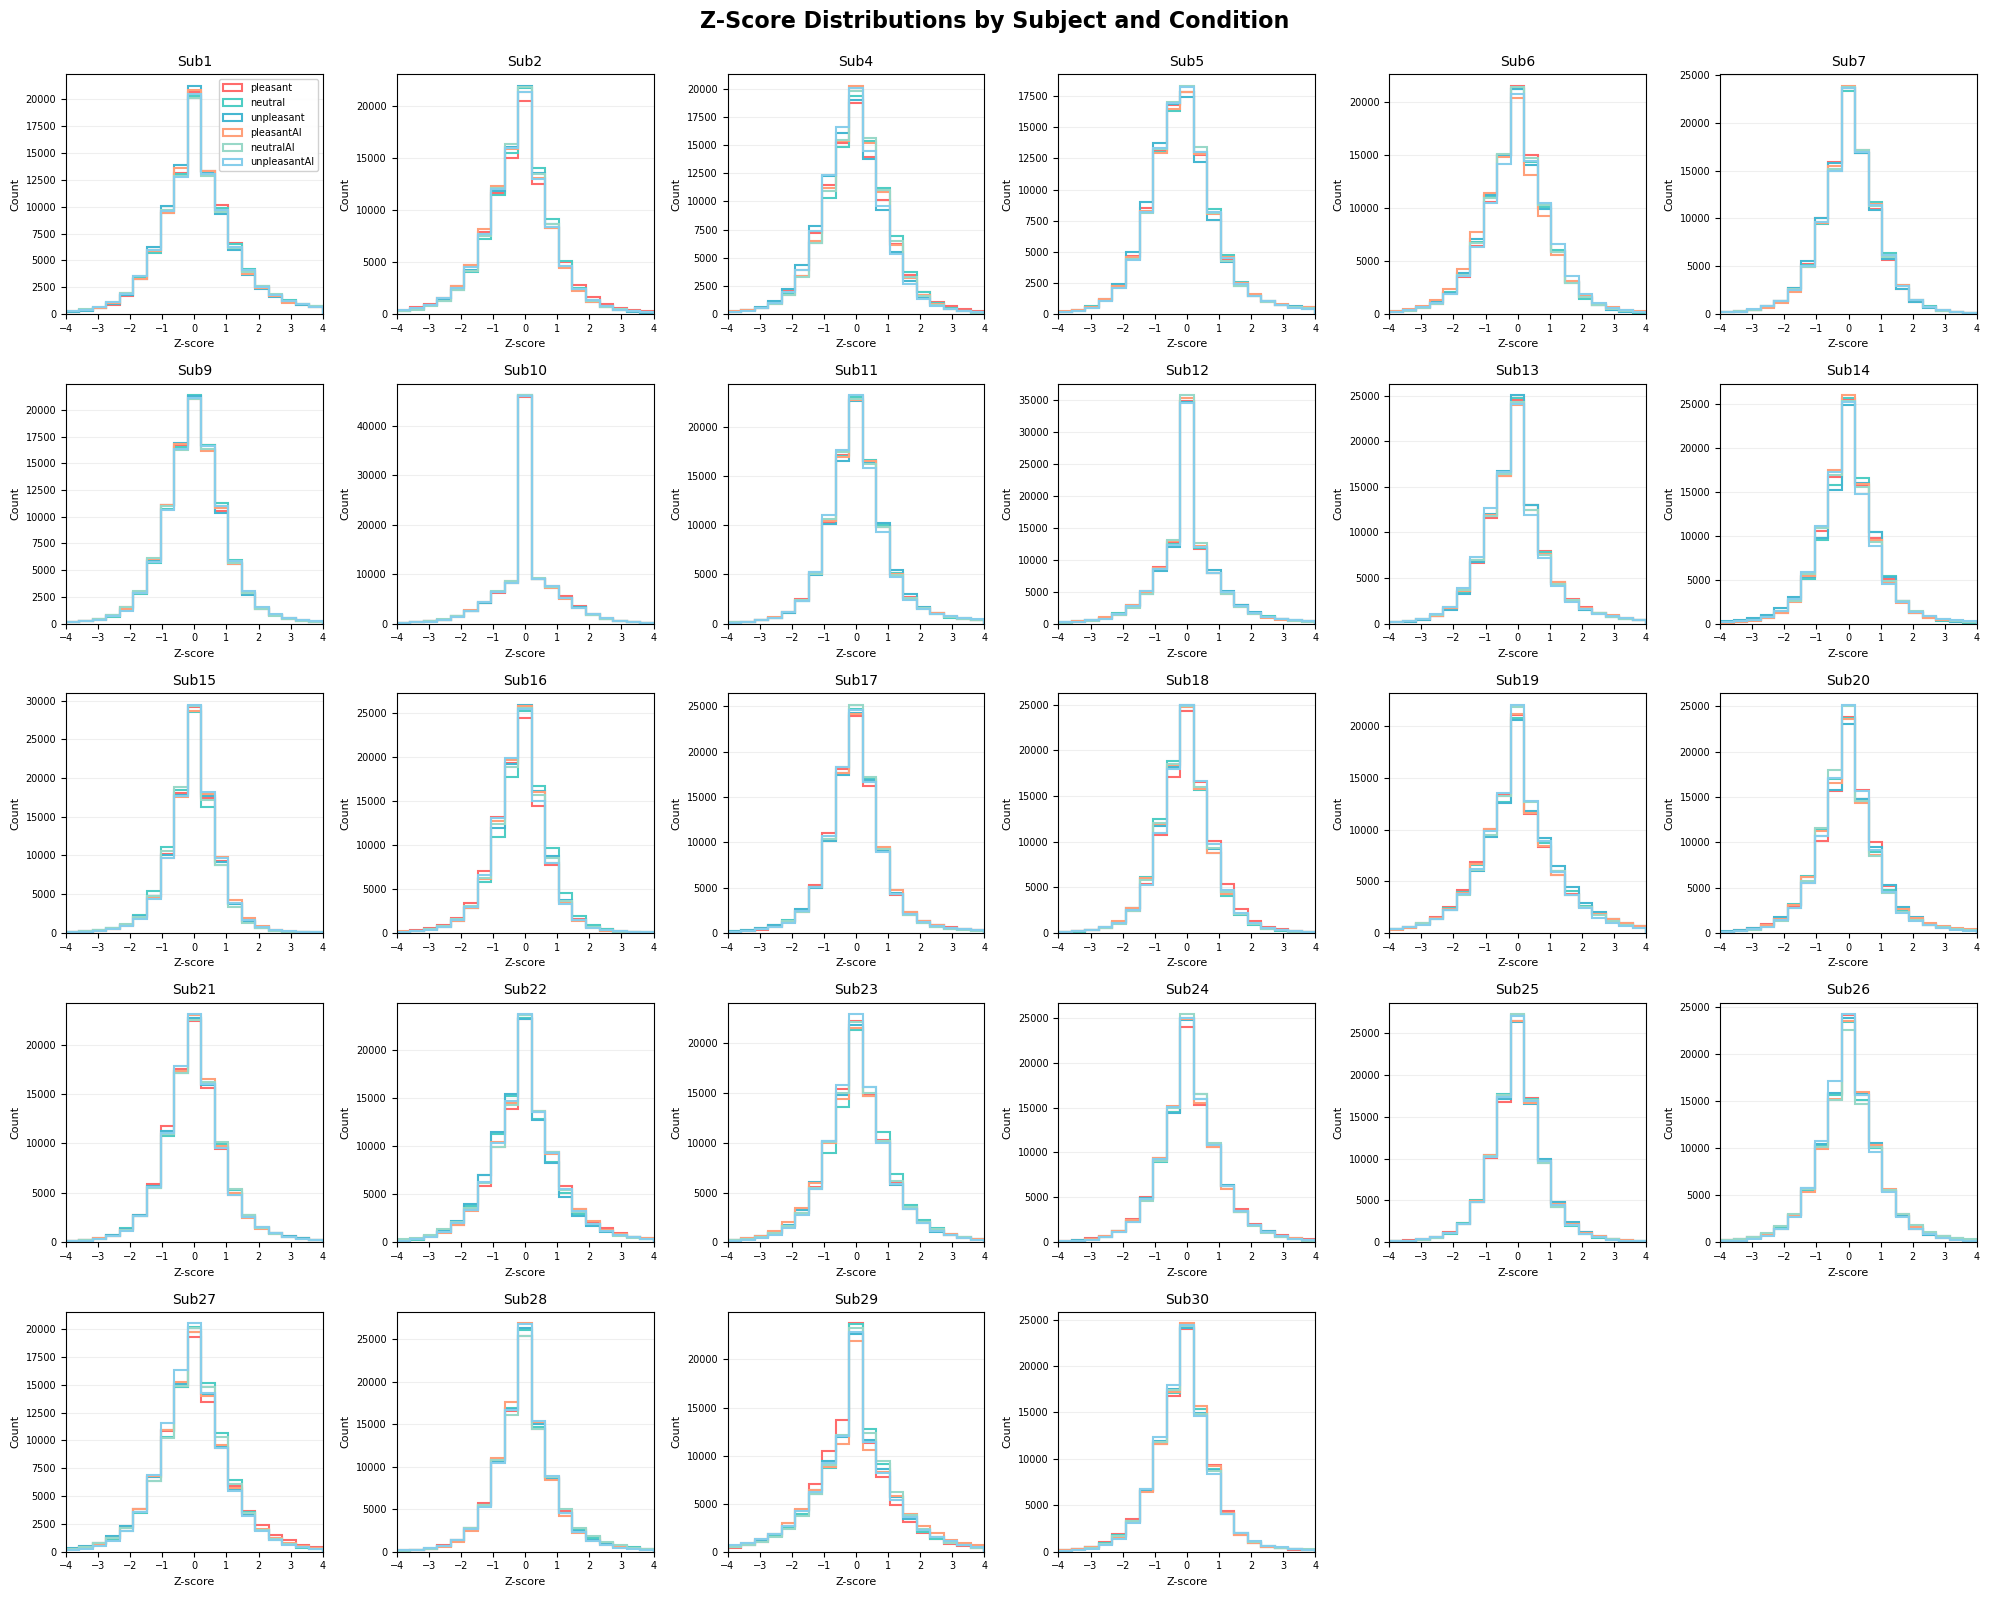

In [47]:
import matplotlib.pyplot as plt
import numpy as np

def plot_subject_distributions_clean(z_flat_avg, avg_metadata, selected_subs):
    """
    Create 5x6 subplot figure with z-value distributions using hollow bars
    Y-axis shows counts instead of density
    """
    
    # Define colors for each condition
    condition_colors = {
        'pleasant': '#FF6B6B',      # Red
        'neutral': '#4ECDC4',       # Teal
        'unpleasant': '#45B7D1',    # Blue
        'pleasantAI': '#FFA07A',     # Light Red
        'neutralAI': '#98D8C8',     # Light Teal
        'unpleasantAI': '#87CEEB'   # Sky Blue
    }
    
    # Create figure with 5x6 subplots
    fig, axes = plt.subplots(5, 6, figsize=(20, 16))
    axes = axes.flatten()
    
    # Get group order
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    
    # Define common bins for all distributions
    bins = np.linspace(-4, 4, 20)
    
    # Process each subject
    for subj_idx in range(len(selected_subs)):
        ax = axes[subj_idx]
        
        # Plot each condition
        for group in group_order:
            # Get indices for this group
            group_mask = avg_metadata['group'] == group
            group_indices = np.where(group_mask)[0]
            
            # Get z-values for this subject and group
            group_z_values = z_flat_avg[subj_idx, group_indices, :].flatten()
            
            # Remove NaN values
            group_z_values = group_z_values[~np.isnan(group_z_values)]
            
            # Sample if too many values (for plotting efficiency)
            if len(group_z_values) > 100000:
                np.random.seed(42)
                group_z_values = np.random.choice(group_z_values, 100000, replace=False)
            
            # Plot histogram with hollow bars (step style)
            if len(group_z_values) > 0:
                ax.hist(group_z_values, 
                       bins=bins,
                       histtype='step',  # Hollow bars
                       color=condition_colors[group],
                       linewidth=1.5,
                       label=group if subj_idx == 0 else None)  # Only label first subplot
        
        # Customize subplot
        ax.set_title(f'{selected_subs[subj_idx]}', fontsize=10)
        ax.set_xlabel('Z-score', fontsize=8)
        ax.set_ylabel('Count', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_xlim(-4, 4)
        ax.grid(True, alpha=0.2, axis='y')
        
        # Add legend only to first subplot
        if subj_idx == 0:
            ax.legend(loc='upper right', fontsize=7, framealpha=0.9)
    
    # Remove empty subplots if less than 30 subjects
    for i in range(len(selected_subs), 30):
        axes[i].set_visible(False)
    
    # Overall title
    fig.suptitle('Z-Score Distributions by Subject and Condition', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    # Save figure
    plt.savefig('subject_distributions_hollow.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create the plot
plot_subject_distributions_clean(z_flat_avg, avg_metadata, selected_subs)

## Cross modality

# Whole brain decoding

## Average by repeatition 

In [10]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from tqdm import tqdm
import nibabel as nib
from nilearn.image import resample_img
# from nilearn.searchlight import get_volume_searchlight
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight
import os
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# SETUP MASK
# ==============================================================================

# Load and resample mask to match your data
maskDir = r'N:\Experimental_Data\yujunchen\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

# Use one of your beta files as template for resampling
temp_nii_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\betas\Sub1\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)

# Resample the MNI mask to match your data dimensions
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
print(f"Resampled mask shape: {resampled_mask.shape}")

# ==============================================================================
# Z-SCORING AND AVERAGING FUNCTIONS
# ==============================================================================

def zscore_within_runs_preserve_conditions(beta_flat, stimuli):
    """Z-score within runs but across voxels (preserves condition differences)"""
    n_subjects, n_trials, n_voxels = beta_flat.shape
    z_scored = np.zeros_like(beta_flat, dtype=np.float32)
    
    print("Z-scoring within runs (normalizing spatial patterns)...")
    for subj in range(n_subjects):
        for run in stimuli['run'].unique():
            run_mask = stimuli['run'] == run
            run_indices = np.where(run_mask)[0]
            
            # Z-score each trial's spatial pattern
            for trial_idx in run_indices:
                trial_data = beta_flat[subj, trial_idx, :]
                valid = ~np.isnan(trial_data)
                
                if valid.sum() > 0:
                    mean = trial_data[valid].mean()
                    std = trial_data[valid].std()
                    if std > 0:
                        z_scored[subj, trial_idx, :] = (trial_data - mean) / std
                    else:
                        z_scored[subj, trial_idx, :] = trial_data - mean
                else:
                    z_scored[subj, trial_idx, :] = np.nan
    
    return z_scored

def average_repetitions(beta_z, stimuli):
    """Average the 5 repetitions of each unique stimulus"""
    n_subjects, n_trials, n_voxels = beta_z.shape
    unique_imgs = stimuli['img'].unique()
    n_unique = len(unique_imgs)
    
    print(f"Averaging {n_unique} unique stimuli (5 repetitions each)...")
    
    beta_avg = np.zeros((n_subjects, n_unique, n_voxels), dtype=np.float32)
    avg_metadata = []
    
    for i, img in enumerate(unique_imgs):
        img_mask = stimuli['img'] == img
        img_indices = np.where(img_mask)[0]
        
        beta_avg[:, i, :] = np.nanmean(beta_z[:, img_indices, :], axis=1)
        
        img_info = stimuli[img_mask].iloc[0]
        avg_metadata.append({
            'idx': i,
            'img': img,
            'group': img_info['group'],
            'emotion_type': img_info['emotion_type'],
            'AI': img_info['AI']
        })
    
    avg_df = pd.DataFrame(avg_metadata)
    
    # Sort by group for consistent ordering
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    avg_df['group'] = pd.Categorical(avg_df['group'], categories=group_order, ordered=True)
    avg_df = avg_df.sort_values(['group', 'img']).reset_index(drop=True)
    
    beta_avg_sorted = beta_avg[:, avg_df['idx'].values, :]
    
    return beta_avg_sorted, avg_df

# ==============================================================================
# SEARCHLIGHT DECODING
# ==============================================================================

def searchlight_decoding_nilearn(z_flat_avg, avg_metadata, resampled_mask, 
                                 subjects_to_run=None, radius=5):
    """
    Perform searchlight decoding using nilearn's searchlight
    
    Parameters:
    -----------
    z_flat_avg: (n_subjects, n_stimuli, n_voxels) averaged beta values
    avg_metadata: DataFrame with stimulus information
    resampled_mask: NIfTI mask object (already resampled to match data)
    subjects_to_run: list of subject indices (default: first 2)
    radius: searchlight radius in mm
    """
    
    if subjects_to_run is None:
        subjects_to_run = [0, 1]  # First 2 subjects by default
    
    # Get searchlight centers and neighbors
    print(f"Creating searchlight with radius={radius}mm...")
    centers, neighbors = get_volume_searchlight(resampled_mask.get_fdata(), radius=radius, threshold=0.5)
    print(f"Number of searchlight centers: {len(centers)}")
    
    # Get mask data
    mask_data = resampled_mask.get_fdata()
    dims = mask_data.shape
    n_voxels_total = np.prod(dims)
    
    # Define comparisons
    comparisons = [
        ('pleasant', 'neutral'),
        ('pleasantAI', 'neutralAI'),
        ('unpleasant', 'neutral'),
        ('unpleasantAI', 'neutralAI')
    ]
    
    # Initialize results
    results = {}
    
    for cond1, cond2 in comparisons:
        print(f"\n{'='*60}")
        print(f"Comparison: {cond1} vs {cond2}")
        print('='*60)
        
        # Get condition indices
        cond1_idx = avg_metadata[avg_metadata['group'] == cond1].index.values
        cond2_idx = avg_metadata[avg_metadata['group'] == cond2].index.values
        
        comparison_key = f"{cond1}_vs_{cond2}"
        results[comparison_key] = {}
        
        for subj_idx in subjects_to_run:
            print(f"\nSubject {subj_idx + 1}:")
            
            # Initialize accuracy map
            accuracy_map = np.full(n_voxels_total, np.nan, dtype=np.float32)
            
            # Get subject data and prepare for classification
            subj_data = z_flat_avg[subj_idx]  # (n_stimuli, n_voxels)
            X_cond1 = subj_data[cond1_idx, :]
            X_cond2 = subj_data[cond2_idx, :]
            X = np.vstack([X_cond1, X_cond2])
            y = np.hstack([np.ones(len(cond1_idx)), np.zeros(len(cond2_idx))])
            
            # Run searchlight for each center
            valid_searchlights = 0
            
            for center_idx, neighbor_indices in tqdm(enumerate(neighbors), 
                                                     total=len(neighbors), 
                                                     desc='Searchlight'):
                # Get center voxel flat index
                center_flat_idx = centers[center_idx]
                
                # Get data for searchlight voxels
                X_searchlight = X[:, neighbor_indices]
                
                # Check for NaN voxels
                valid_voxels = ~np.any(np.isnan(X_searchlight), axis=0)
                n_valid = valid_voxels.sum()
                
                # Need at least 10 valid voxels
                if n_valid < 10:
                    continue
                
                X_clean = X_searchlight[:, valid_voxels]
                
                # Check for variance
                if np.std(X_clean) == 0:
                    continue
                
                # Perform cross-validation
                try:
                    clf = SVC(kernel='linear', C=1.0, max_iter=1000)
                    scores = cross_val_score(clf, X_clean, y, cv=5, scoring='accuracy')
                    accuracy_map[center_flat_idx] = scores.mean()
                    valid_searchlights += 1
                except Exception as e:
                    continue
            
            # Reshape to 3D
            accuracy_map_3d = accuracy_map.reshape(dims)
            results[comparison_key][f'subject_{subj_idx}'] = accuracy_map_3d
            
            # Print summary
            valid_accs = accuracy_map[~np.isnan(accuracy_map)]
            if len(valid_accs) > 0:
                print(f"  Valid searchlights: {valid_searchlights}/{len(neighbors)}")
                print(f"  Mean accuracy: {valid_accs.mean():.3f} ± {valid_accs.std():.3f}")
                print(f"  Max accuracy: {valid_accs.max():.3f}")
                print(f"  Min accuracy: {valid_accs.min():.3f}")
                print(f"  Voxels > 0.5: {(valid_accs > 0.5).sum()} ({(valid_accs > 0.5).sum()/len(valid_accs)*100:.1f}%)")
                print(f"  Voxels > 0.6: {(valid_accs > 0.6).sum()} ({(valid_accs > 0.6).sum()/len(valid_accs)*100:.1f}%)")
    
    return results

def save_searchlight_results(results, template_nifti, output_dir='searchlight_results'):
    """Save searchlight results as NIfTI files"""
    os.makedirs(output_dir, exist_ok=True)
    
    for comparison in results:
        for subject in results[comparison]:
            # Create NIfTI image using template affine
            acc_map = results[comparison][subject]
            acc_img = nib.Nifti1Image(acc_map, template_nifti.affine, template_nifti.header)
            
            # Save
            filename = os.path.join(output_dir, f"{comparison}_{subject}.nii.gz")
            nib.save(acc_img, filename)
            print(f"Saved: {filename}")

# ==============================================================================
# RUN THE COMPLETE PIPELINE
# ==============================================================================

print("="*70)
print("SEARCHLIGHT DECODING PIPELINE")
print("="*70)

# Step 1: Z-score within runs
print("\nStep 1: Z-scoring within runs...")
beta_z = zscore_within_runs_preserve_conditions(beta_flat, stimuli)

# Step 2: Average repetitions
print("\nStep 2: Averaging repetitions...")
z_flat_avg, avg_metadata = average_repetitions(beta_z, stimuli)

# Step 3: Run searchlight
print("\nStep 3: Running searchlight decoding...")

# CHANGE THIS to run on different subjects
# subjects_to_run = [0, 1]  # First 2 subjects for testing
subjects_to_run = list(range(30))  # Uncomment for all 30 subjects

# Run searchlight
results = searchlight_decoding_nilearn(
    z_flat_avg, 
    avg_metadata,
    resampled_mask,
    subjects_to_run=subjects_to_run,
    radius=5  # 5mm radius
)

# Step 4: Save results
print("\nStep 4: Saving results...")
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight_results'
save_searchlight_results(results, resampled_mask, output_dir)

print("\n" + "="*70)
print("✓ Searchlight analysis complete!")
print(f"Results saved to: {output_dir}")
print("="*70)

# Optional: Print top regions
for comparison in results:
    print(f"\n{comparison}:")
    for subject in results[comparison]:
        acc_map = results[comparison][subject]
        flat_map = acc_map.flatten()
        valid = ~np.isnan(flat_map)
        if valid.sum() > 0:
            top_voxel_idx = np.nanargmax(flat_map)
            max_acc = flat_map[top_voxel_idx]
            coords = np.unravel_index(top_voxel_idx, acc_map.shape)
            print(f"  {subject}: Peak accuracy = {max_acc:.3f} at voxel {coords}")

Resampled mask shape: (79, 95, 79)
SEARCHLIGHT DECODING PIPELINE

Step 1: Z-scoring within runs...
Z-scoring within runs (normalizing spatial patterns)...

Step 2: Averaging repetitions...
Averaging 120 unique stimuli (5 repetitions each)...

Step 3: Running searchlight decoding...
Creating searchlight with radius=5mm...


Finding searchlights...: 100%|██████████| 228419/228419 [00:30<00:00, 7554.43it/s]


Found 223745 searchlights
Number of searchlight centers: 223745

Comparison: pleasant vs neutral

Subject 1:


Searchlight: 100%|██████████| 223745/223745 [22:36<00:00, 164.90it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.562 ± 0.095
  Max accuracy: 0.975
  Min accuracy: 0.175
  Voxels > 0.5: 156412 (69.9%)
  Voxels > 0.6: 66754 (29.8%)

Subject 2:


Searchlight: 100%|██████████| 223745/223745 [22:51<00:00, 163.09it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.560 ± 0.089
  Max accuracy: 0.900
  Min accuracy: 0.200
  Voxels > 0.5: 156207 (69.8%)
  Voxels > 0.6: 62379 (27.9%)

Subject 3:


Searchlight: 100%|██████████| 223745/223745 [22:54<00:00, 162.74it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.496 ± 0.091
  Max accuracy: 0.925
  Min accuracy: 0.150
  Voxels > 0.5: 93315 (41.7%)
  Voxels > 0.6: 23059 (10.3%)

Subject 4:


Searchlight: 100%|██████████| 223745/223745 [22:09<00:00, 168.30it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.597 ± 0.091
  Max accuracy: 1.000
  Min accuracy: 0.200
  Voxels > 0.5: 184352 (82.4%)
  Voxels > 0.6: 96582 (43.2%)

Subject 5:


Searchlight: 100%|██████████| 223745/223745 [22:45<00:00, 163.90it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.521 ± 0.088
  Max accuracy: 0.900
  Min accuracy: 0.175
  Voxels > 0.5: 119636 (53.5%)
  Voxels > 0.6: 32573 (14.6%)

Subject 6:


Searchlight: 100%|██████████| 223745/223745 [22:32<00:00, 165.46it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.549 ± 0.089
  Max accuracy: 0.925
  Min accuracy: 0.175
  Voxels > 0.5: 147518 (65.9%)
  Voxels > 0.6: 51994 (23.2%)

Subject 7:


Searchlight: 100%|██████████| 223745/223745 [22:27<00:00, 166.03it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.570 ± 0.086
  Max accuracy: 0.925
  Min accuracy: 0.200
  Voxels > 0.5: 166736 (74.5%)
  Voxels > 0.6: 69126 (30.9%)

Subject 8:


Searchlight: 100%|██████████| 223745/223745 [21:52<00:00, 170.45it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.531 ± 0.102
  Max accuracy: 0.950
  Min accuracy: 0.125
  Voxels > 0.5: 119707 (53.5%)
  Voxels > 0.6: 50783 (22.7%)

Subject 9:


Searchlight: 100%|██████████| 223745/223745 [22:33<00:00, 165.36it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.554 ± 0.090
  Max accuracy: 0.925
  Min accuracy: 0.175
  Voxels > 0.5: 150887 (67.4%)
  Voxels > 0.6: 58580 (26.2%)

Subject 10:


Searchlight: 100%|██████████| 223745/223745 [22:24<00:00, 166.42it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.529 ± 0.123
  Max accuracy: 1.000
  Min accuracy: 0.125
  Voxels > 0.5: 136496 (61.0%)
  Voxels > 0.6: 55209 (24.7%)

Subject 11:


Searchlight: 100%|██████████| 223745/223745 [22:22<00:00, 166.64it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.586 ± 0.090
  Max accuracy: 0.925
  Min accuracy: 0.225
  Voxels > 0.5: 176631 (78.9%)
  Voxels > 0.6: 86387 (38.6%)

Subject 12:


Searchlight: 100%|██████████| 223745/223745 [22:53<00:00, 162.92it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.537 ± 0.090
  Max accuracy: 0.925
  Min accuracy: 0.125
  Voxels > 0.5: 134630 (60.2%)
  Voxels > 0.6: 44497 (19.9%)

Subject 13:


Searchlight: 100%|██████████| 223745/223745 [22:40<00:00, 164.50it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.541 ± 0.091
  Max accuracy: 0.925
  Min accuracy: 0.150
  Voxels > 0.5: 139341 (62.3%)
  Voxels > 0.6: 48440 (21.6%)

Subject 14:


Searchlight: 100%|██████████| 223745/223745 [22:44<00:00, 163.98it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.549 ± 0.092
  Max accuracy: 0.925
  Min accuracy: 0.175
  Voxels > 0.5: 146159 (65.3%)
  Voxels > 0.6: 54424 (24.3%)

Subject 15:


Searchlight: 100%|██████████| 223745/223745 [22:17<00:00, 167.27it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.619 ± 0.092
  Max accuracy: 0.975
  Min accuracy: 0.225
  Voxels > 0.5: 196487 (87.8%)
  Voxels > 0.6: 119112 (53.2%)

Subject 16:


Searchlight: 100%|██████████| 223745/223745 [22:43<00:00, 164.09it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.523 ± 0.089
  Max accuracy: 0.950
  Min accuracy: 0.175
  Voxels > 0.5: 121706 (54.4%)
  Voxels > 0.6: 35705 (16.0%)

Subject 17:


Searchlight: 100%|██████████| 223745/223745 [22:57<00:00, 162.40it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.548 ± 0.093
  Max accuracy: 0.925
  Min accuracy: 0.175
  Voxels > 0.5: 146156 (65.3%)
  Voxels > 0.6: 53895 (24.1%)

Subject 18:


Searchlight: 100%|██████████| 223745/223745 [22:38<00:00, 164.69it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.571 ± 0.092
  Max accuracy: 1.000
  Min accuracy: 0.150
  Voxels > 0.5: 167343 (74.8%)
  Voxels > 0.6: 72919 (32.6%)

Subject 19:


Searchlight: 100%|██████████| 223745/223745 [22:51<00:00, 163.14it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.521 ± 0.095
  Max accuracy: 0.950
  Min accuracy: 0.125
  Voxels > 0.5: 118704 (53.1%)
  Voxels > 0.6: 37774 (16.9%)

Subject 20:


Searchlight: 100%|██████████| 223745/223745 [22:36<00:00, 164.90it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.591 ± 0.089
  Max accuracy: 0.925
  Min accuracy: 0.250
  Voxels > 0.5: 182729 (81.7%)
  Voxels > 0.6: 90523 (40.5%)

Subject 21:


Searchlight: 100%|██████████| 223745/223745 [22:56<00:00, 162.55it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.539 ± 0.091
  Max accuracy: 0.925
  Min accuracy: 0.150
  Voxels > 0.5: 137033 (61.2%)
  Voxels > 0.6: 46663 (20.9%)

Subject 22:


Searchlight: 100%|██████████| 223745/223745 [22:52<00:00, 163.07it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.533 ± 0.094
  Max accuracy: 0.925
  Min accuracy: 0.125
  Voxels > 0.5: 130421 (58.3%)
  Voxels > 0.6: 44035 (19.7%)

Subject 23:


Searchlight: 100%|██████████| 223745/223745 [22:47<00:00, 163.59it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.552 ± 0.092
  Max accuracy: 0.950
  Min accuracy: 0.125
  Voxels > 0.5: 149406 (66.8%)
  Voxels > 0.6: 57039 (25.5%)

Subject 24:


Searchlight: 100%|██████████| 223745/223745 [22:41<00:00, 164.33it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.544 ± 0.093
  Max accuracy: 0.900
  Min accuracy: 0.150
  Voxels > 0.5: 140547 (62.8%)
  Voxels > 0.6: 52046 (23.3%)

Subject 25:


Searchlight: 100%|██████████| 223745/223745 [22:59<00:00, 162.21it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.529 ± 0.097
  Max accuracy: 0.950
  Min accuracy: 0.100
  Voxels > 0.5: 126967 (56.7%)
  Voxels > 0.6: 43313 (19.4%)

Subject 26:


Searchlight: 100%|██████████| 223745/223745 [22:50<00:00, 163.25it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.568 ± 0.088
  Max accuracy: 0.950
  Min accuracy: 0.125
  Voxels > 0.5: 164428 (73.5%)
  Voxels > 0.6: 68817 (30.8%)

Subject 27:


Searchlight: 100%|██████████| 223745/223745 [22:55<00:00, 162.69it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.534 ± 0.085
  Max accuracy: 0.950
  Min accuracy: 0.175
  Voxels > 0.5: 134752 (60.2%)
  Voxels > 0.6: 39018 (17.4%)

Subject 28:


Searchlight: 100%|██████████| 223745/223745 [22:38<00:00, 164.74it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.559 ± 0.090
  Max accuracy: 0.925
  Min accuracy: 0.175
  Voxels > 0.5: 154791 (69.2%)
  Voxels > 0.6: 61944 (27.7%)

Subject 29:


Searchlight: 100%|██████████| 223745/223745 [23:07<00:00, 161.30it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.533 ± 0.095
  Max accuracy: 0.975
  Min accuracy: 0.150
  Voxels > 0.5: 129845 (58.0%)
  Voxels > 0.6: 44395 (19.8%)

Subject 30:


Searchlight: 100%|██████████| 223745/223745 [23:12<00:00, 160.70it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.537 ± 0.086
  Max accuracy: 0.900
  Min accuracy: 0.150
  Voxels > 0.5: 136433 (61.0%)
  Voxels > 0.6: 42341 (18.9%)

Comparison: pleasantAI vs neutralAI

Subject 1:


Searchlight: 100%|██████████| 223745/223745 [23:22<00:00, 159.54it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.444 ± 0.089
  Max accuracy: 0.875
  Min accuracy: 0.125
  Voxels > 0.5: 48049 (21.5%)
  Voxels > 0.6: 7989 (3.6%)

Subject 2:


Searchlight: 100%|██████████| 223745/223745 [23:19<00:00, 159.90it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.447 ± 0.086
  Max accuracy: 0.800
  Min accuracy: 0.100
  Voxels > 0.5: 49512 (22.1%)
  Voxels > 0.6: 6591 (2.9%)

Subject 3:


Searchlight: 100%|██████████| 223745/223745 [23:22<00:00, 159.58it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.432 ± 0.087
  Max accuracy: 0.825
  Min accuracy: 0.075
  Voxels > 0.5: 39841 (17.8%)
  Voxels > 0.6: 4631 (2.1%)

Subject 4:


Searchlight: 100%|██████████| 223745/223745 [23:07<00:00, 161.29it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.458 ± 0.095
  Max accuracy: 0.900
  Min accuracy: 0.100
  Voxels > 0.5: 61938 (27.7%)
  Voxels > 0.6: 13073 (5.8%)

Subject 5:


Searchlight: 100%|██████████| 223745/223745 [23:23<00:00, 159.37it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.443 ± 0.093
  Max accuracy: 0.875
  Min accuracy: 0.125
  Voxels > 0.5: 48774 (21.8%)
  Voxels > 0.6: 9564 (4.3%)

Subject 6:


Searchlight: 100%|██████████| 223745/223745 [23:16<00:00, 160.21it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.452 ± 0.085
  Max accuracy: 0.825
  Min accuracy: 0.100
  Voxels > 0.5: 52380 (23.4%)
  Voxels > 0.6: 6996 (3.1%)

Subject 7:


Searchlight: 100%|██████████| 223745/223745 [23:17<00:00, 160.13it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.423 ± 0.089
  Max accuracy: 0.825
  Min accuracy: 0.050
  Voxels > 0.5: 34480 (15.4%)
  Voxels > 0.6: 4603 (2.1%)

Subject 8:


Searchlight: 100%|██████████| 223745/223745 [22:25<00:00, 166.29it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.452 ± 0.093
  Max accuracy: 0.900
  Min accuracy: 0.075
  Voxels > 0.5: 58724 (26.2%)
  Voxels > 0.6: 12876 (5.8%)

Subject 9:


Searchlight: 100%|██████████| 223745/223745 [23:17<00:00, 160.05it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.443 ± 0.094
  Max accuracy: 0.900
  Min accuracy: 0.075
  Voxels > 0.5: 49552 (22.1%)
  Voxels > 0.6: 9406 (4.2%)

Subject 10:


Searchlight: 100%|██████████| 223745/223745 [22:55<00:00, 162.66it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.503 ± 0.098
  Max accuracy: 0.875
  Min accuracy: 0.150
  Voxels > 0.5: 96193 (43.0%)
  Voxels > 0.6: 34986 (15.6%)

Subject 11:


Searchlight: 100%|██████████| 223745/223745 [23:11<00:00, 160.76it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.455 ± 0.093
  Max accuracy: 0.850
  Min accuracy: 0.125
  Voxels > 0.5: 59848 (26.7%)
  Voxels > 0.6: 11657 (5.2%)

Subject 12:


Searchlight: 100%|██████████| 223745/223745 [23:20<00:00, 159.77it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.463 ± 0.094
  Max accuracy: 0.900
  Min accuracy: 0.075
  Voxels > 0.5: 64822 (29.0%)
  Voxels > 0.6: 13519 (6.0%)

Subject 13:


Searchlight: 100%|██████████| 223745/223745 [23:09<00:00, 161.00it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.470 ± 0.090
  Max accuracy: 0.875
  Min accuracy: 0.075
  Voxels > 0.5: 70487 (31.5%)
  Voxels > 0.6: 12458 (5.6%)

Subject 14:


Searchlight: 100%|██████████| 223745/223745 [23:20<00:00, 159.77it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.453 ± 0.091
  Max accuracy: 0.900
  Min accuracy: 0.075
  Voxels > 0.5: 55396 (24.8%)
  Voxels > 0.6: 9680 (4.3%)

Subject 15:


Searchlight: 100%|██████████| 223745/223745 [23:13<00:00, 160.60it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.489 ± 0.089
  Max accuracy: 0.925
  Min accuracy: 0.150
  Voxels > 0.5: 87408 (39.1%)
  Voxels > 0.6: 18772 (8.4%)

Subject 16:


Searchlight: 100%|██████████| 223745/223745 [23:25<00:00, 159.20it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.436 ± 0.086
  Max accuracy: 0.875
  Min accuracy: 0.100
  Voxels > 0.5: 41699 (18.6%)
  Voxels > 0.6: 5355 (2.4%)

Subject 17:


Searchlight: 100%|██████████| 223745/223745 [22:57<00:00, 162.38it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.525 ± 0.091
  Max accuracy: 0.925
  Min accuracy: 0.150
  Voxels > 0.5: 122872 (54.9%)
  Voxels > 0.6: 37803 (16.9%)

Subject 18:


Searchlight: 100%|██████████| 223745/223745 [23:20<00:00, 159.70it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.444 ± 0.090
  Max accuracy: 0.850
  Min accuracy: 0.075
  Voxels > 0.5: 50527 (22.6%)
  Voxels > 0.6: 7576 (3.4%)

Subject 19:


Searchlight: 100%|██████████| 223745/223745 [23:24<00:00, 159.28it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.449 ± 0.089
  Max accuracy: 0.850
  Min accuracy: 0.100
  Voxels > 0.5: 52599 (23.5%)
  Voxels > 0.6: 7750 (3.5%)

Subject 20:


Searchlight: 100%|██████████| 223745/223745 [23:12<00:00, 160.72it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.475 ± 0.093
  Max accuracy: 0.875
  Min accuracy: 0.125
  Voxels > 0.5: 74052 (33.1%)
  Voxels > 0.6: 16529 (7.4%)

Subject 21:


Searchlight: 100%|██████████| 223745/223745 [23:25<00:00, 159.17it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.458 ± 0.094
  Max accuracy: 0.900
  Min accuracy: 0.075
  Voxels > 0.5: 61215 (27.4%)
  Voxels > 0.6: 12411 (5.5%)

Subject 22:


Searchlight: 100%|██████████| 223745/223745 [23:17<00:00, 160.15it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.462 ± 0.089
  Max accuracy: 0.950
  Min accuracy: 0.100
  Voxels > 0.5: 62647 (28.0%)
  Voxels > 0.6: 10440 (4.7%)

Subject 23:


Searchlight: 100%|██████████| 223745/223745 [23:27<00:00, 158.95it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.439 ± 0.086
  Max accuracy: 0.850
  Min accuracy: 0.100
  Voxels > 0.5: 44170 (19.7%)
  Voxels > 0.6: 5513 (2.5%)

Subject 24:


Searchlight: 100%|██████████| 223745/223745 [23:26<00:00, 159.08it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.446 ± 0.091
  Max accuracy: 0.900
  Min accuracy: 0.100
  Voxels > 0.5: 51124 (22.8%)
  Voxels > 0.6: 8079 (3.6%)

Subject 25:


Searchlight: 100%|██████████| 223745/223745 [23:20<00:00, 159.80it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.462 ± 0.087
  Max accuracy: 0.850
  Min accuracy: 0.125
  Voxels > 0.5: 61708 (27.6%)
  Voxels > 0.6: 9605 (4.3%)

Subject 26:


Searchlight: 100%|██████████| 223745/223745 [23:12<00:00, 160.67it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.468 ± 0.090
  Max accuracy: 0.875
  Min accuracy: 0.125
  Voxels > 0.5: 68289 (30.5%)
  Voxels > 0.6: 12193 (5.4%)

Subject 27:


Searchlight: 100%|██████████| 223745/223745 [23:14<00:00, 160.40it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.491 ± 0.084
  Max accuracy: 0.825
  Min accuracy: 0.125
  Voxels > 0.5: 90105 (40.3%)
  Voxels > 0.6: 15166 (6.8%)

Subject 28:


Searchlight: 100%|██████████| 223745/223745 [23:17<00:00, 160.12it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.446 ± 0.086
  Max accuracy: 0.850
  Min accuracy: 0.075
  Voxels > 0.5: 48217 (21.5%)
  Voxels > 0.6: 6804 (3.0%)

Subject 29:


Searchlight: 100%|██████████| 223745/223745 [23:16<00:00, 160.19it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.431 ± 0.088
  Max accuracy: 0.825
  Min accuracy: 0.075
  Voxels > 0.5: 38678 (17.3%)
  Voxels > 0.6: 5221 (2.3%)

Subject 30:


Searchlight: 100%|██████████| 223745/223745 [23:12<00:00, 160.73it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.442 ± 0.087
  Max accuracy: 0.875
  Min accuracy: 0.100
  Voxels > 0.5: 45657 (20.4%)
  Voxels > 0.6: 6494 (2.9%)

Comparison: unpleasant vs neutral

Subject 1:


Searchlight: 100%|██████████| 223745/223745 [23:13<00:00, 160.53it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.512 ± 0.083
  Max accuracy: 0.875
  Min accuracy: 0.150
  Voxels > 0.5: 109349 (48.9%)
  Voxels > 0.6: 25579 (11.4%)

Subject 2:


Searchlight: 100%|██████████| 223745/223745 [23:07<00:00, 161.22it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.507 ± 0.086
  Max accuracy: 0.900
  Min accuracy: 0.175
  Voxels > 0.5: 104563 (46.7%)
  Voxels > 0.6: 24315 (10.9%)

Subject 3:


Searchlight: 100%|██████████| 223745/223745 [23:08<00:00, 161.19it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.486 ± 0.082
  Max accuracy: 0.875
  Min accuracy: 0.175
  Voxels > 0.5: 82629 (36.9%)
  Voxels > 0.6: 14338 (6.4%)

Subject 4:


Searchlight: 100%|██████████| 223745/223745 [23:02<00:00, 161.84it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.499 ± 0.082
  Max accuracy: 0.850
  Min accuracy: 0.175
  Voxels > 0.5: 94287 (42.1%)
  Voxels > 0.6: 19085 (8.5%)

Subject 5:


Searchlight: 100%|██████████| 223745/223745 [38:40<00:00, 96.43it/s] 


  Valid searchlights: 223745/223745
  Mean accuracy: 0.467 ± 0.087
  Max accuracy: 0.900
  Min accuracy: 0.125
  Voxels > 0.5: 64852 (29.0%)
  Voxels > 0.6: 11527 (5.2%)

Subject 6:


Searchlight: 100%|██████████| 223745/223745 [40:30<00:00, 92.04it/s] 


  Valid searchlights: 223745/223745
  Mean accuracy: 0.490 ± 0.081
  Max accuracy: 0.850
  Min accuracy: 0.150
  Voxels > 0.5: 86333 (38.6%)
  Voxels > 0.6: 14995 (6.7%)

Subject 7:


Searchlight: 100%|██████████| 223745/223745 [40:30<00:00, 92.07it/s] 


  Valid searchlights: 223745/223745
  Mean accuracy: 0.510 ± 0.084
  Max accuracy: 0.875
  Min accuracy: 0.200
  Voxels > 0.5: 108939 (48.7%)
  Voxels > 0.6: 25063 (11.2%)

Subject 8:


Searchlight: 100%|██████████| 223745/223745 [39:37<00:00, 94.09it/s] 


  Valid searchlights: 223745/223745
  Mean accuracy: 0.455 ± 0.101
  Max accuracy: 0.850
  Min accuracy: 0.150
  Voxels > 0.5: 69292 (31.0%)
  Voxels > 0.6: 12940 (5.8%)

Subject 9:


Searchlight: 100%|██████████| 223745/223745 [28:07<00:00, 132.57it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.535 ± 0.084
  Max accuracy: 0.900
  Min accuracy: 0.200
  Voxels > 0.5: 134784 (60.2%)
  Voxels > 0.6: 40159 (17.9%)

Subject 10:


Searchlight: 100%|██████████| 223745/223745 [22:50<00:00, 163.20it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.536 ± 0.082
  Max accuracy: 0.875
  Min accuracy: 0.175
  Voxels > 0.5: 143446 (64.1%)
  Voxels > 0.6: 39290 (17.6%)

Subject 11:


Searchlight: 100%|██████████| 223745/223745 [23:15<00:00, 160.36it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.482 ± 0.083
  Max accuracy: 0.850
  Min accuracy: 0.150
  Voxels > 0.5: 78406 (35.0%)
  Voxels > 0.6: 13562 (6.1%)

Subject 12:


Searchlight: 100%|██████████| 223745/223745 [23:27<00:00, 159.00it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.484 ± 0.081
  Max accuracy: 0.850
  Min accuracy: 0.150
  Voxels > 0.5: 80334 (35.9%)
  Voxels > 0.6: 12991 (5.8%)

Subject 13:


Searchlight: 100%|██████████| 223745/223745 [23:28<00:00, 158.85it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.494 ± 0.086
  Max accuracy: 0.875
  Min accuracy: 0.175
  Voxels > 0.5: 91740 (41.0%)
  Voxels > 0.6: 18821 (8.4%)

Subject 14:


Searchlight: 100%|██████████| 223745/223745 [23:46<00:00, 156.83it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.478 ± 0.086
  Max accuracy: 0.875
  Min accuracy: 0.125
  Voxels > 0.5: 76078 (34.0%)
  Voxels > 0.6: 12952 (5.8%)

Subject 15:


Searchlight: 100%|██████████| 223745/223745 [23:35<00:00, 158.07it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.519 ± 0.088
  Max accuracy: 0.925
  Min accuracy: 0.200
  Voxels > 0.5: 115965 (51.8%)
  Voxels > 0.6: 32223 (14.4%)

Subject 16:


Searchlight: 100%|██████████| 223745/223745 [23:18<00:00, 159.96it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.514 ± 0.084
  Max accuracy: 0.900
  Min accuracy: 0.150
  Voxels > 0.5: 113246 (50.6%)
  Voxels > 0.6: 26371 (11.8%)

Subject 17:


Searchlight: 100%|██████████| 223745/223745 [23:32<00:00, 158.37it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.462 ± 0.083
  Max accuracy: 0.850
  Min accuracy: 0.125
  Voxels > 0.5: 59713 (26.7%)
  Voxels > 0.6: 8557 (3.8%)

Subject 18:


Searchlight: 100%|██████████| 223745/223745 [23:26<00:00, 159.12it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.496 ± 0.085
  Max accuracy: 0.900
  Min accuracy: 0.150
  Voxels > 0.5: 92827 (41.5%)
  Voxels > 0.6: 19371 (8.7%)

Subject 19:


Searchlight: 100%|██████████| 223745/223745 [23:24<00:00, 159.26it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.468 ± 0.084
  Max accuracy: 0.850
  Min accuracy: 0.150
  Voxels > 0.5: 66496 (29.7%)
  Voxels > 0.6: 10039 (4.5%)

Subject 20:


Searchlight: 100%|██████████| 223745/223745 [23:19<00:00, 159.92it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.506 ± 0.082
  Max accuracy: 0.925
  Min accuracy: 0.150
  Voxels > 0.5: 104542 (46.7%)
  Voxels > 0.6: 21322 (9.5%)

Subject 21:


Searchlight: 100%|██████████| 223745/223745 [23:31<00:00, 158.50it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.484 ± 0.083
  Max accuracy: 0.850
  Min accuracy: 0.125
  Voxels > 0.5: 81482 (36.4%)
  Voxels > 0.6: 13868 (6.2%)

Subject 22:


Searchlight: 100%|██████████| 223745/223745 [23:40<00:00, 157.49it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.478 ± 0.086
  Max accuracy: 0.850
  Min accuracy: 0.125
  Voxels > 0.5: 75930 (33.9%)
  Voxels > 0.6: 13399 (6.0%)

Subject 23:


Searchlight: 100%|██████████| 223745/223745 [23:16<00:00, 160.22it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.496 ± 0.083
  Max accuracy: 0.850
  Min accuracy: 0.150
  Voxels > 0.5: 93961 (42.0%)
  Voxels > 0.6: 18290 (8.2%)

Subject 24:


Searchlight: 100%|██████████| 223745/223745 [23:11<00:00, 160.76it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.499 ± 0.087
  Max accuracy: 0.900
  Min accuracy: 0.075
  Voxels > 0.5: 98616 (44.1%)
  Voxels > 0.6: 21223 (9.5%)

Subject 25:


Searchlight: 100%|██████████| 223745/223745 [23:14<00:00, 160.42it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.504 ± 0.093
  Max accuracy: 0.900
  Min accuracy: 0.100
  Voxels > 0.5: 102580 (45.8%)
  Voxels > 0.6: 27870 (12.5%)

Subject 26:


Searchlight: 100%|██████████| 223745/223745 [23:06<00:00, 161.42it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.488 ± 0.085
  Max accuracy: 0.925
  Min accuracy: 0.150
  Voxels > 0.5: 85204 (38.1%)
  Voxels > 0.6: 16045 (7.2%)

Subject 27:


Searchlight: 100%|██████████| 223745/223745 [23:07<00:00, 161.26it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.493 ± 0.086
  Max accuracy: 0.825
  Min accuracy: 0.125
  Voxels > 0.5: 92943 (41.5%)
  Voxels > 0.6: 17802 (8.0%)

Subject 28:


Searchlight: 100%|██████████| 223745/223745 [23:04<00:00, 161.63it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.497 ± 0.084
  Max accuracy: 0.875
  Min accuracy: 0.175
  Voxels > 0.5: 94685 (42.3%)
  Voxels > 0.6: 18790 (8.4%)

Subject 29:


Searchlight: 100%|██████████| 223745/223745 [23:10<00:00, 160.88it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.486 ± 0.084
  Max accuracy: 0.850
  Min accuracy: 0.125
  Voxels > 0.5: 83935 (37.5%)
  Voxels > 0.6: 13814 (6.2%)

Subject 30:


Searchlight: 100%|██████████| 223745/223745 [23:11<00:00, 160.75it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.478 ± 0.080
  Max accuracy: 0.850
  Min accuracy: 0.150
  Voxels > 0.5: 75788 (33.9%)
  Voxels > 0.6: 9817 (4.4%)

Comparison: unpleasantAI vs neutralAI

Subject 1:


Searchlight: 100%|██████████| 223745/223745 [23:12<00:00, 160.63it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.412 ± 0.085
  Max accuracy: 0.775
  Min accuracy: 0.050
  Voxels > 0.5: 27318 (12.2%)
  Voxels > 0.6: 2479 (1.1%)

Subject 2:


Searchlight: 100%|██████████| 223745/223745 [23:15<00:00, 160.38it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.431 ± 0.085
  Max accuracy: 0.825
  Min accuracy: 0.075
  Voxels > 0.5: 37534 (16.8%)
  Voxels > 0.6: 3675 (1.6%)

Subject 3:


Searchlight: 100%|██████████| 223745/223745 [23:07<00:00, 161.22it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.434 ± 0.087
  Max accuracy: 0.825
  Min accuracy: 0.100
  Voxels > 0.5: 41531 (18.6%)
  Voxels > 0.6: 4873 (2.2%)

Subject 4:


Searchlight: 100%|██████████| 223745/223745 [23:01<00:00, 162.01it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.417 ± 0.084
  Max accuracy: 0.775
  Min accuracy: 0.075
  Voxels > 0.5: 28706 (12.8%)
  Voxels > 0.6: 3001 (1.3%)

Subject 5:


Searchlight: 100%|██████████| 223745/223745 [23:10<00:00, 160.87it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.425 ± 0.090
  Max accuracy: 0.825
  Min accuracy: 0.100
  Voxels > 0.5: 36607 (16.4%)
  Voxels > 0.6: 4713 (2.1%)

Subject 6:


Searchlight: 100%|██████████| 223745/223745 [23:07<00:00, 161.24it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.430 ± 0.087
  Max accuracy: 0.850
  Min accuracy: 0.050
  Voxels > 0.5: 38436 (17.2%)
  Voxels > 0.6: 4425 (2.0%)

Subject 7:


Searchlight: 100%|██████████| 223745/223745 [23:02<00:00, 161.79it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.435 ± 0.089
  Max accuracy: 0.825
  Min accuracy: 0.100
  Voxels > 0.5: 43479 (19.4%)
  Voxels > 0.6: 5340 (2.4%)

Subject 8:


Searchlight: 100%|██████████| 223745/223745 [22:24<00:00, 166.46it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.495 ± 0.113
  Max accuracy: 0.825
  Min accuracy: 0.125
  Voxels > 0.5: 90404 (40.4%)
  Voxels > 0.6: 54513 (24.4%)

Subject 9:


Searchlight: 100%|██████████| 223745/223745 [22:58<00:00, 162.26it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.455 ± 0.089
  Max accuracy: 0.825
  Min accuracy: 0.100
  Voxels > 0.5: 57802 (25.8%)
  Voxels > 0.6: 9553 (4.3%)

Subject 10:


Searchlight: 100%|██████████| 223745/223745 [22:50<00:00, 163.21it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.468 ± 0.082
  Max accuracy: 0.850
  Min accuracy: 0.150
  Voxels > 0.5: 56906 (25.4%)
  Voxels > 0.6: 9715 (4.3%)

Subject 11:


Searchlight: 100%|██████████| 223745/223745 [23:10<00:00, 160.87it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.419 ± 0.084
  Max accuracy: 0.775
  Min accuracy: 0.075
  Voxels > 0.5: 29658 (13.3%)
  Voxels > 0.6: 2705 (1.2%)

Subject 12:


Searchlight: 100%|██████████| 223745/223745 [23:12<00:00, 160.66it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.463 ± 0.091
  Max accuracy: 0.875
  Min accuracy: 0.125
  Voxels > 0.5: 63954 (28.6%)
  Voxels > 0.6: 11915 (5.3%)

Subject 13:


Searchlight: 100%|██████████| 223745/223745 [23:06<00:00, 161.39it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.423 ± 0.089
  Max accuracy: 0.825
  Min accuracy: 0.075
  Voxels > 0.5: 35632 (15.9%)
  Voxels > 0.6: 3568 (1.6%)

Subject 14:


Searchlight: 100%|██████████| 223745/223745 [23:06<00:00, 161.43it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.446 ± 0.093
  Max accuracy: 0.900
  Min accuracy: 0.100
  Voxels > 0.5: 51537 (23.0%)
  Voxels > 0.6: 8806 (3.9%)

Subject 15:


Searchlight: 100%|██████████| 223745/223745 [23:10<00:00, 160.95it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.451 ± 0.087
  Max accuracy: 0.900
  Min accuracy: 0.075
  Voxels > 0.5: 52713 (23.6%)
  Voxels > 0.6: 7222 (3.2%)

Subject 16:


Searchlight: 100%|██████████| 223745/223745 [23:09<00:00, 161.06it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.428 ± 0.089
  Max accuracy: 0.825
  Min accuracy: 0.100
  Voxels > 0.5: 37987 (17.0%)
  Voxels > 0.6: 5379 (2.4%)

Subject 17:


Searchlight: 100%|██████████| 223745/223745 [23:13<00:00, 160.59it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.420 ± 0.085
  Max accuracy: 0.800
  Min accuracy: 0.075
  Voxels > 0.5: 31464 (14.1%)
  Voxels > 0.6: 2909 (1.3%)

Subject 18:


Searchlight: 100%|██████████| 223745/223745 [23:03<00:00, 161.70it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.450 ± 0.089
  Max accuracy: 0.825
  Min accuracy: 0.075
  Voxels > 0.5: 52044 (23.3%)
  Voxels > 0.6: 8450 (3.8%)

Subject 19:


Searchlight: 100%|██████████| 223745/223745 [23:07<00:00, 161.27it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.436 ± 0.092
  Max accuracy: 0.925
  Min accuracy: 0.050
  Voxels > 0.5: 44896 (20.1%)
  Voxels > 0.6: 6948 (3.1%)

Subject 20:


Searchlight: 100%|██████████| 223745/223745 [23:07<00:00, 161.31it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.455 ± 0.094
  Max accuracy: 0.850
  Min accuracy: 0.125
  Voxels > 0.5: 61229 (27.4%)
  Voxels > 0.6: 10689 (4.8%)

Subject 21:


Searchlight: 100%|██████████| 223745/223745 [23:16<00:00, 160.23it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.437 ± 0.088
  Max accuracy: 0.800
  Min accuracy: 0.100
  Voxels > 0.5: 43167 (19.3%)
  Voxels > 0.6: 6156 (2.8%)

Subject 22:


Searchlight: 100%|██████████| 223745/223745 [23:16<00:00, 160.21it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.407 ± 0.086
  Max accuracy: 0.775
  Min accuracy: 0.075
  Voxels > 0.5: 25277 (11.3%)
  Voxels > 0.6: 2029 (0.9%)

Subject 23:


Searchlight: 100%|██████████| 223745/223745 [23:13<00:00, 160.61it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.389 ± 0.086
  Max accuracy: 0.775
  Min accuracy: 0.050
  Voxels > 0.5: 16937 (7.6%)
  Voxels > 0.6: 1074 (0.5%)

Subject 24:


Searchlight: 100%|██████████| 223745/223745 [23:11<00:00, 160.78it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.434 ± 0.085
  Max accuracy: 0.800
  Min accuracy: 0.125
  Voxels > 0.5: 39662 (17.7%)
  Voxels > 0.6: 4720 (2.1%)

Subject 25:


Searchlight: 100%|██████████| 223745/223745 [23:11<00:00, 160.84it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.423 ± 0.084
  Max accuracy: 0.775
  Min accuracy: 0.050
  Voxels > 0.5: 32034 (14.3%)
  Voxels > 0.6: 2713 (1.2%)

Subject 26:


Searchlight: 100%|██████████| 223745/223745 [23:04<00:00, 161.63it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.448 ± 0.086
  Max accuracy: 0.850
  Min accuracy: 0.125
  Voxels > 0.5: 49364 (22.1%)
  Voxels > 0.6: 8086 (3.6%)

Subject 27:


Searchlight: 100%|██████████| 223745/223745 [23:21<00:00, 159.62it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.445 ± 0.091
  Max accuracy: 0.850
  Min accuracy: 0.100
  Voxels > 0.5: 52156 (23.3%)
  Voxels > 0.6: 7829 (3.5%)

Subject 28:


Searchlight: 100%|██████████| 223745/223745 [23:20<00:00, 159.77it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.443 ± 0.089
  Max accuracy: 0.875
  Min accuracy: 0.100
  Voxels > 0.5: 47676 (21.3%)
  Voxels > 0.6: 7449 (3.3%)

Subject 29:


Searchlight: 100%|██████████| 223745/223745 [23:21<00:00, 159.65it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.442 ± 0.087
  Max accuracy: 0.850
  Min accuracy: 0.100
  Voxels > 0.5: 46235 (20.7%)
  Voxels > 0.6: 6231 (2.8%)

Subject 30:


Searchlight: 100%|██████████| 223745/223745 [23:13<00:00, 160.51it/s]


  Valid searchlights: 223745/223745
  Mean accuracy: 0.435 ± 0.090
  Max accuracy: 0.800
  Min accuracy: 0.075
  Voxels > 0.5: 43590 (19.5%)
  Voxels > 0.6: 6383 (2.9%)

Step 4: Saving results...
Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight_results\pleasant_vs_neutral_subject_0.nii.gz
Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight_results\pleasant_vs_neutral_subject_1.nii.gz
Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight_results\pleasant_vs_neutral_subject_2.nii.gz
Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight_results\pleasant_vs_neutral_subject_3.nii.gz
Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight_results\pleasant_vs_neutral_subject_4.nii.gz
Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight_results\pleasant_vs_neutral_subject_5.nii.gz
Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight_results\pleasant_vs_neutral_subject_6.nii.gz
Saved: N:\Experiment

In [11]:
import numpy as np
import nibabel as nib
import os

def average_searchlight_results(results, resampled_mask, output_dir='searchlight_averaged'):
    """
    Average searchlight results across subjects and save as NIfTI files
    
    Parameters:
    -----------
    results: dict containing searchlight results for each comparison and subject
    resampled_mask: NIfTI mask object for getting affine and header
    output_dir: directory to save averaged results
    """
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    averaged_results = {}
    
    for comparison in results:
        print(f"\nAveraging {comparison}...")
        
        # Collect all subject maps for this comparison
        subject_maps = []
        subject_names = []
        
        for subject_key in results[comparison]:
            acc_map = results[comparison][subject_key]
            subject_maps.append(acc_map)
            subject_names.append(subject_key)
        
        if len(subject_maps) == 0:
            print(f"  No subjects found for {comparison}")
            continue
        
        # Stack all subject maps
        all_maps = np.stack(subject_maps, axis=0)  # (n_subjects, x, y, z)
        
        # Average across subjects (ignoring NaNs)
        avg_map = np.nanmean(all_maps, axis=0)
        std_map = np.nanstd(all_maps, axis=0)
        
        # Count how many subjects had valid data at each voxel
        valid_count = np.sum(~np.isnan(all_maps), axis=0)
        
        # Store averaged results
        averaged_results[comparison] = {
            'mean': avg_map,
            'std': std_map,
            'n_subjects': valid_count,
            'subject_names': subject_names
        }
        
        # Print statistics
        valid_voxels = ~np.isnan(avg_map)
        if valid_voxels.sum() > 0:
            valid_accs = avg_map[valid_voxels]
            print(f"  Subjects averaged: {len(subject_maps)}")
            print(f"  Valid voxels: {valid_voxels.sum()}")
            print(f"  Mean accuracy: {valid_accs.mean():.3f} ± {valid_accs.std():.3f}")
            print(f"  Max accuracy: {valid_accs.max():.3f}")
            print(f"  Min accuracy: {valid_accs.min():.3f}")
            print(f"  Voxels > 0.5: {(valid_accs > 0.5).sum()} ({(valid_accs > 0.5).mean()*100:.1f}%)")
            print(f"  Voxels > 0.55: {(valid_accs > 0.55).sum()} ({(valid_accs > 0.55).mean()*100:.1f}%)")
        
        # Save averaged accuracy map
        avg_nifti = nib.Nifti1Image(avg_map, resampled_mask.affine, resampled_mask.header)
        avg_filename = os.path.join(output_dir, f"{comparison}_mean.nii.gz")
        nib.save(avg_nifti, avg_filename)
        print(f"  Saved mean map: {avg_filename}")
        
        # Save standard deviation map
        std_nifti = nib.Nifti1Image(std_map, resampled_mask.affine, resampled_mask.header)
        std_filename = os.path.join(output_dir, f"{comparison}_std.nii.gz")
        nib.save(std_nifti, std_filename)
        print(f"  Saved std map: {std_filename}")
        
        # Save count map (how many subjects contributed to each voxel)
        count_nifti = nib.Nifti1Image(valid_count.astype(np.float32), 
                                      resampled_mask.affine, resampled_mask.header)
        count_filename = os.path.join(output_dir, f"{comparison}_n_subjects.nii.gz")
        nib.save(count_nifti, count_filename)
        print(f"  Saved count map: {count_filename}")
        
        # Create thresholded map (only show voxels with accuracy > 0.55)
        threshold = 0.55
        thresholded_map = np.copy(avg_map)
        thresholded_map[avg_map <= threshold] = np.nan
        
        if np.any(~np.isnan(thresholded_map)):
            thresh_nifti = nib.Nifti1Image(thresholded_map, 
                                          resampled_mask.affine, resampled_mask.header)
            thresh_filename = os.path.join(output_dir, f"{comparison}_thresh55.nii.gz")
            nib.save(thresh_nifti, thresh_filename)
            print(f"  Saved thresholded map (>{threshold}): {thresh_filename}")
    
    return averaged_results

def create_summary_report(averaged_results, output_dir='searchlight_averaged'):
    """Create a text summary of averaged results"""
    
    report_file = os.path.join(output_dir, 'summary_report.txt')
    
    with open(report_file, 'w') as f:
        f.write("="*70 + "\n")
        f.write("SEARCHLIGHT DECODING - AVERAGED RESULTS SUMMARY\n")
        f.write("="*70 + "\n\n")
        
        for comparison in averaged_results:
            f.write(f"\n{comparison}\n")
            f.write("-"*40 + "\n")
            
            mean_map = averaged_results[comparison]['mean']
            std_map = averaged_results[comparison]['std']
            n_subjects = averaged_results[comparison]['n_subjects']
            
            valid_voxels = ~np.isnan(mean_map)
            
            if valid_voxels.sum() > 0:
                valid_accs = mean_map[valid_voxels]
                
                # Find peak voxel
                peak_idx = np.nanargmax(mean_map.flatten())
                peak_coords = np.unravel_index(peak_idx, mean_map.shape)
                peak_acc = mean_map.flatten()[peak_idx]
                
                f.write(f"Subjects included: {averaged_results[comparison]['subject_names']}\n")
                f.write(f"Valid searchlight centers: {valid_voxels.sum()}\n")
                f.write(f"Mean accuracy: {valid_accs.mean():.4f}\n")
                f.write(f"Std accuracy: {valid_accs.std():.4f}\n")
                f.write(f"Max accuracy: {valid_accs.max():.4f}\n")
                f.write(f"Min accuracy: {valid_accs.min():.4f}\n")
                f.write(f"Peak voxel: {peak_coords} (accuracy={peak_acc:.4f})\n")
                f.write(f"Voxels > chance (0.5): {(valid_accs > 0.5).sum()} "
                       f"({(valid_accs > 0.5).mean()*100:.1f}%)\n")
                f.write(f"Voxels > 0.55: {(valid_accs > 0.55).sum()} "
                       f"({(valid_accs > 0.55).mean()*100:.1f}%)\n")
                f.write(f"Voxels > 0.60: {(valid_accs > 0.60).sum()} "
                       f"({(valid_accs > 0.60).mean()*100:.1f}%)\n")
    
    print(f"\nSummary report saved: {report_file}")

# ==============================================================================
# RUN AVERAGING
# ==============================================================================

# Assuming you already have 'results' from the searchlight analysis
# Average across subjects
output_dir_averaged = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\searchlight_averaged'
averaged_results = average_searchlight_results(results, resampled_mask, output_dir_averaged)

# Create summary report
create_summary_report(averaged_results, output_dir_averaged)

print("\n" + "="*70)
print("✓ Averaging complete!")
print(f"Averaged maps saved to: {output_dir_averaged}")
print("="*70)

# Optional: Create a combined visualization script for FSL
# fsl_script = os.path.join(output_dir_averaged, 'view_in_fsl.sh')
# with open(fsl_script, 'w') as f:
#     f.write("#!/bin/bash\n")
#     f.write("# FSL viewing script for averaged searchlight results\n\n")
    
#     for comparison in averaged_results:
#         mean_file = f"{comparison}_mean.nii.gz"
#         thresh_file = f"{comparison}_thresh55.nii.gz"
        
#         f.write(f"# View {comparison}\n")
#         f.write(f"fsleyes MNI152_T1_2mm_brain.nii.gz {mean_file} -cm red-yellow -dr 0.45 0.65 &\n")
#         f.write(f"# Or view thresholded version:\n")
#         f.write(f"# fsleyes MNI152_T1_2mm_brain.nii.gz {thresh_file} -cm red-yellow -dr 0.55 0.65 &\n\n")

# print(f"FSL viewing script created: {fsl_script}")


Averaging pleasant_vs_neutral...
  Subjects averaged: 30
  Valid voxels: 223745
  Mean accuracy: 0.549 ± 0.021
  Max accuracy: 0.668
  Min accuracy: 0.467
  Voxels > 0.5: 222755 (99.6%)
  Voxels > 0.55: 100280 (44.8%)
  Saved mean map: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\searchlight_averaged\pleasant_vs_neutral_mean.nii.gz
  Saved std map: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\searchlight_averaged\pleasant_vs_neutral_std.nii.gz
  Saved count map: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\searchlight_averaged\pleasant_vs_neutral_n_subjects.nii.gz
  Saved thresholded map (>0.55): N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\searchlight_averaged\pleasant_vs_neutral_thresh55.nii.gz

Averaging pleasantAI_vs_neutralAI...
  Subjects averaged: 30
  Valid voxels: 223745
  Mean accuracy: 0.457 ± 0.024
  Max accuracy: 0.583
  Min accuracy: 0.375
  Voxels > 0.5: 10516 (4.7%)
  Voxels > 0.55: 384 (0.2%)
  Saved mean map: N:\Experim

## Average by group (ERP)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from tqdm import tqdm
import nibabel as nib
from nilearn.image import resample_img
from rsatoolbox.util.searchlight import get_volume_searchlight
import os
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# SETUP MASK
# ==============================================================================

# Load and resample mask to match your data
maskDir = r'N:\Experimental_Data\yujunchen\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)

# Use one of your beta files as template for resampling
temp_nii_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\betas\Sub1\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)

# Resample the MNI mask to match your data dimensions
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
print(f"Resampled mask shape: {resampled_mask.shape}")

# ==============================================================================
# SEARCHLIGHT DECODING (MATCHING YOUR ORIGINAL APPROACH)
# ==============================================================================

def searchlight_decoding_trial_level(beta_flat_sorted, group_order, resampled_mask, 
                                     subjects_to_run=None, radius=5, 
                                     n_repeats=50, n_folds=4):
    """
    Perform searchlight decoding matching your original ROI approach:
    - Uses beta values directly (no z-scoring)
    - Trial-level decoding with within-fold averaging
    - 50 repeats of 4-fold cross-validation
    
    Parameters:
    -----------
    beta_flat_sorted: (n_subjects, n_trials, n_voxels) 
                      Shape should be (n_subjects, 600, n_voxels) where trials are 
                      organized as [100 pleasant, 100 neutral, 100 unpleasant, 
                                   100 pleasantAI, 100 neutralAI, 100 unpleasantAI]
    group_order: list of condition names in order (e.g., ['pleasant', 'neutral', ...])
    resampled_mask: NIfTI mask object
    subjects_to_run: list of subject indices to analyze
    radius: searchlight radius in mm
    n_repeats: number of cross-validation repeats (default: 50)
    n_folds: number of folds (default: 4)
    """
    
    if subjects_to_run is None:
        subjects_to_run = list(range(beta_flat_sorted.shape[0]))
    
    # Get searchlight centers and neighbors
    print(f"Creating searchlight with radius={radius}mm...")
    centers, neighbors = get_volume_searchlight(resampled_mask.get_fdata(), radius=radius, threshold=0.5)
    print(f"Number of searchlight centers: {len(centers)}")
    
    # Get mask data
    mask_data = resampled_mask.get_fdata()
    dims = mask_data.shape
    n_voxels_total = np.prod(dims)
    
    # Define comparisons (same as your original code)
    comparisons = [
        ('pleasant', 'neutral')
        # ('pleasantAI', 'neutralAI'),
        # ('unpleasant', 'neutral'),
        # ('unpleasantAI', 'neutralAI')
    ]
    
    # Initialize results
    results = {}
    
    for cond1, cond2 in comparisons:
        print(f"\n{'='*60}")
        print(f"Comparison: {cond1} vs {cond2}")
        print('='*60)
        
        # Get condition indices (assuming 100 trials per condition)
        condition1_idx = group_order.index(cond1)
        condition2_idx = group_order.index(cond2)
        
        comparison_key = f"{cond1}_vs_{cond2}"
        
        # Initialize array to store all subjects for this comparison
        # Shape: (n_subjects, n_voxels_total)
        comparison_results = np.full((len(subjects_to_run), n_voxels_total), np.nan, dtype=np.float32)
        
        for subj_array_idx, subj_idx in enumerate(subjects_to_run):
            print(f"\nSubject {subj_idx + 1}:")
            
            # Initialize accuracy map
            accuracy_map = np.full(n_voxels_total, np.nan, dtype=np.float32)
            
            # Extract subject data
            subject_data = beta_flat_sorted[subj_idx]
            condition1_trials = subject_data[condition1_idx * 100:(condition1_idx + 1) * 100]
            condition2_trials = subject_data[condition2_idx * 100:(condition2_idx + 1) * 100]
            
            # Run searchlight for each center
            valid_searchlights = 0
            
            for center_idx, neighbor_indices in tqdm(enumerate(neighbors), 
                                                     total=len(neighbors), 
                                                     desc=f'Subject {subj_idx+1} Searchlight'):
                # Get center voxel flat index
                center_flat_idx = centers[center_idx]
                
                # Extract searchlight data for both conditions
                cond1_searchlight = condition1_trials[:, neighbor_indices]
                cond2_searchlight = condition2_trials[:, neighbor_indices]
                
                # Remove NaN columns
                valid_voxels = ~(np.isnan(cond1_searchlight[0, :]) | np.isnan(cond2_searchlight[0, :]))
                cond1_clean = cond1_searchlight[:, valid_voxels]
                cond2_clean = cond2_searchlight[:, valid_voxels]
                
                # Need at least 10 valid voxels
                if cond1_clean.shape[1] < 10:
                    continue
                
                # Perform cross-validation (matching your original approach)
                accuracies = []
                
                try:
                    for repeat in range(n_repeats):
                        kf = KFold(n_splits=n_folds, shuffle=True, random_state=repeat)
                        condition1_indices = np.arange(cond1_clean.shape[0])
                        condition2_indices = np.arange(cond2_clean.shape[0])
                        
                        for train_idx, test_idx in kf.split(condition1_indices):
                            # Split the training and testing data
                            train_condition1 = cond1_clean[train_idx]
                            train_condition2 = cond2_clean[train_idx]
                            test_condition1 = cond1_clean[test_idx]
                            test_condition2 = cond2_clean[test_idx]
                            
                            # Average the training trials into 3 groups
                            train_condition1_averaged = np.mean(np.array_split(train_condition1, 3, axis=0), axis=1)
                            train_condition2_averaged = np.mean(np.array_split(train_condition2, 3, axis=0), axis=1)
                            
                            # Keep the test trials as one group
                            test_condition1_averaged = np.mean(test_condition1, axis=0, keepdims=True)
                            test_condition2_averaged = np.mean(test_condition2, axis=0, keepdims=True)
                            
                            # Combine the training and testing data
                            train_data = np.vstack((train_condition1_averaged, train_condition2_averaged))
                            train_labels = np.array([1] * len(train_condition1_averaged) + 
                                                   [0] * len(train_condition2_averaged))
                            
                            test_data = np.vstack((test_condition1_averaged, test_condition2_averaged))
                            test_labels = np.array([1] * test_condition1_averaged.shape[0] + 
                                                  [0] * test_condition2_averaged.shape[0])
                            
                            # Train the SVM classifier
                            clf = SVC(kernel='linear')
                            clf.fit(train_data, train_labels)
                            accuracy = clf.score(test_data, test_labels)
                            accuracies.append(accuracy)
                    
                    # Store average accuracy across all repeats and folds
                    accuracy_map[center_flat_idx] = np.mean(accuracies)
                    valid_searchlights += 1
                    
                except Exception as e:
                    continue
            
            # Store this subject's results
            comparison_results[subj_array_idx, :] = accuracy_map
            
            # Print summary
            valid_accs = accuracy_map[~np.isnan(accuracy_map)]
            if len(valid_accs) > 0:
                print(f"  Valid searchlights: {valid_searchlights}/{len(neighbors)}")
                print(f"  Mean accuracy: {valid_accs.mean():.3f} ± {valid_accs.std():.3f}")
                print(f"  Max accuracy: {valid_accs.max():.3f}")
                print(f"  Min accuracy: {valid_accs.min():.3f}")
                print(f"  Voxels > 0.5: {(valid_accs > 0.5).sum()} ({(valid_accs > 0.5).sum()/len(valid_accs)*100:.1f}%)")
                print(f"  Voxels > 0.6: {(valid_accs > 0.6).sum()} ({(valid_accs > 0.6).sum()/len(valid_accs)*100:.1f}%)")
        
        # Store the results for this comparison
        results[comparison_key] = comparison_results
    
    return results, dims

def save_searchlight_arrays(results, dims, subjects_to_run, output_dir='searchlight_results'):
    """
    Save searchlight results as NumPy arrays
    
    Parameters:
    -----------
    results: dict with keys like 'pleasant_vs_neutral', values are (n_subjects, n_voxels) arrays
    dims: tuple of brain dimensions (e.g., (53, 63, 46))
    subjects_to_run: list of subject indices that were analyzed
    output_dir: directory to save results
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Save each comparison
    for comparison_key, comparison_array in results.items():
        # Save the flat array (n_subjects, n_voxels)
        flat_file = os.path.join(output_dir, f"{comparison_key}_flat.npy")
        np.save(flat_file, comparison_array)
        print(f"Saved flat array: {flat_file}")
        print(f"  Shape: {comparison_array.shape}")
        
        # Also save reshaped to 3D for easier visualization
        # Shape: (n_subjects, dim1, dim2, dim3)
        reshaped = comparison_array.reshape(len(subjects_to_run), *dims)
        shaped_file = os.path.join(output_dir, f"{comparison_key}_3d.npy")
        np.save(shaped_file, reshaped)
        print(f"Saved 3D array: {shaped_file}")
        print(f"  Shape: {reshaped.shape}")
    
    # Save metadata
    metadata = {
        'subjects_analyzed': subjects_to_run,
        'brain_dimensions': dims,
        'n_subjects': len(subjects_to_run),
        'comparisons': list(results.keys())
    }
    metadata_file = os.path.join(output_dir, 'metadata.npy')
    np.save(metadata_file, metadata)
    print(f"\nSaved metadata: {metadata_file}")
    
    return metadata

# ==============================================================================
# RUN THE COMPLETE PIPELINE
# ==============================================================================

print("="*70)
print("SEARCHLIGHT DECODING PIPELINE (TRIAL-LEVEL)")
print("="*70)

# Assume you already have:
# - beta_flat_sorted: your beta data array
# - group_order: list like ['pleasant', 'neutral', 'unpleasant', 'pleasantAI', 'neutralAI', 'unpleasantAI']

# Run searchlight
print("\nRunning searchlight decoding...")

# CHANGE THIS to run on different subjects
subjects_to_run = [0, 1]  # First 2 subjects for testing
# subjects_to_run = list(range(30))  # Uncomment for all 30 subjects

# Run searchlight with your original parameters
results, dims = searchlight_decoding_trial_level(
    beta_flat_sorted, 
    group_order,
    resampled_mask,
    subjects_to_run=subjects_to_run,
    radius=5,  # 5mm radius
    n_repeats=20,  # Same as your original
    n_folds=4  # Same as your original
)

# Save results
print("\nSaving results...")
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\searchlight'
metadata = save_searchlight_arrays(results, dims, subjects_to_run, output_dir)

print("\n" + "="*70)
print("✓ Searchlight analysis complete!")
print(f"Results saved to: {output_dir}")
print("="*70)

# Print summary statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
for comparison_key, comparison_array in results.items():
    print(f"\n{comparison_key}:")
    for subj_array_idx, subj_idx in enumerate(subjects_to_run):
        subj_data = comparison_array[subj_array_idx, :]
        valid = ~np.isnan(subj_data)
        if valid.sum() > 0:
            top_voxel_idx = np.nanargmax(subj_data)
            max_acc = subj_data[top_voxel_idx]
            coords = np.unravel_index(top_voxel_idx, dims)
            mean_acc = np.nanmean(subj_data)
            print(f"  Subject {subj_idx}: Mean = {mean_acc:.3f}, Peak = {max_acc:.3f} at voxel {coords}")

Resampled mask shape: (79, 95, 79)
SEARCHLIGHT DECODING PIPELINE (TRIAL-LEVEL)

Running searchlight decoding...
Creating searchlight with radius=5mm...


Finding searchlights...: 100%|██████████| 228419/228419 [00:26<00:00, 8590.27it/s]


Found 223745 searchlights
Number of searchlight centers: 223745

Comparison: pleasant vs neutral

Subject 1:


Subject 1 Searchlight:  71%|███████▏  | 159522/223745 [6:07:48<2:28:04,  7.23it/s]


KeyboardInterrupt: 